# Two Particles

# Setting things up

### Loading packages (🔄)

In [1]:
!python -V

Python 3.11.10


In [2]:
import sys
print(sys.path)

['/opt/miniconda3/envs/py311_he34sim/lib/python311.zip', '/opt/miniconda3/envs/py311_he34sim/lib/python3.11', '/opt/miniconda3/envs/py311_he34sim/lib/python3.11/lib-dynload', '', '/opt/miniconda3/envs/py311_he34sim/lib/python3.11/site-packages']


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from math import *
from uncertainties import *
from scipy.stats import chi2
import scipy
from matplotlib import gridspec
import matplotlib
import pandas as pd
import sys
import statsmodels.api as sm
import warnings ## statsmodels.api is too old ... -_-#

from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox

from colorsys import hls_to_rgb # for complex plot color

import pickle
import pgzip
import os
import platform
import logging
import sys
import psutil
import glob
import re

# os.environ["IMAGEIO_FFMPEG_EXE"]="/opt/miniconda3/bin/ffmpeg"
os.environ["IMAGEIO_FFMPEG_EXE"]="/envs/py311_he34sim/bin/ffmpeg"
from moviepy.editor import ImageSequenceClip
import cv2

from IPython.display import display, clear_output, HTML

from joblib import Parallel, delayed

from tqdm.notebook import tqdm
# from tqdm import tqdm
from datetime import datetime
import time

import pyfftw

%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.family"] = "serif" 
plt.rcParams["mathtext.fontset"] = "dejavuserif" 
plt.close("all") # close all existing matplotlib plots

In [4]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [5]:
from numba import njit, jit, prange, objmode, vectorize
import numba
numba.set_num_threads(8)
from numba_progress import ProgressBar
N_JOBS=2#-3-1
nthreads=2

import gc
gc.enable()

In [6]:
use_cache = False
save_cache = False
save_debug = True 

datetime_init = datetime.now()

# os.makedirs('output/oneParticleSim', exist_ok=True)
output_prefix = "output/twoParticleSim/"+\
                datetime_init.strftime("%Y%m%d-%H%M%S") + "-" + \
                str("T" if save_debug else "F") + \
                str("T" if use_cache else "F") + \
                str("T" if save_cache else "F") + \
                "/"
output_ext = ".pgz.pkl"
os.makedirs(output_prefix, exist_ok=True)
print(output_prefix)

plt.set_loglevel("warning")

output/twoParticleSim/20241202-202628-TFF/


In [7]:
l = logging.getLogger()
l.setLevel(logging.NOTSET)
l_formatter = logging.Formatter('%(asctime)s - %(levelname)s - \n%(message)s')
l_file_handler = logging.FileHandler(f'{output_prefix}/logs.log', encoding='utf-8')
l_file_handler.setFormatter(l_formatter)
l.addHandler(l_file_handler)
l_console_handler = logging.StreamHandler(sys.stdout)
l_console_handler.setLevel(logging.INFO)
l_console_handler.setFormatter(logging.Formatter('%(message)s'))
l.addHandler(l_console_handler)

In [8]:
l.info(f"This file is {output_prefix}logs.log")

This file is output/twoParticleSim/20241202-202628-TFF/logs.log


In [9]:
# if save_debug:
    # with open(output_prefix + "session_info.txt", "wt") as file:
s = ""
s += ("="*20 + "Session System Information" + "="*20) + "\n"
uname = platform.uname()
s +=  f"Python Version: {platform.python_version()}\n"
s +=  f"Platform: {platform.platform()}\n"
s += (f"System: {uname.system}")+ "\n"
s += (f"Node Name: {uname.node}")+ "\n"
s += (f"Release: {uname.release}")+ "\n"
s += (f"Version: {uname.version}")+ "\n"
s += (f"Machine: {uname.machine}")+ "\n"
s += (f"Processor: {uname.processor}")+ "\n"
s +=  f"CPU Counts: {os.cpu_count()} \n"
        # print(string)
        # file.write(string)
    # print(string)
l.info(s)

l.info(f"""nthreads = {nthreads}
N_JOBS = {N_JOBS}""")

====================Session System Information====================
Python Version: 3.11.10
Platform: macOS-15.1.1-arm64-arm-64bit
System: Darwin
Node Name: TY-MB-A2485.local
Release: 24.1.0
Version: Darwin Kernel Version 24.1.0: Thu Oct 10 21:03:15 PDT 2024; root:xnu-11215.41.3~2/RELEASE_ARM64_T6000
Machine: arm64
Processor: arm
CPU Counts: 10 

nthreads = 2
N_JOBS = 2


In [10]:
def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

def print_ram_usage(items=globals().items(), cutoff=10):
    for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(items))
                             , key= lambda x: -x[1])[:cutoff]:
        print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))

In [11]:
print_ram_usage()
# print_ram_usage(locals().items(),10)
# print_ram_usage(globals().items(),10)

                   MaxNLocator:  1.6 KiB
               MultipleLocator:  1.6 KiB
                        Line2D:  1.6 KiB
                          Bbox:  1.6 KiB
             ImageSequenceClip:  1.6 KiB
                          HTML:  1.6 KiB
                      Parallel:  1.6 KiB
                          tqdm:  1.6 KiB
                        prange:  1.6 KiB
                   ProgressBar:  1.6 KiB


### Simulation Parameters (🔄)

In [12]:
dtypec = np.cdouble
dtyper = np.float64
l.info(f"dtypec = {dtypec}, dtyper = {dtyper}")

dtypec = <class 'numpy.complex128'>, dtyper = <class 'numpy.float64'>


In [13]:
nx = 120+1
nz = 120+1
xmax = 30 #Micrometers
zmax = (nz/nx)*xmax
# zmax = xmax
dt = 1e-4 # Milliseconds
dx = 2*xmax/(nx-1)
dz = 2*zmax/(nz-1)
hb = 63.5078 #("AtomicMassUnit" ("Micrometers")^2)/("Milliseconds")
m3 = 3   # AtomicMassUnit
m4 = 4 

pxmax = 2*pi*hb/dx/2
pzmax = 2*pi*hb/dz/2
# pxmax= (nx+1)/2 * 2*pi/(2*xmax)*hb # want this to be greater than p
# pzmax= (nz+1)/2 * 2*pi/(2*zmax)*hb

s = f"""nx = {nx}
nz = {nz} 
xmax = {xmax}
zmax = {zmax}
dt = {dt}
dx = {dx}
dz = {dz}
hb = {hb}
m3 = {m3}
m4 = {m4}
pxmax = {pxmax}
pymax = {pzmax}
"""
l.info(s)

nx = 121
nz = 121 
xmax = 30
zmax = 30.0
dt = 0.0001
dx = 0.5
dz = 0.5
hb = 63.5078
m3 = 3
m4 = 4
pxmax = 399.03127585129977
pymax = 399.03127585129977



In [14]:
l.info(f"""rotate phase per dt for m3 = {1j*hb*dt/(2*m3*dx*dz)} \t #want this to be small
rotate phase per dt for m4 = {1j*hb*dt/(2*m4*dx*dz)} 
number of grid points = {round(nx*nz/1000/1000,3)} (million)
minutes per grid op = {round((nx*nz)*0.001*0.001/60, 3)} \t(for 1μs/element_op)
""")

rotate phase per dt for m3 = 0.004233853333333333j 	 #want this to be small
rotate phase per dt for m4 = 0.00317539j 
number of grid points = 0.015 (million)
minutes per grid op = 0.0 	(for 1μs/element_op)



In [112]:
wavelength = 1.083 #Micrometers
beam_angle = 90
k = sin(beam_angle*pi/180/2) * 2*pi / wavelength # effective wavelength
klab = k

#alternatively 
# k = pi / (4*dx)
Nk = 4
k = pi / (Nk*dx)
beam_angle = np.arcsin(k/(2*pi/wavelength))*180/pi

kx = 0
kz = k

# print("k =", k, " is 45 degree Bragg")
# k = 2*pi / wavelength
# k = pi / (2*dz)
# k = pi / (4*dx)
# dopd = 60.1025 # 1/ms Doppler detuning (?)

p = hb*k
# print("k  =",k,"1/µm")
# print("p  =",p, "u*µm/ms")
v4 = 2*hb*k/m4
v3 = 2*hb*k/m3
# print("v3 =",v3, "µm/ms")
# print("v4 =",v4, "µm/ms")

# sanity check
# assert (pxmax > p*2.5 or pzmax > p*2.5), "momentum resolution too small"
# dopd = 60.1025 # 1/ms Doppler detuning (?)
dopd = v3**2 * m3 / hb

l.info(f"""wavelength = {wavelength} µm
beam_angle = {beam_angle}
k = {k} 1/µm
klab = {klab} 
kx = {kx} 1/µm
kz = {kz} 1/µm
p = {p} u*µm/ms
pxmax/p = {pxmax/p} 
pzmax/p = {pzmax/p} 
2p = {2*p} u*µm/ms
v3 = {v3} µm/ms
v4 = {v4} µm/ms
dopd = {dopd}
2*pi/(2*k)/dx = {2*pi/(2*k)/dx} this should be larger than 4 (grids) and bigger the better
""")
if not (pxmax > p*2.5): l.warning(f"p={p} not << pmax={pxmax} momentum resolution too small!")
if not 2*pi/(2*k)/dx > 1:  l.warning(f"2*pi/(2*k)/dx = {2*pi/(2*k)/dx} aliasing will happen")

l.info(f"""xmax/v3 = {xmax/v3} ms is the time to reach boundary
zmax/v3 = {zmax/v3}
""")

wavelength = 1.083 µm
beam_angle = 15.708901085475526
k = 1.5707963267948966 1/µm
klab = 4.102384984449092 
kx = 0 1/µm
kz = 1.5707963267948966 1/µm
p = 99.75781896282494 u*µm/ms
pxmax/p = 4.0 
pzmax/p = 4.0 
2p = 199.51563792564988 u*µm/ms
v3 = 66.50521264188329 µm/ms
v4 = 49.87890948141247 µm/ms
dopd = 208.9322874611676
2*pi/(2*k)/dx = 4.0 this should be larger than 4 (grids) and bigger the better

xmax/v3 = 0.45109246039921336 ms is the time to reach boundary
zmax/v3 = 0.45109246039921336



In [113]:
v4scat = m3/(m3+m4)*v4
v3scat = m4/(m3+m4)*v4
l.info(f"""v3scat = {v3scat}
v4scat = {v4scat}""")

v3scat = 28.502233989378553
v4scat = 21.376675492033915


In [114]:
xmax/v3scat

1.0525490742648311

In [115]:
# V00 = 50000
# dt=0.01
# VxExpGrid = np.exp(-(1j/hb) * 0.5*dt * V00 * cosGrid )
dpx = 2*pi/(2*xmax)*hb
dpz = 2*pi/(2*zmax)*hb
pxlin = np.linspace(-pxmax,+pxmax,nx)
pzlin = np.linspace(-pzmax,+pzmax,nz)
xlin = np.linspace(-xmax,+xmax, nx)
zlin = np.linspace(-zmax,+zmax, nz)
# print("(dpx,dpz) = ", (dpx, dpz))
if abs(dpx - (pxlin[1]-pxlin[0])) > 0.0001: l.error("AHHHHH px is messed up (?!)")
if abs(dpz - (pzlin[1]-pzlin[0])) > 0.0001: l.error("AHHHHH pz")
if abs(dx - (xlin[1]-xlin[0])) > 0.0001: l.error("AHHHHx")
if abs(dz - (zlin[1]-zlin[0])) > 0.0001: l.error("AHHHHz")
l.info(f"""dpx = {dpx} uµm/m
dpz = {dpz} """)

dpx = 6.6505212641883285 uµm/m
dpz = 6.6505212641883285 


In [116]:
#### WARNING:
###  These frequencies are in Hz, 
#### This simulation uses time in ms, 1Hz = 0.001 /ms
a4 = 0.007512 # scattering length µm
intensity1 = 1 # mW/mm^2 of beam 1
intensity2 = intensity1
intenSat = 0.0017 # mW/mm^2
linewidth = 2*pi*1.6e6 # rad * Hz
omega1 = linewidth * sqrt(intensity1/intenSat/2)
omega2 = linewidth * sqrt(intensity2/intenSat/2)
detuning = 2*pi*3e9 # rad*Hz
omegaRabi = omega1*omega2/2/detuning # rad/s

VR = 2*hb*(omegaRabi*0.001) # Bragg lattice amplitude # USE THIS ONE! 

omega = 50 # two photon Rabi frequency # https://doi.org/10.1038/s41598-020-78859-1
V0 = 2*hb*omega # Bragg lattice amplitude

# tBraggPi = np.sqrt(2*pi*hb)/V0 
tBraggPi = 2*pi/omegaRabi*1000 
tBraggCenter = tBraggPi * 5
tBraggEnd = tBraggPi * 10

V0F = 50*1000

In [117]:
l.info(f"""a4 = {a4} µm
intensity1 = {intensity1}  # mW/mm^2 of beam 1
intensity2 = {intensity2}  
intenSat  = {intenSat}  # mW/mm^2 Saturation intensity 
linewidth = {linewidth/1e6} # rad * MHz
omega1 = {omega1/1e6} # rad * MHz 
omega2 = {omega2/1e6}
detuning = {detuning/1e6} # rad * MHz 
omegaRabi = {omegaRabi/1e6} # rad * MHz 
omega = {omega}
VR = {VR}
V0 = {V0}
V0F = {V0F}
tBraggPi = {tBraggPi}
tBraggCenter = {tBraggCenter}
tBraggEnd = {tBraggEnd}
""")

a4 = 0.007512 µm
intensity1 = 1  # mW/mm^2 of beam 1
intensity2 = 1  
intenSat  = 0.0017  # mW/mm^2 Saturation intensity 
linewidth = 10.053096491487338 # rad * MHz
omega1 = 172.4091824591198 # rad * MHz 
omega2 = 172.4091824591198
detuning = 18849.55592153876 # rad * MHz 
omegaRabi = 0.7884781561950852 # rad * MHz 
omega = 50
VR = 100149.02609601247
V0 = 6350.780000000001
V0F = 50000
tBraggPi = 0.00796875
tBraggCenter = 0.03984375
tBraggEnd = 0.0796875



In [118]:
l.info(f"""hb*k**2/(2*m3) = {hb*k**2/(2*m3)} \t/ms
hb*k**2/(2*m4) = {hb*k**2/(2*m4)}
(hb*k**2/(2*m3))**-1 = {(hb*k**2/(2*m3))**-1} \tms
(hb*k**2/(2*m4))**-1 = {(hb*k**2/(2*m4))**-1}
2*pi*hb*k**2/(2*m3) = {2*pi*hb*k**2/(2*m3)} \t rad/ms
2*pi*hb*k**2/(2*m4) = {2*pi*hb*k**2/(2*m4)}
omegaRabi = {omegaRabi*0.001} \t/ms
tBraggPi = {tBraggPi} ms
""")

hb*k**2/(2*m3) = 26.11653593264595 	/ms
hb*k**2/(2*m4) = 19.587401949484462
(hb*k**2/(2*m3))**-1 = 0.03828991726081059 	ms
(hb*k**2/(2*m4))**-1 = 0.05105322301441411
2*pi*hb*k**2/(2*m3) = 164.09503484642875 	 rad/ms
2*pi*hb*k**2/(2*m4) = 123.07127613482156
omegaRabi = 788.4781561950853 	/ms
tBraggPi = 0.00796875 ms



In [119]:
# def V(t):
#     return V0 * (2*pi)**-0.5 * tBraggPi**-1 * np.exp(-0.5*(t-tBraggCenter)**2 * tBraggPi**-2)

# def VB(t, tauMid, tauPi):
#     return V0 * (2*pi)**-0.5 * tauPi**-1 * np.exp(-0.5*(t-tauMid)**2 * tauPi**-2)

# V0F = 50*1000
# def VBF(t, tauMid, tauPi, V0FArg=V0F):
#     return V0FArg * (2*pi)**-0.5 * np.exp(-0.5*(t-tauMid)**2 * tauPi**-2)
@njit
def VS(ttt, mid, wid, V0=VR):
    return V0 * 0.5 * (1 + np.cos(2*np.pi/wid*(ttt-mid))) * \
            (-0.5*wid+mid<ttt) * (ttt<0.5*wid+mid)

In [120]:
l.warning(f"""2D grid RAM: {(nx*nz)*(np.cdouble(1).nbytes)/1000/1000} MB
4D grid RAM: {(nx*nz)**2*(np.cdouble(1).nbytes)/1000/1000} MB""")

2D grid RAM: 0.234256 MB
4D grid RAM: 3429.742096 MB


In [121]:
psi=np.zeros((nx,nz, nx,nz),dtype=np.cdouble)
l.info(f"psi RAM usage: {round(psi.nbytes/1000/1000 ,3)} MB")

psi RAM usage: 3429.742 MB


In [122]:
process_py = psutil.Process(os.getpid())
def ram_py(): return process_py.memory_info().rss;
def ram_py_MB(): return (ram_py()/1000**2)
def ram_py_GB(): return (ram_py()/1000**3)
def ram_py_log(): l.info(str(round(ram_py()/1000**2,3)) + "MB of system memory used")
ram_sys_MB = psutil.virtual_memory().total/1e6
ram_sys_GB = psutil.virtual_memory().total/1e9

In [123]:
l.info(f"Current RAM usage: {round(ram_py_MB(),3)} MB")

Current RAM usage: 6658.867 MB


In [124]:
# xgrid = np.tensordot(xlin, np.ones(nz, dtype=dtyper), axes=0)
# cosXGrid = np.cos(2*k*xgrid)
zgrid = np.tensordot(np.ones(nz),zlin, axes=0)
cosZGrid = np.cos(2*k*zgrid)
l.info(f"cosZGrid size {round(cosZGrid.nbytes/1000**2,3)} MB")

cosZGrid size 0.117 MB


In [125]:
# Parameters from scan 20240506-184909-TFF
V3pi1 = 0.08*VR # ratio corrent when using intensity=1
t3pi1 = 49.8e-3 # ms 
e3pi1 = 0.9950  # expected efficiency from scan
V3pi2 = 0.04*VR
t3pi2 = 49.9e-3
e3pi2 = (0.4994, 0.4990)
# TODO
# Below form gussing 20240521-013024-TFF and Rabi oscillation relations
V3pi4  = 0.02*VR
t3pi4  = 49.9e-3
e3pi4  = -1
V3pi34 = 0.06*VR
t3pi34 = 49.9e-3
e3pi34 = -1
V3pi54 = 0.10*VR
t3pi54 = 49.8e-3
e3pi54 = -1
V3pi32 = 0.12*VR
t3pi32 = 49.8e-3
e3pi32 = -1
V3pi74 = 0.14*VR
t3pi74 = 49.8e-3
e3pi74 = -1
V3pi21 = 0.16*VR
t3pi21 = 49.8e-3
e3pi21 = -1
# 20240507-212137-TFF
V4pi1 = 0.06*VR # ratio corrent when using intensity=1
t4pi1 = 66.4e-3 # ms 
e4pi1 = 0.9950  # expected efficiency from scan
V4pi2 = 0.03*VR
t4pi2 = 66.5e-3
e4pi2 = (0.4990, 0.4994)
# TODO
# Below form gussing 20240521-013024-TFF and Rabi oscillation relations
V4pi4 = 0.015*VR
t4pi4 = 66.5e-3
e4pi4 = -1
V4pi34 = 0.045*VR
t4pi34 = 66.5e-3
e4pi34 = -1
V4pi54 = 0.075*VR
t4pi54 = 66.4e-3
e4pi54 = -1
V4pi32 = 0.09*VR
t4pi32 = 66.4e-3
e4pi32 = -1
V4pi74 = 0.105*VR
t4pi74 = 66.4e-3
e4pi74 = -1
V4pi21 = 0.12*VR
t4pi21 = 66.4e-3
e4pi21 = -1
# 20240509-181745-TFF 
V3sc = 0.135*VR
t3sc = 22.8e-3 
e3sc = 0.4238 
# 20240511-222534-TFF
V4sc = 0.102*VR
t4sc = 30.1e-3 
e4sc = 0.4239 

tLongestPulse = max([t3pi1,t3pi2,t4pi1,t4pi2,t4sc])
tLongestMRPulse = max([t3pi1,t4pi1])
tLongestBSPulse = max([t3pi2,t4pi2,t3pi4,t4pi4])
NLongestBSPulse = round(tLongestBSPulse/dt)
# Interferometer sequence timings
# 20240512-005555-TFF
T_a34off = 150e-3 #ms time to turn of scattering potential (can run free particle propagator)
T_MR = 600e-3 #ms time of centre of mirror pulse
T_BS = T_MR*2 - t4sc + 0e-3 #ms TODO: find?
T_END = T_BS + tLongestPulse/2

T_MR_L = T_MR - 0.5*tLongestMRPulse
T_MR_R = T_MR + 0.5*tLongestMRPulse

T_BS_L = T_BS - 0.5*tLongestBSPulse
T_BS_R = T_BS + 0.5*tLongestBSPulse

T_FREE_DELTA_1 = round(T_MR_L - T_a34off,5)
T_FREE_DELTA_2 = round(T_BS_L - T_MR_R,5)
N_FREE_STEPS_1 = round(T_FREE_DELTA_1 / dt)
N_FREE_STEPS_2 = round(T_FREE_DELTA_2 / dt)

l.info(f"""(V3pi4, t3pi4, e3pi4) = \t{(V3pi4, t3pi4, e3pi4)}
(V3pi2, t3pi2, e3pi2) = \t{(V3pi2, t3pi2, e3pi2)}
(V3pi34, t3pi34, e3pi34) = \t{(V3pi34, t3pi34, e3pi34)}
(V3pi1, t3pi1, e3pi1) = \t{(V3pi1, t3pi1, e3pi1)}
(V3pi54, t3pi54, e3pi54) = \t{(V3pi54, t3pi54, e3pi54)}
(V3pi32, t3pi32, e3pi32) = \t{(V3pi32, t3pi32, e3pi32)}
(V3pi74, t3pi74, e3pi74) = \t{(V3pi74, t3pi74, e3pi74)}
(V3pi21, t3pi21, e3pi21) = \t{(V3pi21, t3pi21, e3pi21)}
(V3sc, t3sc, e3sc) = \t{(V3sc, t3sc, e3sc)}

(V4pi4, t4pi4, e4pi4) = \t{(V4pi4, t4pi4, e4pi4)}
(V4pi2, t4pi2, e4pi2) = \t{(V4pi2, t4pi2, e4pi2)}
(V4pi34, t4pi34, e4pi34) = \t{(V4pi34, t4pi34, e4pi34)}
(V4pi1, t4pi1, e4pi1) = \t{(V4pi1, t4pi1, e4pi1)}
(V4pi54, t4pi54, e4pi54) = \t{(V4pi54, t4pi54, e4pi54)}
(V4pi32, t4pi32, e4pi32) = \t{(V4pi32, t4pi32, e4pi32)}
(V4pi74, t4pi74, e4pi74) = \t{(V4pi74, t4pi74, e4pi74)}
(V4pi21, t4pi21, e4pi21) = \t{(V4pi21, t4pi21, e4pi21)}
(V4sc, t4sc, e4sc) = \t{(V4sc, t4sc, e4sc)}

tLongestPulse = {tLongestPulse}, tLongestBSPulse = {tLongestBSPulse}
\t\t\tNLongestBSPulse = {NLongestBSPulse}
T_a34off = {T_a34off}, T_MR = {T_MR}, T_BS = {T_BS}, T_END = {T_END}
T_MR_L = {T_MR_L}, T_MR_R = {T_MR_R}
T_FREE_DELTA_1 = {T_FREE_DELTA_1}, T_FREE_DELTA_2 = {T_FREE_DELTA_2}
N_FREE_STEPS_1 = {N_FREE_STEPS_1}, N_FREE_STEPS_2 = {N_FREE_STEPS_2}
T_BS={T_BS}, T_BS_L={T_BS_L}, T_BS_R={T_BS_R}
""")

(V3pi4, t3pi4, e3pi4) = 	(2002.9805219202494, 0.0499, -1)
(V3pi2, t3pi2, e3pi2) = 	(4005.961043840499, 0.0499, (0.4994, 0.499))
(V3pi34, t3pi34, e3pi34) = 	(6008.941565760748, 0.0499, -1)
(V3pi1, t3pi1, e3pi1) = 	(8011.922087680998, 0.0498, 0.995)
(V3pi54, t3pi54, e3pi54) = 	(10014.902609601248, 0.0498, -1)
(V3pi32, t3pi32, e3pi32) = 	(12017.883131521496, 0.0498, -1)
(V3pi74, t3pi74, e3pi74) = 	(14020.863653441747, 0.0498, -1)
(V3pi21, t3pi21, e3pi21) = 	(16023.844175361995, 0.0498, -1)
(V3sc, t3sc, e3sc) = 	(13520.118522961684, 0.0228, 0.4238)

(V4pi4, t4pi4, e4pi4) = 	(1502.235391440187, 0.0665, -1)
(V4pi2, t4pi2, e4pi2) = 	(3004.470782880374, 0.0665, (0.499, 0.4994))
(V4pi34, t4pi34, e4pi34) = 	(4506.706174320561, 0.0665, -1)
(V4pi1, t4pi1, e4pi1) = 	(6008.941565760748, 0.0664, 0.995)
(V4pi54, t4pi54, e4pi54) = 	(7511.176957200935, 0.0664, -1)
(V4pi32, t4pi32, e4pi32) = 	(9013.412348641123, 0.0664, -1)
(V4pi74, t4pi74, e4pi74) = 	(10515.64774008131, 0.0664, -1)
(V4pi21, t4pi21, e4pi

In [126]:
v3scat*T_BS_R

34.29246282432081

In [127]:
if (intensity1 != 1) or (intensity2 != 1): l.warning(f"{intensity1}, {intensity2} should be 1, or some code got messed up (?)")

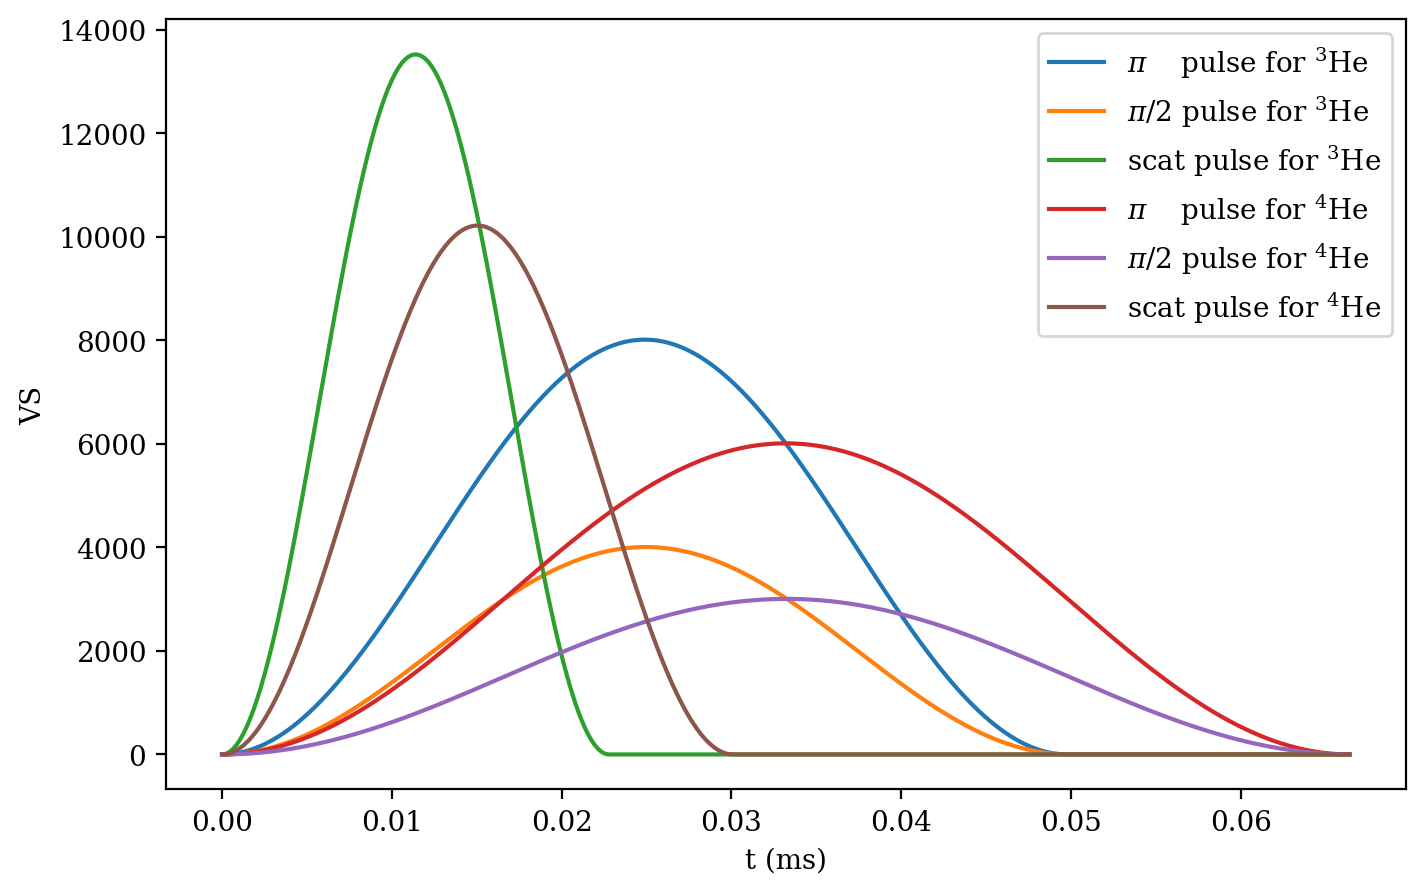

In [128]:
tbtest = np.arange(0,tLongestPulse,dt)
plt.figure()
plt.plot(tbtest, VS(tbtest, 0.5*t3pi1, t3pi1, V3pi1),label="$\pi$    pulse for ${}^3\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, 0.5*t3pi2, t3pi2, V3pi2),label="$\pi/2$ pulse for ${}^3\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, 0.5*t3sc,  t3sc,  V3sc),label="scat pulse for ${}^3\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, 0.5*t4pi1, t4pi1, V4pi1),label="$\pi$    pulse for ${}^4\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, 0.5*t4pi2, t4pi2, V4pi2),label="$\pi/2$ pulse for ${}^4\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, 0.5*t4sc,  t4sc,  V4sc),label="scat pulse for ${}^4\mathrm{He}$")
plt.legend()
plt.xlabel("t (ms)")
plt.ylabel("VS")
plt.show()

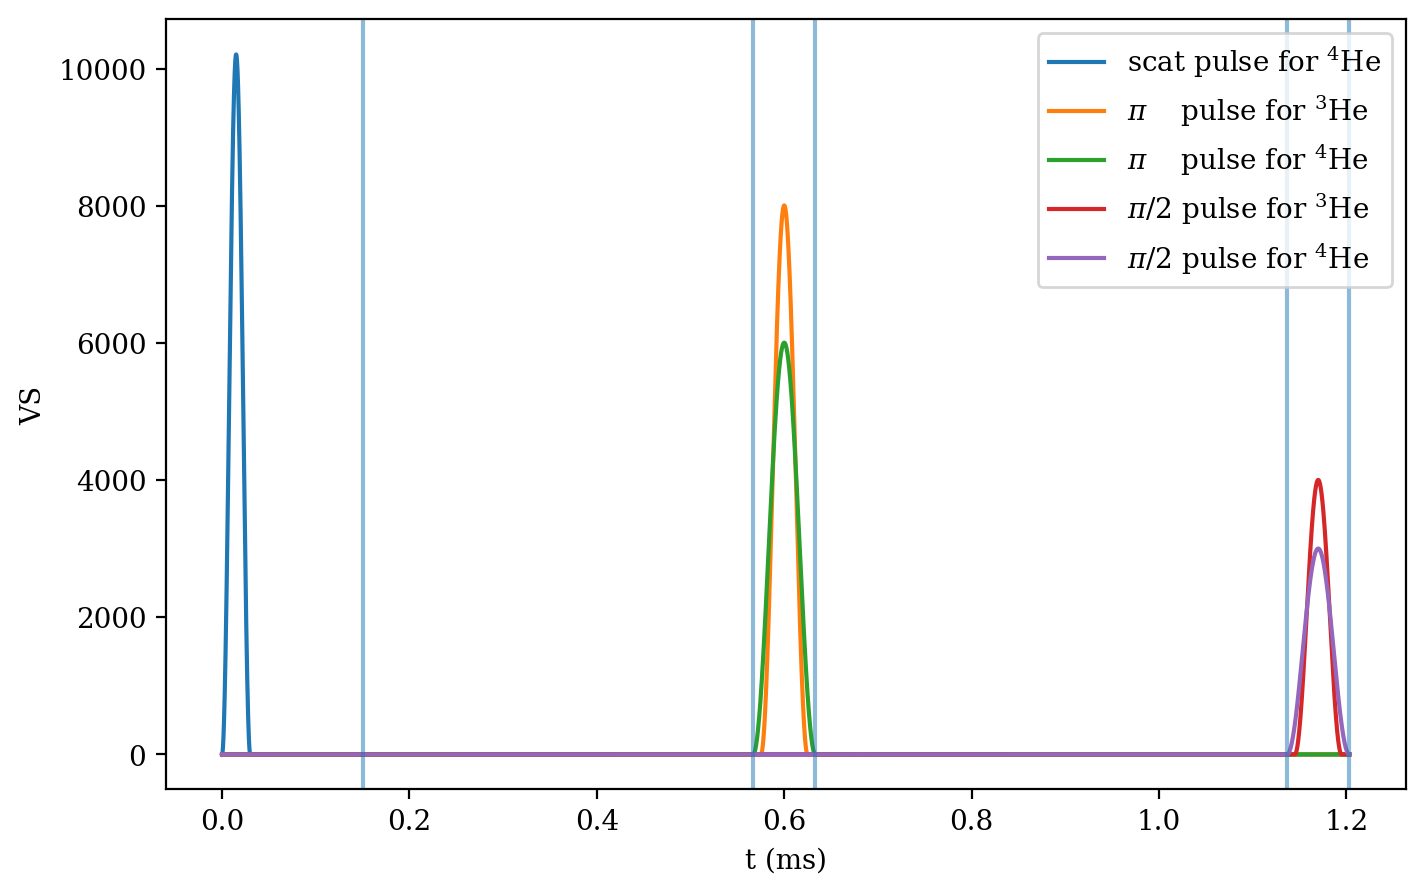

In [129]:
tbtest = np.arange(0, T_END,dt)
plt.figure()
plt.plot(tbtest, VS(tbtest, 0.5*t4sc,  t4sc,  V4sc),label="scat pulse for ${}^4\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, T_MR, t3pi1, V3pi1),label="$\pi$    pulse for ${}^3\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, T_MR, t4pi1, V4pi1),label="$\pi$    pulse for ${}^4\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, T_BS, t3pi2, V3pi2),label="$\pi/2$ pulse for ${}^3\mathrm{He}$")
plt.plot(tbtest, VS(tbtest, T_BS, t4pi2, V4pi2),label="$\pi/2$ pulse for ${}^4\mathrm{He}$")
plt.axvline(T_a34off,alpha=0.5); #plt.text(T_a34off + 0.01, V4sc,'T_a34off')
plt.axvline(T_MR_L,alpha=0.5)
plt.axvline(T_MR_R,alpha=0.5)
plt.axvline(T_BS_L,alpha=0.5)
plt.axvline(T_BS_R,alpha=0.5)
plt.legend()
plt.xlabel("t (ms)")
plt.ylabel("VS")
pulsetimings = plt.gcf()
plt.show()

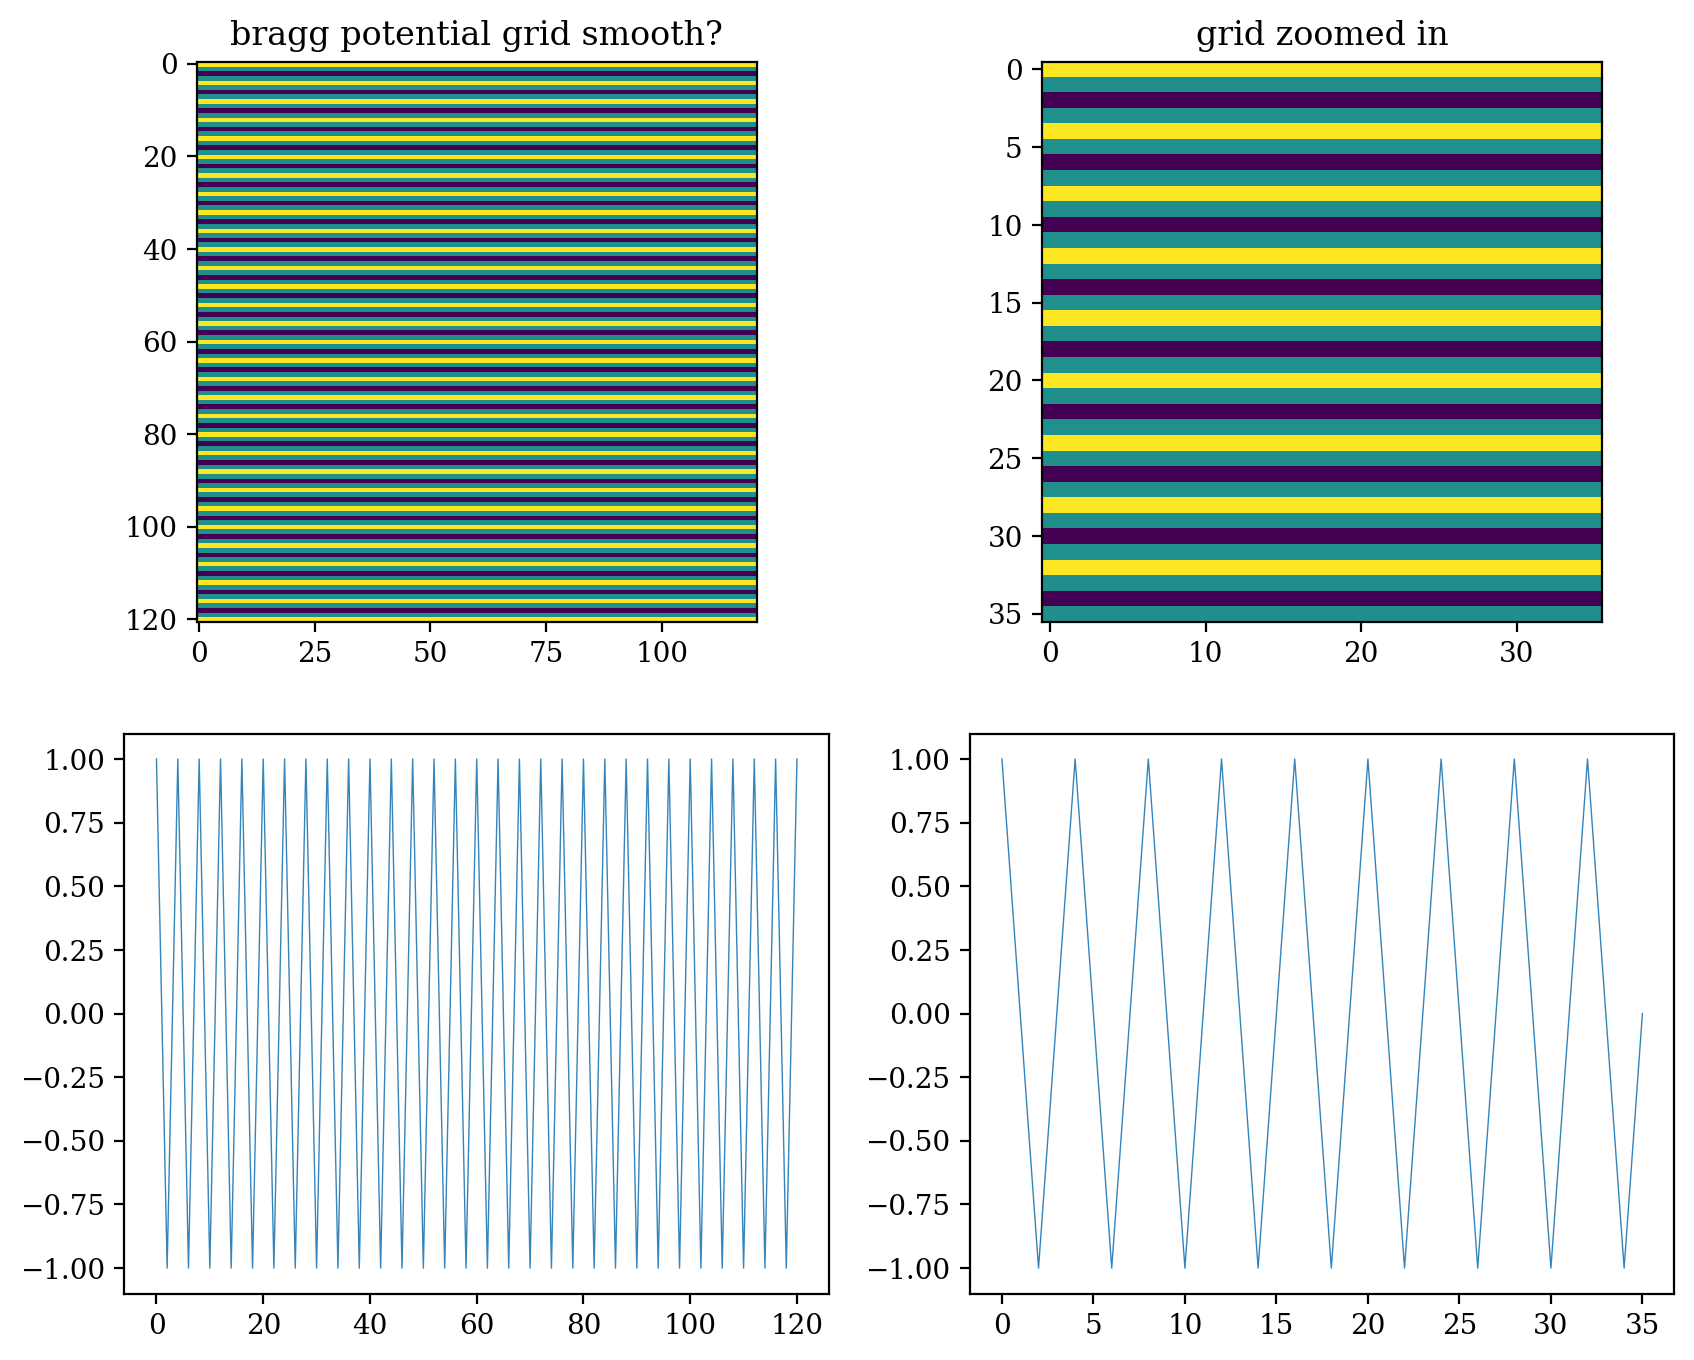

In [130]:
# vtest = np.cos(2*k*xlin)
ncrop = int(0.3*nx)
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
# plt.imshow(cosXGrid.T)
plt.imshow(cosZGrid.T)
plt.title("bragg potential grid smooth?")

plt.subplot(2,2,2)
# plt.imshow(cosXGrid[:ncrop,:ncrop].T)
plt.imshow(cosZGrid[:ncrop,:ncrop].T)
plt.title("grid zoomed in")

plt.subplot(2,2,3)
# plt.plot(cosXGrid[:,0],alpha=0.9,linewidth=0.5)
plt.plot(cosZGrid[0,:],alpha=0.9,linewidth=0.5)

plt.subplot(2,2,4)
# plt.plot(cosXGrid[:ncrop,0],alpha=0.9,linewidth=0.5)
plt.plot(cosZGrid[0,:ncrop],alpha=0.9,linewidth=0.5)

title="bragg_potential_grid"
# plt.savefig("output/"+title+".pdf", dpi=600)
# plt.savefig("output/"+title+".png", dpi=600)

plt.show()

In [131]:
gc.collect()
%reset -f in
%reset -f out

Flushing input history
Flushing output cache (12 entries)


### Initial wave function Defs (🔄)

In [132]:
sg = 8;
@njit(cache=True)
def psi0gaussianNN(x3, z3, x4, z4, sx3=sg, sz3=sg, sx4=sg, sz4=sg, px3=0.0, pz3=0.0, px4=0.0, pz4=0.0):
    return    np.exp(-0.5*x3**2/sx3**2)\
            * np.exp(-0.5*z3**2/sz3**2)\
            * np.exp(-0.5*x4**2/sx4**2)\
            * np.exp(-0.5*z4**2/sz4**2)\
            * np.exp(+(1j/hb)*(px3*x3 + pz3*z3 + px4*x4 + pz4*z4))

@njit(cache=True)
def check_norm(psi,dx=dx,dz=dz) -> dtyper:
    return np.trapz(np.trapz(np.trapz(np.trapz(np.abs(psi)**2))))*(dx*dx*dz*dz)


@njit(parallel=True, cache=True)
def psi0gaussian(sx3=sg, sz3=sg, sx4=sg, sz4=sg, px3=0, pz3=0, px4=0, pz4=0, xlin=xlin,zlin=zlin) -> np.ndarray:
    psi=np.zeros((nx,nz, nx,nz),dtype=dtypec)
    for iz3 in prange(nz):
        z3 = zlin[iz3]
        for (ix4, x4) in enumerate(xlin):
            for (iz4, z4) in enumerate(zlin):
                psi[:,iz3,ix4,iz4] = psi0gaussianNN(xlin, z3, x4, z4,sx3,sz3,sx4,sz4,px3,pz3,px4,pz4)
    normalisation = check_norm(psi)
    return (psi/sqrt(normalisation)).astype(dtypec)

# @njit(cache=True)
# @njit()
# @jit
@jit(forceobj=True, cache=True)
def only3(psi):
    return np.trapz(np.trapz(np.abs(psi)**2 ,dx=dz,axis=3),dx=dx,axis=2)

# @njit(cache=True)
# @njit()
# @jit
@jit(forceobj=True, cache=True)
def only4(psi):
    return np.trapz(np.trapz(np.abs(psi)**2 ,dx=dx,axis=0),dx=dz,axis=0)

In [133]:
# _ = psi0gaussian() # executes in 8.97s 

In [134]:
@njit(parallel=True, cache=True)
def psi0_just_opposite(dr=20,s3=sg,s4=sg,pt=0,a=0,xlin=xlin,zlin=zlin):
    dr3 = 0.5 * dr;
    dr4 = 0.5 * (m3/m4) * dr;
    dx3 = dr3 * cos(a)
    dz3 = dr3 * sin(a)
    dx4 = dr4 * cos(a)
    dz4 = dr4 * sin(a)
    ph = 0.5 * pt;
    px = +ph * cos(a)
    pz = +ph * sin(a)
    
    psi = np.zeros((nx,nz,nx,nz),dtype=dtypec)
    for iz3 in prange(nz):
        z3 = zlin[iz3]
        for (ix4, x4) in enumerate(xlin):
            for (iz4, z4) in enumerate(zlin):
                psi[:,iz3,ix4,iz4] = psi0gaussianNN(xlin-dx3,z3-dz3, x4+dx4,z4+dz4, s3,s3, s4,s4,+px,+pz,-px,-pz)
    normalisation = check_norm(psi)
    return (psi/sqrt(normalisation)).astype(dtypec)
    

In [135]:
su=5
# _ = psi0_just_opposite(dr=0,s3=su,s4=su,pt=-3*hb*k,a=0*pi) %7sec

In [136]:
@njit(cache=True)
def psi0PairNN(x3,z3,x4,z4,dr=20,s3=sg,s4=sg,pt=p,a=0):
    dr3 = 0.5 * dr;
    dr4 = 0.5 * (m3/m4) * dr;
    dx3 = dr3 * cos(a)
    dz3 = dr3 * sin(a)
    dx4 = dr4 * cos(a)
    dz4 = dr4 * sin(a)
    ph = 0.5 * pt;
    px3 = +ph * cos(a)
    pz3 = +ph * sin(a)
    px4 = -ph * cos(a)
    pz4 = -ph * sin(a)
    return (psi0gaussianNN(x3-dx3,z3-dz3, x4+dx4,z4+dz4, s3,s3, s4,s4,+px3,+pz3,+px4,+pz4) + 
            psi0gaussianNN(x3+dx3,z3+dz3, x4-dx4,z4-dz4, s3,s3, s4,s4,-px3,-pz3,-px4,-pz4)
           )

@njit(cache=True, parallel=True)
def psi0Pair(dr=20,s3=sg,s4=sg,pt=p,a=0,nx=nx,nz=nz):
    psi = np.zeros((nx,nz,nx,nz),dtype=dtypec)
    for iz3 in prange(nz):
        z3 = zlin[iz3]
        for (ix4, x4) in enumerate(xlin):
            for (iz4, z4) in enumerate(zlin):
                psi[:,iz3,ix4,iz4] = psi0PairNN(xlin, z3, x4, z4, dr,s3,s4,pt,a)
    normalisation = check_norm(psi)
    return (psi/sqrt(normalisation)).astype(dtypec)

In [137]:
# _ = psi0Pair() # 5.24s 

In [138]:
@njit(nogil=True,parallel=True,cache=True) # psi0Pair already parallelised
def psi0ring_loop_helper(dr,s3,s4,pt,an, 
#                         ):
                         progress_proxy=None):
    psi = np.zeros((nx,nz,nx,nz),dtype=dtypec)
    angles_list = np.linspace(0,pi,an+1)[:-1]
    for ia in range(an):
        a = angles_list[ia]
        psi += (1/an) * psi0Pair(dr=dr,s3=s3,s4=s4,pt=pt,a=a,nx=nx,nz=nz)
        if progress_proxy != None:
            progress_proxy.update(1)
    return psi.astype(dtypec)

# @njit(cache=True)
def psi0ring_with_logging(dr=20,s3=3,s4=3,pt=p,an=4):   
    angles_list = np.linspace(0,pi,an+1)[:-1]
    print("angles_list = "+ str(np.round(angles_list/pi,4)) + " * pi")
    with ProgressBar(total=an) as progress:
        psi = psi0ring_loop_helper(dr,s3,s4,pt,an,progress)
    normalisation = check_norm(psi)
    return (psi/sqrt(normalisation)).astype(dtypec)
    
@njit(parallel=True,cache=True)
def psi0ring(dr=20,s3=3,s4=3,pt=p,an=4):   
    psi = psi0ring_loop_helper(dr,s3,s4,pt,an)
    normalisation = check_norm(psi)
    return (psi/sqrt(normalisation)).astype(dtypec)

In [139]:
# _ = psi0ring_with_logging(dr=20,s3=3,s4=3,pt=p,an=1)
# _ = psi0ring(dr=20,s3=3,s4=3,pt=p,an=1) # 13s

In [140]:
gc.collect()
%reset -f in
%reset -f out

Flushing input history
Flushing output cache (0 entries)


In [141]:
@jit(forceobj=True, cache=True)
def only3phi(phi):
    return np.trapz(np.trapz(np.abs(phi)**2,dx=dpz,axis=3),dx=dpx,axis=2)
#     return np.trapz(np.trapz(np.abs(phi)**2,dx=dpx,axis=2),dx=dpz,axis=2)
@jit(forceobj=True, cache=True)
def only4phi(phi):
    return np.trapz(np.trapz(np.abs(phi)**2,dx=dpx,axis=0),dx=dpz,axis=0)

@njit(cache=True)
def check_norm_phi(phi):
#     return np.trapz(np.trapz(np.trapz(np.trapz(np.abs(phi)**2,dx=dpz,axis=3),dx=dpx,axis=2),dx=dpz,axis=1),dx=dpx,axis=0)
    return np.trapz(np.trapz(np.trapz(np.trapz(np.abs(phi)**2))))*(dpx*dpx*dpz*dpz)

In [142]:
@jit(forceobj=True, cache=True)
def phiAndSWNF(psi, nthreads=nthreads):
    phiUN = np.flip(np.flip(np.fft.fftshift(pyfftw.interfaces.numpy_fft.fftn(psi,threads=nthreads,norm='ortho')),axis=1),axis=3)
    superWeirdNormalisationFactorSq = check_norm_phi(phiUN)
    swnf = sqrt(superWeirdNormalisationFactorSq)
    phi = phiUN/swnf
    return phi, (swnf+0*1j)

@jit(forceobj=True, cache=True)
def toPhi(psi, swnf, nthreads=nthreads) -> np.ndarray:
    return np.flip(np.flip(np.fft.fftshift(pyfftw.interfaces.numpy_fft.fftn(psi,threads=nthreads,norm='ortho')),axis=1),axis=3)/swnf

@jit(forceobj=True, cache=True)
def toPsi(phi, swnf, nthreads=nthreads) -> np.ndarray:
    return pyfftw.interfaces.numpy_fft.ifftn(np.fft.ifftshift(np.flip(np.flip(phi*swnf,axis=3),axis=1)),threads=nthreads,norm='ortho')

In [143]:
su = 3
# psi = psi0gaussian(sx3=su, sz3=su, sx4=su, sz4=su, px3=-100, pz3=-50, px4=100, pz4=50)
# psi = psi0gaussian(sx3=su, sz3=su, sx4=su, sz4=su, px3=0, pz3=0, px4=0, pz4=0) # 5sec
t = 0

In [144]:
su/v3

0.045109246039921336

In [145]:
su/v4

0.06014566138656177

In [146]:
# @njit(cache=True, parallel=True)
@jit(forceobj=True, parallel=True)
def gx3x4_calc(psi,cut=5.0):
    ind = abs(zlin) < (cut+1e-15)*dz
    # print(ind)
    gx3x4 = np.trapz(np.abs(psi[:,:,:,ind])**2,zlin[ind],axis=3)
    gx3x4 = np.trapz(gx3x4[:,ind,:],zlin[ind],axis=1)
    return gx3x4

In [147]:
def plot_gx3x4(gx3x4,cut):
    xip = xlin > 0
    xim = xlin < 0
    gpp = np.trapz(np.trapz(gx3x4[:,xip],xlin[xip],axis=1)[xip],xlin[xip],axis=0)
    gpm = np.trapz(np.trapz(gx3x4[:,xim],xlin[xim],axis=1)[xip],xlin[xip],axis=0)
    gmp = np.trapz(np.trapz(gx3x4[:,xip],xlin[xip],axis=1)[xim],xlin[xim],axis=0)
    gmm = np.trapz(np.trapz(gx3x4[:,xim],xlin[xim],axis=1)[xim],xlin[xim],axis=0)
    E = (gpp+gmm-gpm-gmp)/((gpp+gmm+gpm+gmp))
    
    plt.imshow(np.flipud(gx3x4.T),extent=[-xmax,xmax,-xmax,xmax],cmap='Greens')
    plt.title("$g^{(2)}_{\pm\pm}$ of $z_\mathrm{cut} = "+str(cut)+"dz$ and $E="+str(round(E,4))+"$")
    plt.xlabel("$x_3$")
    plt.ylabel("$x_4$")
    plt.axhline(y=0,color='k',alpha=0.2,linewidth=0.7)
    plt.axvline(x=0,color='k',alpha=0.2,linewidth=0.7)
    plt.text(+xmax*0.6,+xmax*0.8,"$g^{(2)}_{++}="+str(round(gpp,4))+"$", color='white',ha='center',alpha=0.9)
    plt.text(-xmax*0.6,+xmax*0.8,"$g^{(2)}_{-+}="+str(round(gmp,4))+"$", color='white',ha='center',alpha=0.9)
    plt.text(+xmax*0.6,-xmax*0.8,"$g^{(2)}_{+-}="+str(round(gpm,4))+"$", color='white',ha='center',alpha=0.9)
    plt.text(-xmax*0.6,-xmax*0.8,"$g^{(2)}_{--}="+str(round(gmm,4))+"$", color='white',ha='center',alpha=0.9)
    

## Split-step func

### Function Defs (🔄)

In [148]:
# numba.set_num_threads(2)
# Each thread will multiply the memory usage!
# e.g. single thread 10GB -> 2 threads ~30GB

In [149]:
l.info(f"""numba.get_num_threads() = {numba.get_num_threads()}, 
{round(ram_py_GB(),2)} GB used of sys total {round(ram_sys_GB,2)} GB in system
multithread could use up to {round(ram_py_GB()*numba.get_num_threads(),2)} GB !!!""")

numba.get_num_threads() = 8, 
6.66 GB used of sys total 68.72 GB in system
multithread could use up to 53.32 GB !!!


In [150]:
# TODO WTF did this come from?
# a34 = 0.029 #µm
# a34 = 0.5 #µm
a34 = sqrt(2)*5*dx
strength34 = 1e5 # I don't know
l.info(f"{-(1j/hb) * strength34 * np.exp(-((0-0)**2 +(0-0)**2)/(4*a34**2)) *0.5*dt}")
l.info(f"a34 = {a34}")

-0.07873048664888407j
a34 = 3.5355339059327378


In [151]:
@njit(parallel=True,cache=True)
# @njit
def scattering_evolve_loop_helper2_inner_psi_step(psi_init, s34=strength34):
    psi = psi_init
    for iz3 in prange(nz):
        z3 = zlin[iz3]
        for (ix4, x4) in enumerate(xlin):
            for (iz4, z4) in enumerate(zlin):
                dis = ((xlin-x4)**2 +(z3-z4)**2)**0.5
                psi[:,iz3,ix4,iz4] *= np.exp(-(1j/hb) * # this one is unitary time evolution operator
                                        s34 *
                                             0.5*(1+np.cos(2*np.pi/a34*( dis ))) * 
                                            (-0.5*a34 < dis) * (dis < 0.5*a34)
                                        # np.exp(-((xlin-x4)**2 +(z3-z4)**2)/(4*a34**2))
                                               # inside the guassian contact potential
                                               *0.5*dt
                                            )
    return psi

@njit(parallel=True,cache=True)
# @njit
def scattering_evolve_loop_helper2_inner_phi_step(phi_init,dtsteps=1):
    phi = phi_init
    m1jhb05m3 = -(1j/hb) * (0.5/m3) * (dt*dtsteps)
    m1jhb05m4 = -(1j/hb) * (0.5/m4) * (dt*dtsteps)
    for iz3 in prange(nz):
        pz3 = pzlin[iz3]
#     for (iz3, pz3) in enumerate(pzlin):
        for (ix4, px4) in enumerate(pxlin):
            for (iz4, pz4) in enumerate(pzlin):
                phi[:,iz3,ix4,iz4] *= np.exp(m1jhb05m3 * (pxlin**2 + pz3**2) + \
                                             m1jhb05m4 * (  px4**2 + pz4**2))
    return phi

# @jit(nogil=True, parallel=True, forceobj=True)
@jit(nogil=True, forceobj=True)
# @njit(nogil=True, parallel=True)
def scattering_evolve_loop_helper2(t_init, psi_init, swnf, steps=20, progress_proxy=None, s34=strength34):
    t = t_init
    psi = psi_init
    for ia in prange(steps):
        psi = scattering_evolve_loop_helper2_inner_psi_step(psi,s34)
        phi = toPhi(psi, swnf, nthreads=7)
        phi = scattering_evolve_loop_helper2_inner_phi_step(phi)
        #del psi  # might cause memory issues
        psi = toPsi(phi, swnf, nthreads=7)
        psi = scattering_evolve_loop_helper2_inner_psi_step(psi,s34)
        t += dt 
        if progress_proxy != None:
            progress_proxy.update(1)                                   
    return (t, psi, phi)

In [152]:
gc.collect()
su = 1.7
se = 15
print("want to stop at t =", (0.5*se+5)/v3)
print("number of steps is ", (0.5*se+5)/v3/dt)

print_every = 4
frames_count = 50
total_steps = print_every * frames_count
print("Total steps =" ,total_steps)

#TODO: WTF WAS THIS!!!!!????!?!?!??!?!?!? 

want to stop at t = 0.18795519183300555
number of steps is  1879.5519183300553
Total steps = 200


In [153]:
total_steps*dt 

0.02

In [154]:
@njit(parallel=True, cache=True)
def psi0_just_opposite_double(dr=20,s3=sg,s4=sg,pt=0,a=0,xlin=xlin,zlin=zlin,fuck3=0):
    dr3 = 0.5 * dr;
    dr4 = 0.5 * (m3/m4) * dr;
    dx3 = dr3 * cos(a)
    dz3 = dr3 * sin(a)
    dx4 = dr4 * cos(a)
    dz4 = dr4 * sin(a)
    ph = 0.5 * pt;
    px = +ph * cos(a)
    pz = +ph * sin(a)
    
    dx3m = dr3 * cos(-a)
    dz3m = dr3 * sin(-a)
    dx4m = dr4 * cos(-a)
    dz4m = dr4 * sin(-a)
    pxm = +ph * cos(-a)
    pzm = +ph * sin(-a)
    
    psi = np.zeros((nx,nz,nx,nz),dtype=dtypec)
    for iz3 in prange(nz):
        z3 = zlin[iz3]
        for (ix4, x4) in enumerate(xlin):
            for (iz4, z4) in enumerate(zlin):
                psi[:,iz3,ix4,iz4] = \
                psi0gaussianNN(
                    xlin-dx3,z3-dz3, x4+dx4,z4+dz4, s3,s3, s4,s4,+fuck3*px,+fuck3*pz,-px,-pz) + \
                psi0gaussianNN(
                    xlin-dx3m,z3-dz3m, x4+dx4m,z4+dz4m, s3,s3, s4,s4,+fuck3*pxm,+fuck3*pzm,-pxm,-pzm)
    normalisation = check_norm(psi)
    return (psi/sqrt(normalisation)).astype(dtypec)

In [155]:
output_pre_selp = output_prefix + "scattering_evolve_loop_plot/"
os.makedirs(output_pre_selp, exist_ok=True)
def scattering_evolve_loop_plot(t,f,psi,phi, plt_show=True, plt_save=False):
    t_str = str(round(t,5))
    if plt_show:
        print("t = " +t_str+ " \t\t frame =", f, "\t\t memory used: " + 
              str(round(ram_py_MB(),3)) + "MB  ")

    fig = plt.figure(figsize=(8,7))
    plt.subplot(2,2,1)
    plt.imshow(np.flipud(only3(psi).T), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
#     plt.imshow(np.log(np.flipud(only3(psi).T)), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
    plt.xlabel("$x \ (\mu m)$")
    plt.ylabel("$z \ (\mu m)$")
    plt.title("$t="+t_str+" \ ms $")

    plt.subplot(2,2,2)
    plt.imshow(np.flipud(only4(psi).T), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
#     plt.imshow(np.log(np.flipud(only4(psi).T)), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
    plt.xlabel("$x \ (\mu m)$")
    plt.ylabel("$z \ (\mu m)$")

    plt.subplot(2,2,3)
    plt.imshow((only3phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
#     plt.imshow(np.log(only3phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
    # plt.colorbar()
    plt.xlabel("$p_x \ (\hbar k)$")
    plt.ylabel("$p_z \ (\hbar k)$")

    plt.subplot(2,2,4)
    plt.imshow((only4phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
#     plt.imshow(np.log(only4phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
    # plt.colorbar()
    plt.xlabel("$p_x \ (\hbar k)$")
    plt.xlabel("$p_x \ (\hbar k)$")

    if plt_save:
        title= "f="+str(f)+",t="+t_str 
        plt.savefig(output_pre_selp+title+".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(output_pre_selp+title+".png", dpi=600, bbox_inches='tight')
    
    if plt_show: plt.show() 
    else:        plt.close(fig) 

In [156]:
output_pre_selpa = output_prefix + "scattering_evolve_loop_plot_alt/"
os.makedirs(output_pre_selpa, exist_ok=True)
def scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=True, plt_save=False, logPlus=1,po=1):
    t_str = str(round(t,5))
    if plt_show:
        print("t = " +t_str+ " \t\t frame =", f, "\t\t memory used: " + 
              str(round(ram_py_MB(),3)) + "MB  ")

    fig = plt.figure(figsize=(8,7))
    plt.subplot(2,2,1)
#     plt.imshow(np.flipud(only3(psi).T), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
#     plt.imshow(np.emath.logn(power,np.flipud(only3(psi).T)), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
#     plt.imshow(np.power(np.flipud(only3(psi).T),power), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
    plt.imshow(np.power(np.log(logPlus+np.flipud(only3(psi).T)),po), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
    plt.xlabel("$x \ (\mu m)$")
    plt.ylabel("$z \ (\mu m)$")
    plt.title("$t="+t_str+" \ ms $")

    plt.subplot(2,2,2)
#     plt.imshow(np.flipud(only4(psi).T), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
#     plt.imshow(np.power(np.flipud(only4(psi).T),power), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
#     plt.imshow(np.emath.logn(power,np.flipud(only4(psi).T)), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
    plt.imshow(np.power(np.log(logPlus+np.flipud(only4(psi).T)),po), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
    plt.xlabel("$x \ (\mu m)$")
    plt.ylabel("$z \ (\mu m)$")

    plt.subplot(2,2,3)
#     plt.imshow((only3phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
#     plt.imshow(np.power(only3phi(phi).T,power), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
#     plt.imshow(np.emath.logn(power,only3phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
    # plt.colorbar()
    plt.imshow(np.power(np.log(logPlus+only3phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
    plt.xlabel("$p_x \ (\hbar k)$")
    plt.ylabel("$p_z \ (\hbar k)$")

    plt.subplot(2,2,4)
#     plt.imshow((only4phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
#     plt.imshow(np.power(only4phi(phi).T,power), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
#     plt.imshow(np.emath.logn(power,only4phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
    plt.imshow(np.power(np.log(logPlus+only4phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
    # plt.colorbar()
    plt.xlabel("$p_x \ (\hbar k)$")
    plt.xlabel("$p_x \ (\hbar k)$")

    if plt_save:
        title= "f="+str(f)+",t="+t_str+",logPlus="+str(logPlus) 
        plt.savefig(output_pre_selpa+title+".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(output_pre_selpa+title+".png", dpi=600, bbox_inches='tight')
    
    if plt_show: plt.show() 
    else:        plt.close(fig) 

In [157]:
evolve_s34 = 1e6
l.info(f"strength34 = {strength34}, \t evolve_s34 = {evolve_s34}")

strength34 = 100000.0, 	 evolve_s34 = 1000000.0


### One test run (🈶)

In [140]:
assert False, "just to catch run all"

AssertionError: just to catch run all

In [186]:
su = 3
# psi = psi0_just_opposite_double(dr=0,s3=su*(4/3),s4=su,pt=-4.0*hb*k,a=0.5*pi) # 16.37s
psi = psi0gaussian(sx3=su, sz3=su, sx4=su, sz4=su, px3=0, pz3=0, px4=0, pz4=0)
t = 0
f = 0
phi, swnf = phiAndSWNF(psi, nthreads=7)

t = 0 		 frame = 0 		 memory used: 7119.159MB  


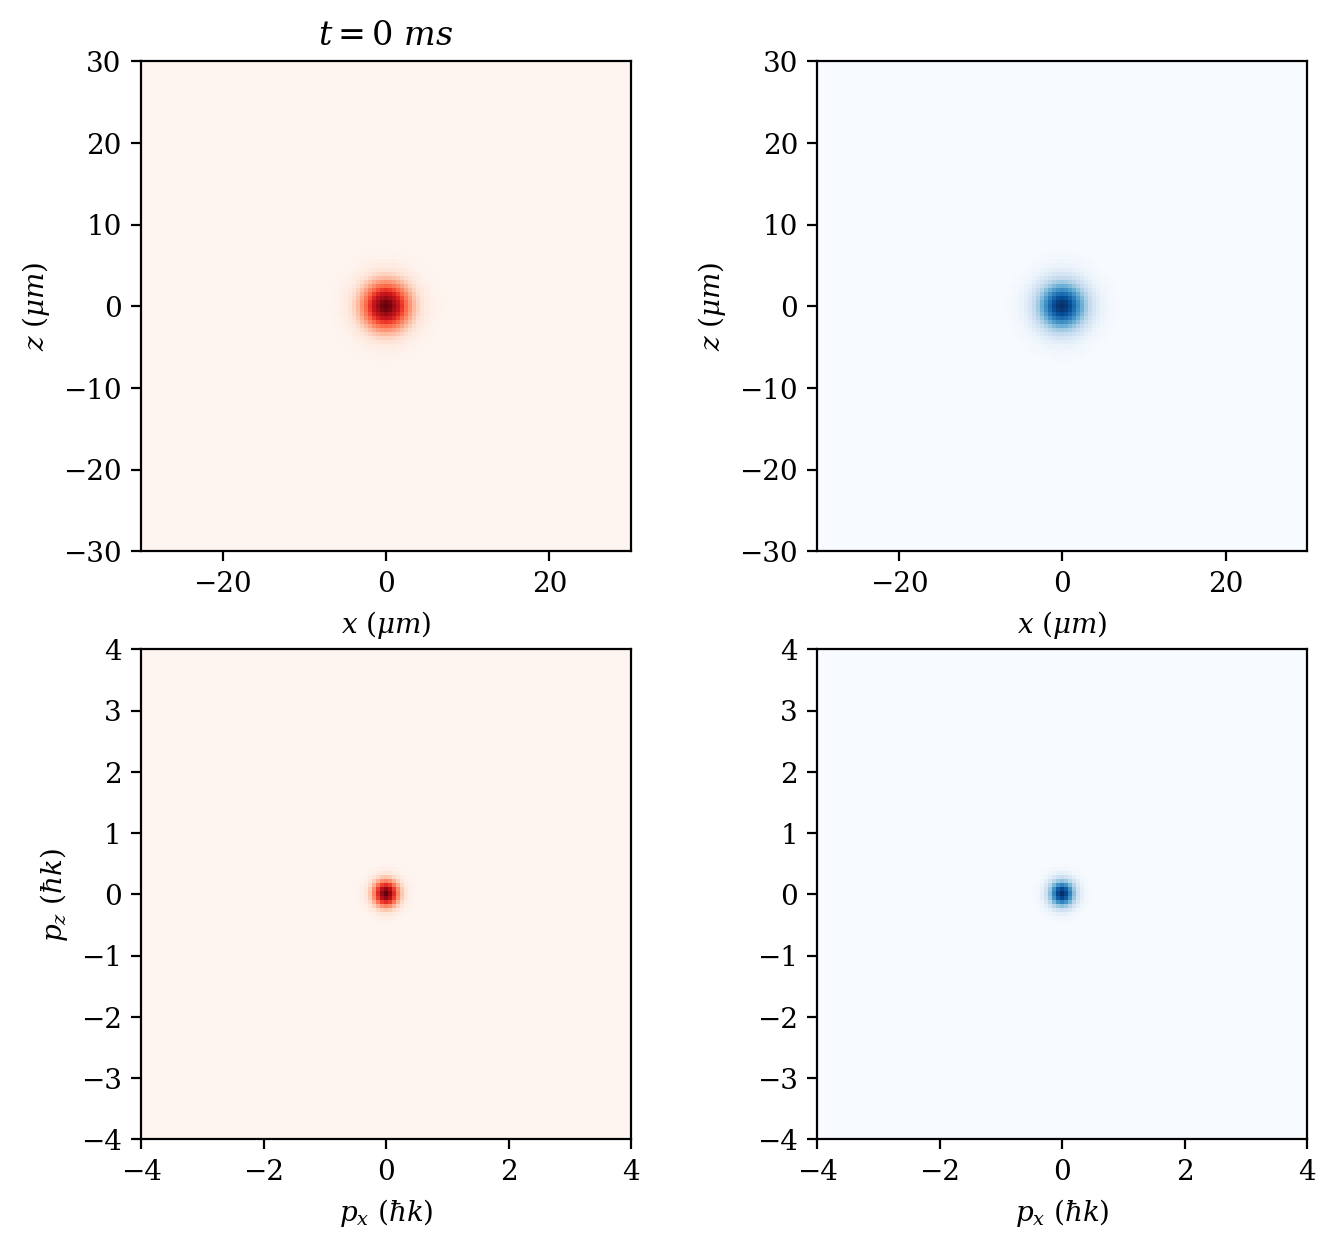

In [75]:
scattering_evolve_loop_plot(t,f,psi,phi, plt_show=True, plt_save=False)

t = 0 		 frame = 0 		 memory used: 7279.755MB  


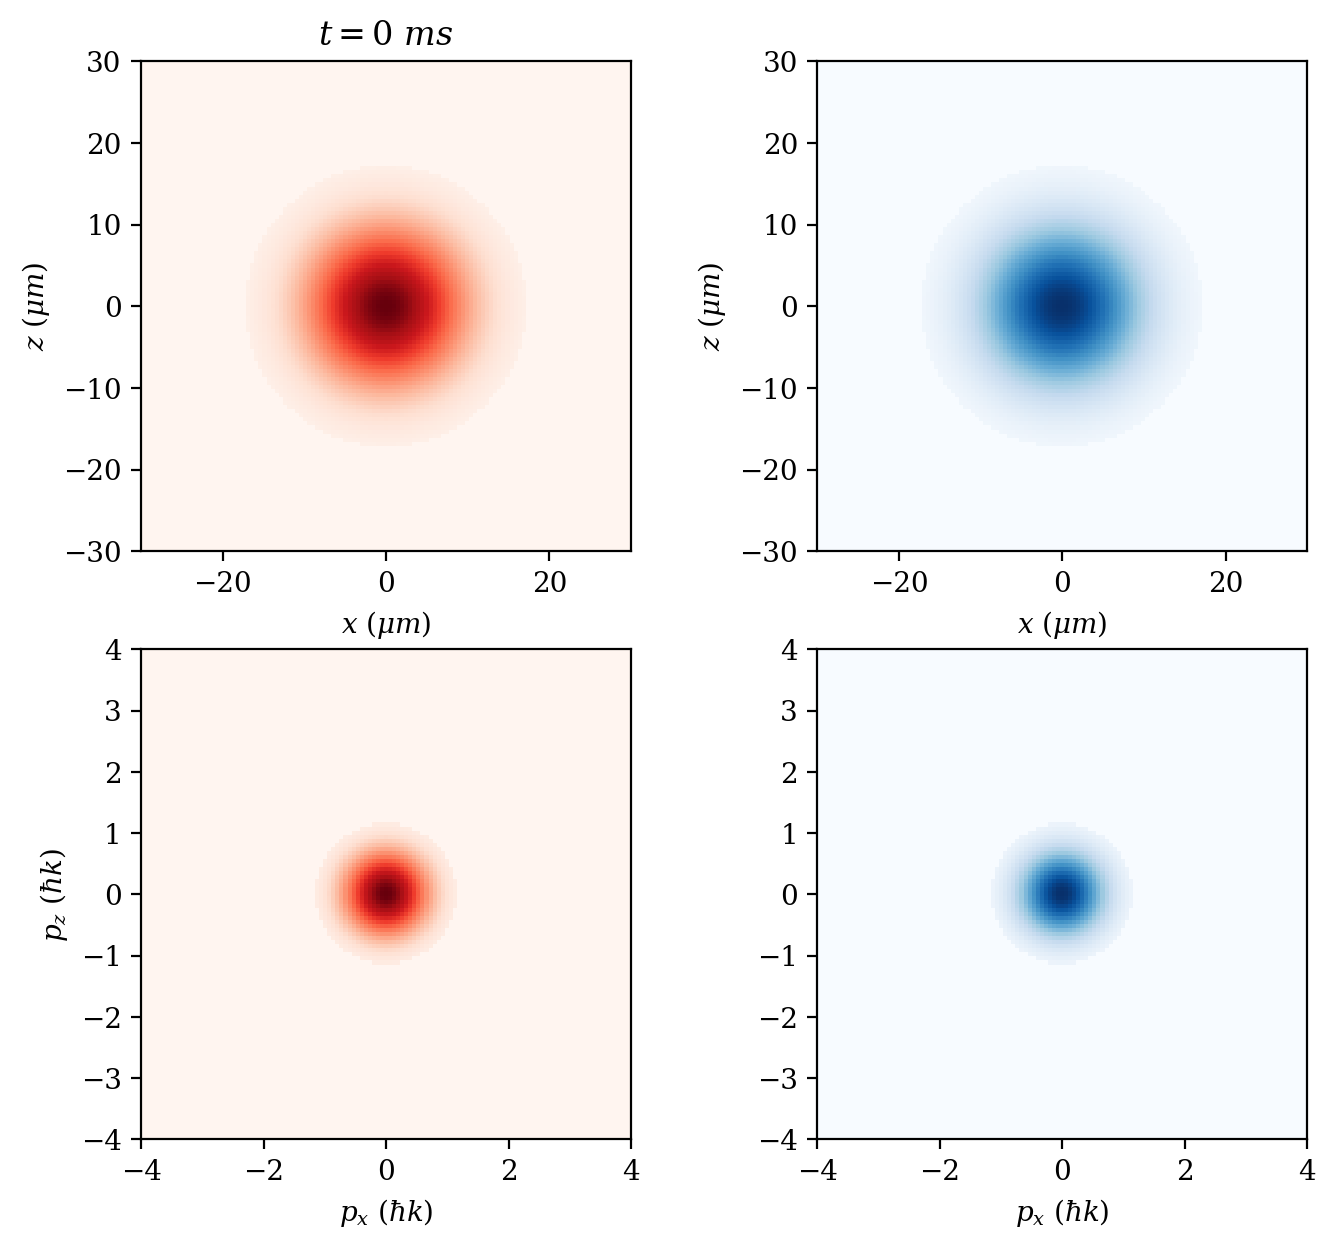

In [76]:
scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=True, plt_save=False, logPlus=1, po=0.1)

In [77]:
_ = None
gc.collect()
%reset -f in
%reset -f out
ram_py_log()

Flushing input history
Flushing output cache (4 entries)
7300.334MB of system memory used


# Simulation Sequence (🈶)

## Scattering from perfect init state (🈶)

In [73]:
assert False, "just to catch run all"

AssertionError: just to catch run all

In [74]:
evolve_loop_time_start = datetime.now()
_ = scattering_evolve_loop_helper2(t,psi,swnf,steps=1,progress_proxy=None,s34=strength34)
evolve_loop_time_end = datetime.now()
evolve_loop_time_delta = evolve_loop_time_end - evolve_loop_time_start
l.info(f"Time to run one evolve_loop_time_start is {evolve_loop_time_delta} (Run again to use cached compile)")
# need to run this once before looping to cache numba compiles

Time to run one evolve_loop_time_start is 0:00:54.467613 (Run again to use cached compile)


In [74]:
gc.collect()
%reset -f in
%reset -f out
ram_py_log()

Flushing input history
Flushing output cache (0 entries)
7339.59MB of system memory used


In [116]:
print_every = 10
frames_count = 500
total_steps = print_every * frames_count
evolve_loop_time_estimate = total_steps*evolve_loop_time_delta*1.1
l.info(f"""print_every = {print_every}, \tframes_count = {frames_count}, total_steps = {total_steps}
Target simulation end time = {frames_count*print_every*dt} ms
Estimated script runtime = {evolve_loop_time_estimate} which is {datetime.now()+evolve_loop_time_estimate}""")

print_every = 10, 	frames_count = 500, total_steps = 5000
Target simulation end time = 0.5 ms
Estimated script runtime = 20:28:36.230500 which is 2024-09-20 13:36:33.883193


In [ ]:
assert False, "just to catch run all"

In [ ]:
### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
evolve_many_loops_start = datetime.now()
frameAcc = 0 
with ProgressBar(total=total_steps) as progressbar:
    for f in range(frames_count):
        evolve_many_loops_inner_now = datetime.now()
        tE = evolve_many_loops_inner_now - evolve_many_loops_start
        if frameAcc > 0: 
            tR = (frames_count-frameAcc)* tE/frameAcc
            l.info(f"Now l={frameAcc}, t={round(t,6)}, tE={tE}, tR={tR}")
        scattering_evolve_loop_plot(t,f,psi,phi, plt_show=False, plt_save=True)
        scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
        gc.collect()
        (t,psi,phi) = scattering_evolve_loop_helper2(t,psi,swnf,
                                                     steps=print_every,progress_proxy=progressbar,s34=evolve_s34)
        frameAcc += 1
f += 1
scattering_evolve_loop_plot(t,f+1,psi,phi, plt_show=False, plt_save=True)
scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)

In [ ]:
l.info(t)
with pgzip.open(output_prefix+f"psi at t={t}"+output_ext,
                'wb', thread=8, blocksize=1*10**8) as file:
    pickle.dump(psi, file) 

## Scattering generated from Bragg pulse

### Function definitions (🔄)

In [158]:
@njit(parallel=True,cache=True,fastmath=True)
# @njit(parallel=True,cache=True)
def scattering_evolve_bragg_loop_helper2_inner_psi_step(
        psi_init, s34, tnow,
        t3mid, t3wid, v3pot,
        t4mid, t4wid, v4pot,
    ):
    psi = psi_init
    minus1jhb05dt = -(1j/hb)*0.5*dt
    VS3 = VS(tnow,t3mid,t3wid,v3pot)
    VS4 = VS(tnow,t4mid,t4wid,v4pot)
    for iz3 in prange(nz):
        z3 = zlin[iz3]
        for (ix4, x4) in enumerate(xlin):
            for (iz4, z4) in enumerate(zlin):
                # xlin is x3 here in the for loop
                # a34 contact potential
                if s34 != 0:
                    dis = ((xlin-x4)**2 +(z3-z4)**2)**0.5
                    psi[:,iz3,ix4,iz4] *= np.exp(minus1jhb05dt * # this one is unitary time evolution operator
                                                s34 * 0.5*(1+np.cos(2*np.pi/a34*( dis ))) * 
                                                    (-0.5*a34 < dis) * (dis < 0.5*a34)
                                            # np.exp(-((xlin-x4)**2 +(z3-z4)**2)/(4*a34**2)) # inside the guassian contact potential
                                                )
                # Bragg Potential (VxExpGrid in oneParticle)
                if VS3 != 0 or VS4 != 0:
                    psi[:,iz3,ix4,iz4] *= np.exp(minus1jhb05dt * (
                                             VS3*np.cos(2*kx*xlin + 2*kz*z3) + 
                                             VS4*np.cos(2*kx*x4   + 2*kz*z4)
                                            ))
                else: continue
                #
    return psi

# @njit(parallel=True,cache=True)
# def scattering_evolve_bragg_loop_helper2_inner_phi_step(phi_init):
#     phi = phi_init
#     for iz3 in prange(nz):
#         pz3 = pzlin[iz3]
# #     for (iz3, pz3) in enumerate(pzlin):
#         for (ix4, px4) in enumerate(pxlin):
#             for (iz4, pz4) in enumerate(pzlin):
#                 phi[:,iz3,ix4,iz4] *= np.exp(-(1j/hb) * (0.5/m3) * (dt) * (pxlin**2 + pz3**2) \
#                                              -(1j/hb) * (0.5/m4) * (dt) * (  px4**2 + pz4**2))
#     return phi

# @jit(nogil=True, parallel=True, forceobj=True)
# @jit(nogil=True, forceobj=True)
@jit(forceobj=True, cache=True)
# @jit(nogil=True)
# @njit(nogil=True, parallel=True)
def scattering_evolve_bragg_loop_helper2(
        tin, psii, swnf, 
        steps=20, progress_proxy=None, s34=strength34,
        t3mid=-2, t3wid=1, v3pot=0,
        t4mid=-2, t4wid=1, v4pot=0,
        numba_threads=7,
        fftw_threads=7
    ):
    t = tin
    psi = psii
    numba.set_num_threads(numba_threads)
    for ia in range(steps):
        # psi = scattering_evolve_bragg_loop_helper2_inner_psi_step(
        #     toPsi(
        #         scattering_evolve_loop_helper2_inner_phi_step(toPhi(
        #             scattering_evolve_bragg_loop_helper2_inner_psi_step(psi,s34,t,t3mid,t3wid,v3pot,t4mid,t4wid,v4pot)
        #             , swnf, nthreads=fftw_threads))
        #         , swnf, nthreads=fftw_threads)
        #     ,s34,t,t3mid,t3wid,v3pot,t4mid,t4wid,v4pot)

        psi = scattering_evolve_bragg_loop_helper2_inner_psi_step(psi,s34,t,t3mid,t3wid,v3pot,t4mid,t4wid,v4pot)
        phi = toPhi(psi, swnf, nthreads=fftw_threads)
        phi = scattering_evolve_loop_helper2_inner_phi_step(phi)
        #del psi  # might cause memory issues
        psi = toPsi(phi, swnf, nthreads=fftw_threads)
        psi = scattering_evolve_bragg_loop_helper2_inner_psi_step(psi,s34,t,t3mid,t3wid,v3pot,t4mid,t4wid,v4pot)
        t += dt 
        if progress_proxy != None:
            progress_proxy.update(1)                                   
    return (t, psi, phi)

@jit(forceobj=True, parallel=True,cache=True)
def evolve_free_part(tin, psii, swnf, dtsteps):
    t = tin
    psi = psii
    phi = toPhi(psi, swnf, nthreads=7)
    phi = scattering_evolve_loop_helper2_inner_phi_step(phi, dtsteps)
    psi = toPsi(phi, swnf, nthreads=7)
    t += dtsteps*dt
    return (t,psi,phi)

### One test run (🈶)

In [183]:
evolve_loop_time_start = datetime.now()
_ = scattering_evolve_bragg_loop_helper2(t,psi,swnf,steps=1,progress_proxy=None,s34=evolve_s34,
                                        t3mid=-3,t3wid=1,v3pot=0,
                                        t4mid=0.5*t4sc,t4wid=t4sc,v4pot=V4sc)
evolve_loop_time_end = datetime.now()
evolve_loop_time_delta = evolve_loop_time_end - evolve_loop_time_start
l.info(f"Time to run one evolve_loop_time_start is {evolve_loop_time_delta} (Run again to use cached compile)")
# need to run this once before looping to cache numba compiles

Time to run one evolve_loop_time_start is 0:00:13.029872 (Run again to use cached compile)
Time to run one evolve_loop_time_start is 0:00:13.029872 (Run again to use cached compile)


### Some Dev testing (usually don't run this)

### Actually running the fucking thing (🈶)

In [78]:
VS(1*dt ,0.5*t4sc, t4sc, V4sc)

1.112750726004246

In [79]:
VS(10*dt ,-3,1, V4sc)

0.0

In [80]:
gc.collect()
%reset -f in
%reset -f out
ram_py_log()
print_ram_usage(globals().items(),10)

Flushing input history
Flushing output cache (2 entries)
14220.526MB of system memory used
                           phi:  3.2 GiB
                      cosZGrid: 114.5 KiB
                         gx3x4: 114.5 KiB
                        tbtest: 94.1 KiB
             ImageSequenceClip:  1.6 KiB
                          HTML:  1.6 KiB
                      Parallel:  1.6 KiB
                          tqdm:  1.6 KiB
                        prange:  1.6 KiB
                   ProgressBar:  1.6 KiB


In [117]:
print_every = 10 # every us 
frames_count = 150 # until T_a34off
export_every = 30
total_steps = print_every * frames_count
t_end_target = frames_count*print_every*dt
evolve_loop_time_estimate = total_steps*evolve_loop_time_delta*1.1
l.info(f"""print_every = {print_every}, \tframes_count = {frames_count}, total_steps = {total_steps}
Target simulation end time = {t_end_target} ms
Estimated script runtime = {evolve_loop_time_estimate} which is {datetime.now()+evolve_loop_time_estimate}""")

print_every = 10, 	frames_count = 150, total_steps = 1500
Target simulation end time = 0.15 ms
Estimated script runtime = 6:08:34.869150 which is 2024-09-19 23:17:25.805280


In [ ]:
assert False, "just to catch run all"

#### Initial Scattering

In [ ]:
### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
evolve_many_loops_start = datetime.now()
frameAcc = 0 
with ProgressBar(total=total_steps) as progressbar:
    for f in range(frames_count):
        evolve_many_loops_inner_now = datetime.now()
        tP = evolve_many_loops_inner_now - evolve_many_loops_start
        if frameAcc > 0: 
            tR = (frames_count-frameAcc)* tP/frameAcc
            tE = datetime.now() + tR
            l.info(f"Now f={frameAcc}, t={round(t,6)}, tP={tP}, tR={tR}, tE = {tE}")
        scattering_evolve_loop_plot(t,f,psi,phi, plt_show=False, plt_save=True)
        scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
        gc.collect()
        (t,psi,phi) = scattering_evolve_bragg_loop_helper2(t,psi,swnf,
                          steps=print_every,progress_proxy=progressbar,s34=evolve_s34,
                          t3mid=-3, t3wid=1, v3pot=0, 
                          t4mid=0.5*t4sc, t4wid=t4sc, v4pot=V4sc                        
                          )
        frameAcc += 1
        if frameAcc % export_every == 0:
            with pgzip.open(output_prefix+f"psi at t={round(t,6)}"+output_ext,
                'wb', thread=8, blocksize=1*10**8) as file:
                pickle.dump(psi, file) 
                
f += 1
scattering_evolve_loop_plot(t,f+1,psi,phi, plt_show=False, plt_save=True)
scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)

In [ ]:
l.info(t)
with pgzip.open(output_prefix+f"psi at t={round(t,6)}"+output_ext,
                'wb', thread=8, blocksize=1*10**8) as file:
    pickle.dump(psi, file) 

In [77]:
t=0.15
with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/20240512-232723-TFF/psi at t={round(t,5)}.pgz.pkl'
                , 'rb', thread=8) as file:
    psi = pickle.load(file)
phi, swnf = phiAndSWNF(psi, nthreads=7)
gc.collect()

944

#### Free Propagator to Mirror

In [81]:
round(T_MR_L - t_end_target,5)

NameError: name 't_end_target' is not defined

In [82]:
round((T_MR_L - t_end_target)/dt)

NameError: name 't_end_target' is not defined

In [89]:
N_FREE_STEPS_1

4168

In [90]:
N_FREE_STEPS_1_actual = round((T_MR_L - t_end_target)/dt - 11)
t_end_target_free_1 = t_end_target + dt*N_FREE_STEPS_1_actual
l.info(f"N_FREE_STEPS_1_actual = {N_FREE_STEPS_1_actual}, t_end_target_free_1 = {t_end_target_free_1}")

N_FREE_STEPS_1_actual = 4157, t_end_target_free_1 = 0.5657


In [91]:
t_end_target_free_1

0.5657

In [92]:
T_MR_L

0.5668

In [93]:
#### ONE STEP COMPUTE !!!!
(t,psi,phi) = evolve_free_part(t,psi,swnf,N_FREE_STEPS_1_actual)

In [94]:
l.info(t)
with pgzip.open(output_prefix+f"psi at t={round(t,6)}"+output_ext,
                'wb', thread=8, blocksize=1*10**8) as file:
    pickle.dump(psi, file) 

0.5657


In [95]:
scattering_evolve_loop_plot(t,f,psi,phi, plt_show=False, plt_save=True)
scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)

In [96]:
round(t_end_target_free_1 + tLongestMRPulse,6)

0.6321

In [97]:
T_MR_R

0.6332

In [98]:
round((t_end_target_free_1 + tLongestMRPulse)/dt)

6321

In [99]:
# N_MR_STEPS
round((t_end_target_free_1 + tLongestMRPulse)/dt + 11)

6332

## Numerical Mirror Pulse (🈶)

In [100]:
ceil(NLongestBSPulse/print_every)

67

In [101]:
NLongestBSPulse/print_every

66.5

In [102]:
T_MR_R

0.6332

In [103]:
ceil((T_MR_R + 11*dt - t_end_target_free_1)/dt/print_every)

69

In [110]:
### THIS CELL IS COPIED CODE FROM INITIAL SCATTERING!!!!! 
# print_every = 10 # every us 
# frames_count = ceil(NLongestBSPulse/print_every) # until T_a34off
frames_count = ceil((T_MR_R + 12*dt - t_end_target_free_1)/dt/print_every)
export_every = 20
total_steps = print_every * frames_count
t_end_target = frames_count*print_every*dt
evolve_loop_time_estimate = total_steps*evolve_loop_time_delta*1.1
l.info(f"""print_every = {print_every}, 
frames_count = {frames_count}, 
export_every = {export_every}, \t {frames_count//export_every}
total_steps = {total_steps}
Target simulation end time = {t_end_target} ms, {t_end_target+t}
Estimated script runtime = {evolve_loop_time_estimate} which is {datetime.now()+evolve_loop_time_estimate}""")

print_every = 10, 
frames_count = 69, 
export_every = 20, 	 3
total_steps = 690
Target simulation end time = 0.069 ms, 0.6347
Estimated script runtime = 2:00:20.187117 which is 2024-05-22 01:25:34.117250


In [111]:
### THIS CELL IS COPIED CODE FROM INITIAL SCATTERING!!!!! 
### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
evolve_many_loops_start = datetime.now()
frameAcc = 0 
with ProgressBar(total=total_steps) as progressbar:
    for f in range(frames_count):
        evolve_many_loops_inner_now = datetime.now()
        tP = evolve_many_loops_inner_now - evolve_many_loops_start
        if frameAcc > 0: 
            tR = (frames_count-frameAcc)* tP/frameAcc
            tE = datetime.now() + tR
            l.info(f"Now f={frameAcc}, t={round(t,6)}, tP={tP}, tR={tR}, tE = {tE}")
        scattering_evolve_loop_plot(t,f,psi,phi, plt_show=False, plt_save=True)
        scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
        gc.collect()
        (t,psi,phi) = scattering_evolve_bragg_loop_helper2(t,psi,swnf,
                          steps=print_every,progress_proxy=progressbar,s34=evolve_s34,
                          t3mid=T_MR, t3wid=t3pi1, v3pot=V3pi1, #### THESE CHANGED, EVERYTHING ELSE COPIED
                          t4mid=T_MR, t4wid=t4pi1, v4pot=V4pi1  ####                  
                          )
        frameAcc += 1
        if frameAcc % export_every == 0:
            with pgzip.open(output_prefix+f"psi at t={round(t,6)}"+output_ext,
                'wb', thread=8, blocksize=1*10**8) as file:
                pickle.dump(psi, file) 
                
f += 1
scattering_evolve_loop_plot(t,f+1,psi,phi, plt_show=False, plt_save=True)
scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
l.info(f"t={t}")
with pgzip.open(output_prefix+f"psi at t={round(t,6)}"+output_ext,
                'wb', thread=8, blocksize=1*10**8) as file:
    pickle.dump(psi, file) 
gc.collect()

  0%|                                                                                                         …

finding looplift candidates
/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_99407/1460866268.py:48: NumbaWarning: Cannot cache compiled function "scattering_evolve_bragg_loop_helper2" as it uses lifted code
  @jit(forceobj=True, cache=True)

/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_99407/1460866268.py:48: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "scattering_evolve_bragg_loop_helper2" failed type inference due to: Invalid use of type(CPUDispatcher(<function toPhi at 0x1332c6b60>)) with parameters (array(complex128, 4d, C), complex128, nthreads=Literal[int](7))

During: resolving callee type: type(CPUDispatcher(<function toPhi at 0x1332c6b60>))
During: typing of call at /var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_99407/1460866268.py (61)


File "../../../../../../../../var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_99407/1460866268.py", line 61:
<source missing, REPL/exec 

3955

## Beam Splitter Pulse

### BSP configurations (🔄)

In [159]:
# th3, th3p, th4, th4p sets 
thetaCombo1 = ((0,1),           (V3pi32,t3pi32), (V4pi4, t4pi4),  (V4pi34,t4pi34))
thetaCombo2 = ((V3pi34,t3pi34), (V3pi4, t3pi4),  (V4pi32,t4pi32), (0,1)          )
thetaCombo3 = ((V3pi54,t3pi54), (V3pi34,t3pi34), (V4pi1, t4pi1),  (V4pi32,t4pi32))
thetaCombo4 = ((V3pi32,t3pi32), (V3pi1, t3pi1),  (V4pi34,t4pi34), (V4pi54,t4pi54))

thetaCombo5 = ((V3pi4,t3pi4),   (V3pi74,t3pi74), (0,1),           (V4pi2,t4pi2)  )
thetaCombo6 = ((V3pi2,t3pi2),   (0, 1),          (V4pi74,t4pi74), (V4pi4,t4pi4)  )
# thetaCombo7 = ((V3pi21,t3pi21), (V3pi2,t3pi2),   (V4pi54,t4pi54), (V4pi74,t4pi74))
# thetaCombo8 = ((V3pi74,t3pi74), (V3pi54,t3pi54), (V4pi2,t4pi2),   (V4pi21,t4pi21))
        #     this one is incorrect! 
thetaCombo7 = ((V3pi1,t3pi1),   (V3pi2,t3pi2),   (V4pi54,t4pi54), (V4pi74,t4pi74))
thetaCombo8 = ((V3pi74,t3pi74), (V3pi54,t3pi54), (V4pi2,t4pi2),   (V4pi1,t4pi1)  )

In [160]:
def comboSettingsGen(combo):
    return [(combo[0],combo[2]), (combo[0],combo[3]), 
            (combo[1],combo[2]), (combo[1],combo[3])]

In [161]:
comboSett1 = comboSettingsGen(thetaCombo1)
comboSett2 = comboSettingsGen(thetaCombo2)
comboSett3 = comboSettingsGen(thetaCombo3)
comboSett4 = comboSettingsGen(thetaCombo4)
comboSett5 = comboSettingsGen(thetaCombo5)
comboSett6 = comboSettingsGen(thetaCombo6)
comboSett7 = comboSettingsGen(thetaCombo7)
comboSett8 = comboSettingsGen(thetaCombo8)

In [162]:
def comboSymSwap(combo):
    return (combo[2], combo[3], combo[0], combo[1])

In [163]:
# comboSett1s = comboSettingsGen(comboSymSwap(thetaCombo1))
# comboSett2s = comboSettingsGen(comboSymSwap(thetaCombo2))
# comboSett3s = comboSettingsGen(comboSymSwap(thetaCombo3))
# comboSett4s = comboSettingsGen(comboSymSwap(thetaCombo4))
# comboSett5s = comboSettingsGen(comboSymSwap(thetaCombo5))
# comboSett6s = comboSettingsGen(comboSymSwap(thetaCombo6))
# comboSett7s = comboSettingsGen(comboSymSwap(thetaCombo7))
# comboSett8s = comboSettingsGen(comboSymSwap(thetaCombo8))
thetaCombo1s = ( (V3pi4, t3pi4),  (V3pi34,t3pi34), (0,1),           (V4pi32,t4pi32) )
thetaCombo2s = ( (V3pi32,t3pi32), (0,1)          , (V4pi34,t4pi34), (V4pi4, t4pi4)  )
thetaCombo3s = ( (V3pi1, t3pi1),  (V3pi32,t3pi32), (V4pi54,t4pi54), (V4pi34,t4pi34) )
thetaCombo4s = ( (V3pi34,t3pi34), (V3pi54,t3pi54), (V4pi32,t4pi32), (V4pi1, t4pi1)  )
thetaCombo5s = ( (0,1),           (V3pi2,t3pi2)  , (V4pi4,t4pi4),   (V4pi74,t4pi74) )
thetaCombo6s = ( (V3pi74,t3pi74), (V3pi4,t3pi4)  , (V4pi2,t4pi2),   (0, 1)          )
thetaCombo7s = ( (V3pi54,t3pi54), (V3pi74,t3pi74), (V4pi1,t4pi1),   (V4pi2,t4pi2)   )
thetaCombo8s = ( (V3pi2,t3pi2),   (V3pi1,t3pi1)  , (V4pi74,t4pi74), (V4pi54,t4pi54) )
comboSett1s = comboSettingsGen(thetaCombo1s)
comboSett2s = comboSettingsGen(thetaCombo2s)
comboSett3s = comboSettingsGen(thetaCombo3s)
comboSett4s = comboSettingsGen(thetaCombo4s)
comboSett5s = comboSettingsGen(thetaCombo5s)
comboSett6s = comboSettingsGen(thetaCombo6s)
comboSett7s = comboSettingsGen(thetaCombo7s)
comboSett8s = comboSettingsGen(thetaCombo8s)

In [164]:
comboSettSet = [comboSett1, comboSett2, comboSett3, comboSett4, comboSett5, comboSett6, comboSett7, comboSett8, 
                comboSett1s, comboSett2s, comboSett3s, comboSett4s, comboSett5s, comboSett6s, comboSett7s, comboSett8s]

In [165]:
T_BS_L

1.13665

In [166]:
gridX3, gridX4 = np.meshgrid(xlin,xlin)
@jit(forceobj=True, cache=True)
def plot_bs_l_free_time(psiH, tt, midCutZ=[1,5], pltShow=True, pltSave=True):
    # midCutZ = 5
    plt.figure(figsize=(7*len(midCutZ),11))
    tempReturn = []
    tempReturn2 = []
    for mi, mc in enumerate(midCutZ):
        plt.subplot(2,len(midCutZ),mi+1)
        ind = abs(zlin-0) < mc
        # l.info(f"np.sum(ind) = {np.sum(ind)}")
        midCut = np.trapz(np.abs(psiH[:,:,:,ind])**2,zlin[ind],axis=3)
        midCut = np.trapz(midCut[:,ind,:],zlin[ind],axis=1)
        tempReturn2.append(midCut)
        # plt.imshow(np.log(np.flipud(midCut.T)),cmap="Greens",extent=[-xmax,+xmax,-zmax,+zmax])
        plt.imshow(np.flipud(midCut.T)**0.5,cmap="Greens",extent=[-xmax,+xmax,-zmax,+zmax])
        plt.title(f"$t$={tt}, $dz$={mc}, ($s$={np.sum(ind)})")
        # plt.colorbar()
        plt.xlabel("$x3$")
        plt.ylabel("$x4$")
        plt.axhline(y=0,color='k',alpha=0.2,linewidth=0.7)
        plt.axvline(x=0,color='k',alpha=0.2,linewidth=0.7)

        plt.subplot(2,len(midCutZ),mi+len(midCutZ)+1)
        tempDiagIntensity = np.zeros(nx)
        for (ind, x0filt) in enumerate(xlin):
            # gridFilter = np.exp(-((gridX3-x0filt)**2 + (gridX4-(-4/3)*x0filt)**2)/mc )
            gridFilter = np.exp(-((gridX3-(-3/4)*x0filt)**2 + (gridX4-x0filt)**2)/mc )
            tempDiagIntensity[ind] = np.sum(midCut*gridFilter)
        plt.axvline(x=+v3scat*tt,alpha=0.2,color='g')
        plt.axvline(x=-v3scat*tt,alpha=0.2,color='g')
        plt.axvline(x=+v3scat*(tt-t4sc),alpha=0.2,color='g')
        plt.axvline(x=-v3scat*(tt-t4sc),alpha=0.2,color='g')
        plt.axvline(x=+v3scat*(tt-tLongestPulse),alpha=0.2,color='g')
        plt.axvline(x=-v3scat*(tt-tLongestPulse),alpha=0.2,color='g')
        plt.plot(xlin,tempDiagIntensity,)

        tempReturn.append(tempDiagIntensity)
    if pltSave:
        title = f"BS_L free time at t={round(tt,5)}, dz={midCutZ}"
        plt.savefig(output_prefix+title+".png",dpi=600)
        plt.savefig(output_prefix+title+".pdf",dpi=600)
    if pltShow:
        plt.show()
    plt.close()
    return (tempReturn,tempReturn2)

### Loading previous psi (🈶)

In [ ]:
assert False, "just to catch run all"

In [74]:
t=0.6347
# data_folder = "20240521-231755-TFF"
data_folder = "20240711-234819-TFF"
with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl'
                , 'rb', thread=8) as file:
    psi = pickle.load(file)
phi, swnf = phiAndSWNF(psi, nthreads=7)
gc.collect()

0

In [111]:
t=0.6347
T_FREE_TO_BS = T_BS_L - 5*dt - t
# T_FREE_TO_BS = 1.0 - t
N_FREE_TO_BS = ceil(T_FREE_TO_BS/dt)
l.info(f"""T_FREE_TO_BS = {T_FREE_TO_BS}
t+T_FREE_TO_BS = {t+T_FREE_TO_BS}
N_FREE_TO_BS = {N_FREE_TO_BS}""")

T_FREE_TO_BS = 0.50145
t+T_FREE_TO_BS = 1.13615
N_FREE_TO_BS = 5015


##### One Test Run

In [92]:
(t2,psi2,phi2) = evolve_free_part(t,psi,swnf,N_FREE_TO_BS)

t = 1.1362 		 frame = -1 		 memory used: 14139.965MB  


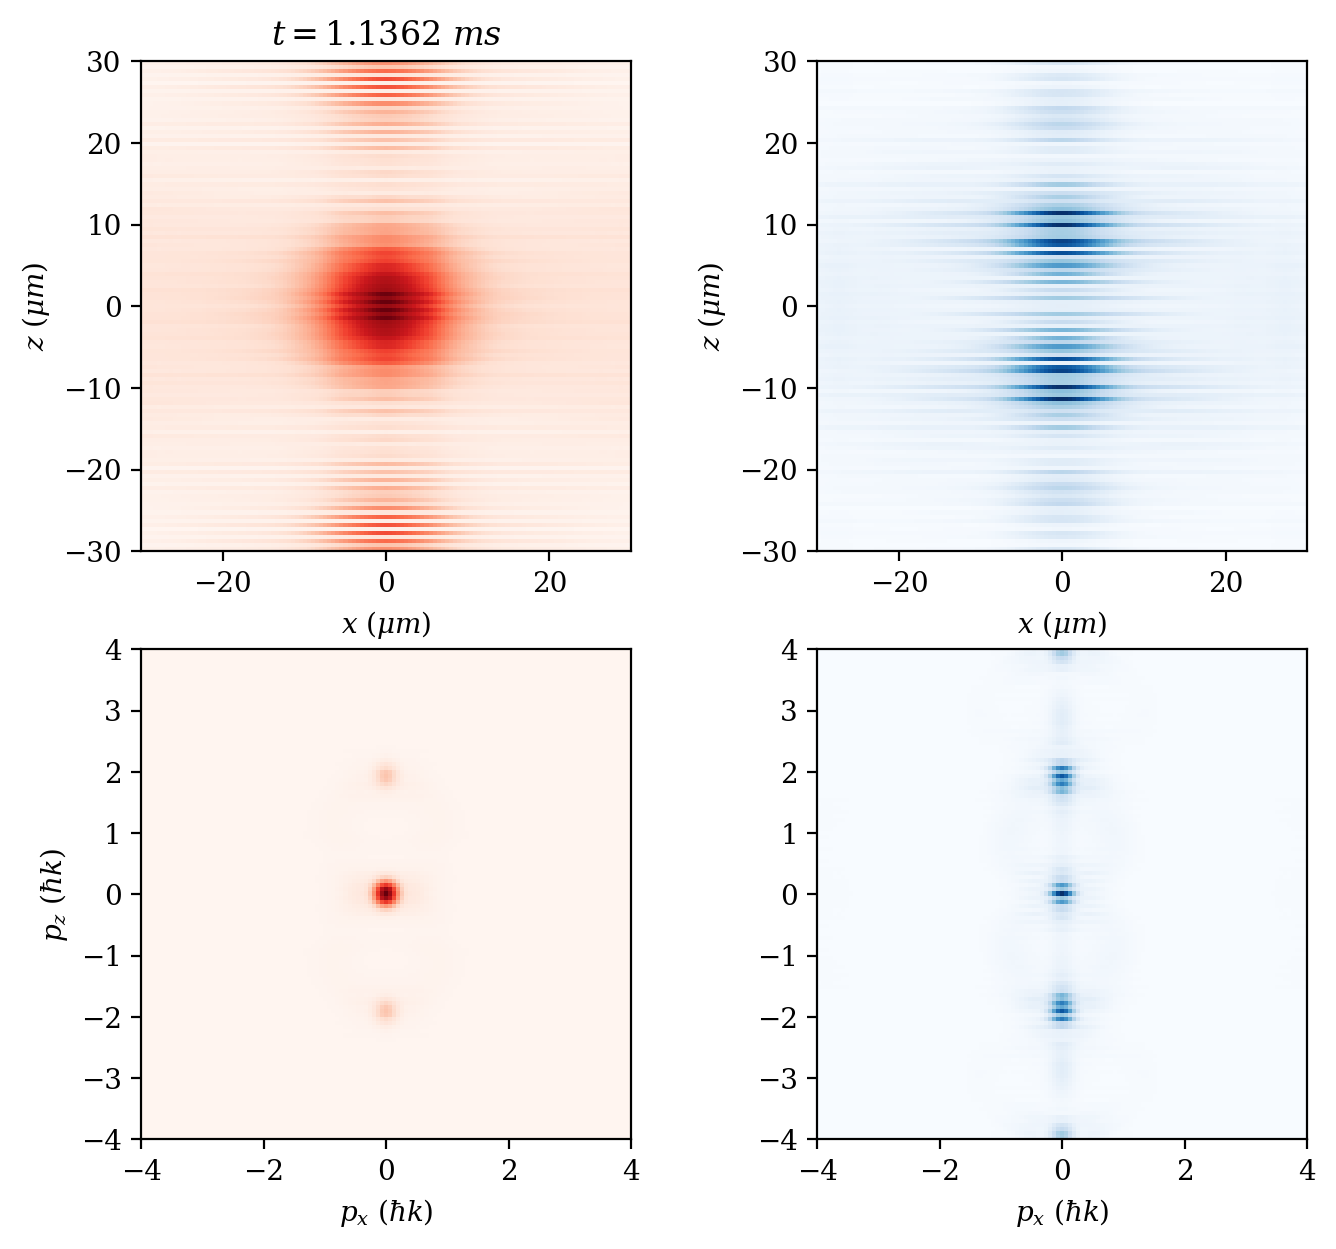

In [74]:
scattering_evolve_loop_plot(t2,-1,psi2,phi2, plt_show=True, plt_save=False)

t = 1.1362 		 frame = -1 		 memory used: 15669.625MB  


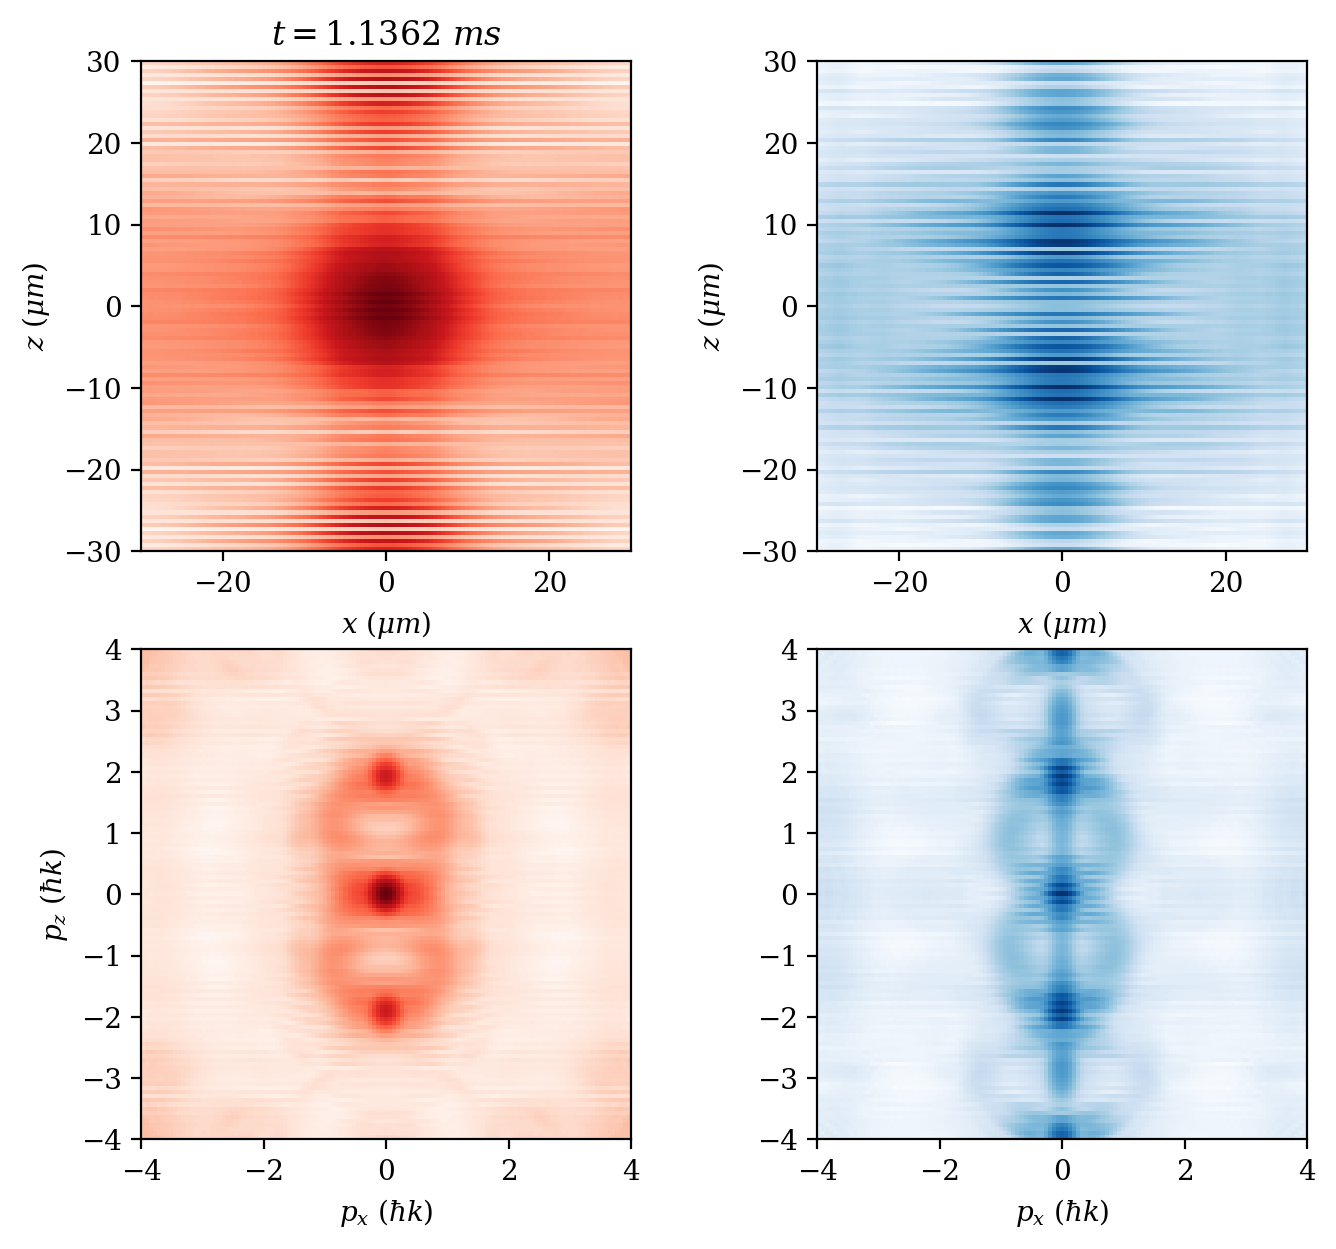

In [165]:
scattering_evolve_loop_plot_alt(t2,-1,psi2,phi2, plt_show=True, plt_save=False, logPlus=1, po=0.1)

In [85]:
gc.collect()
%reset -f in
%reset -f out
ram_py_log()

Flushing input history
Flushing output cache (2 entries)
588.497MB of system memory used


finding looplift candidates


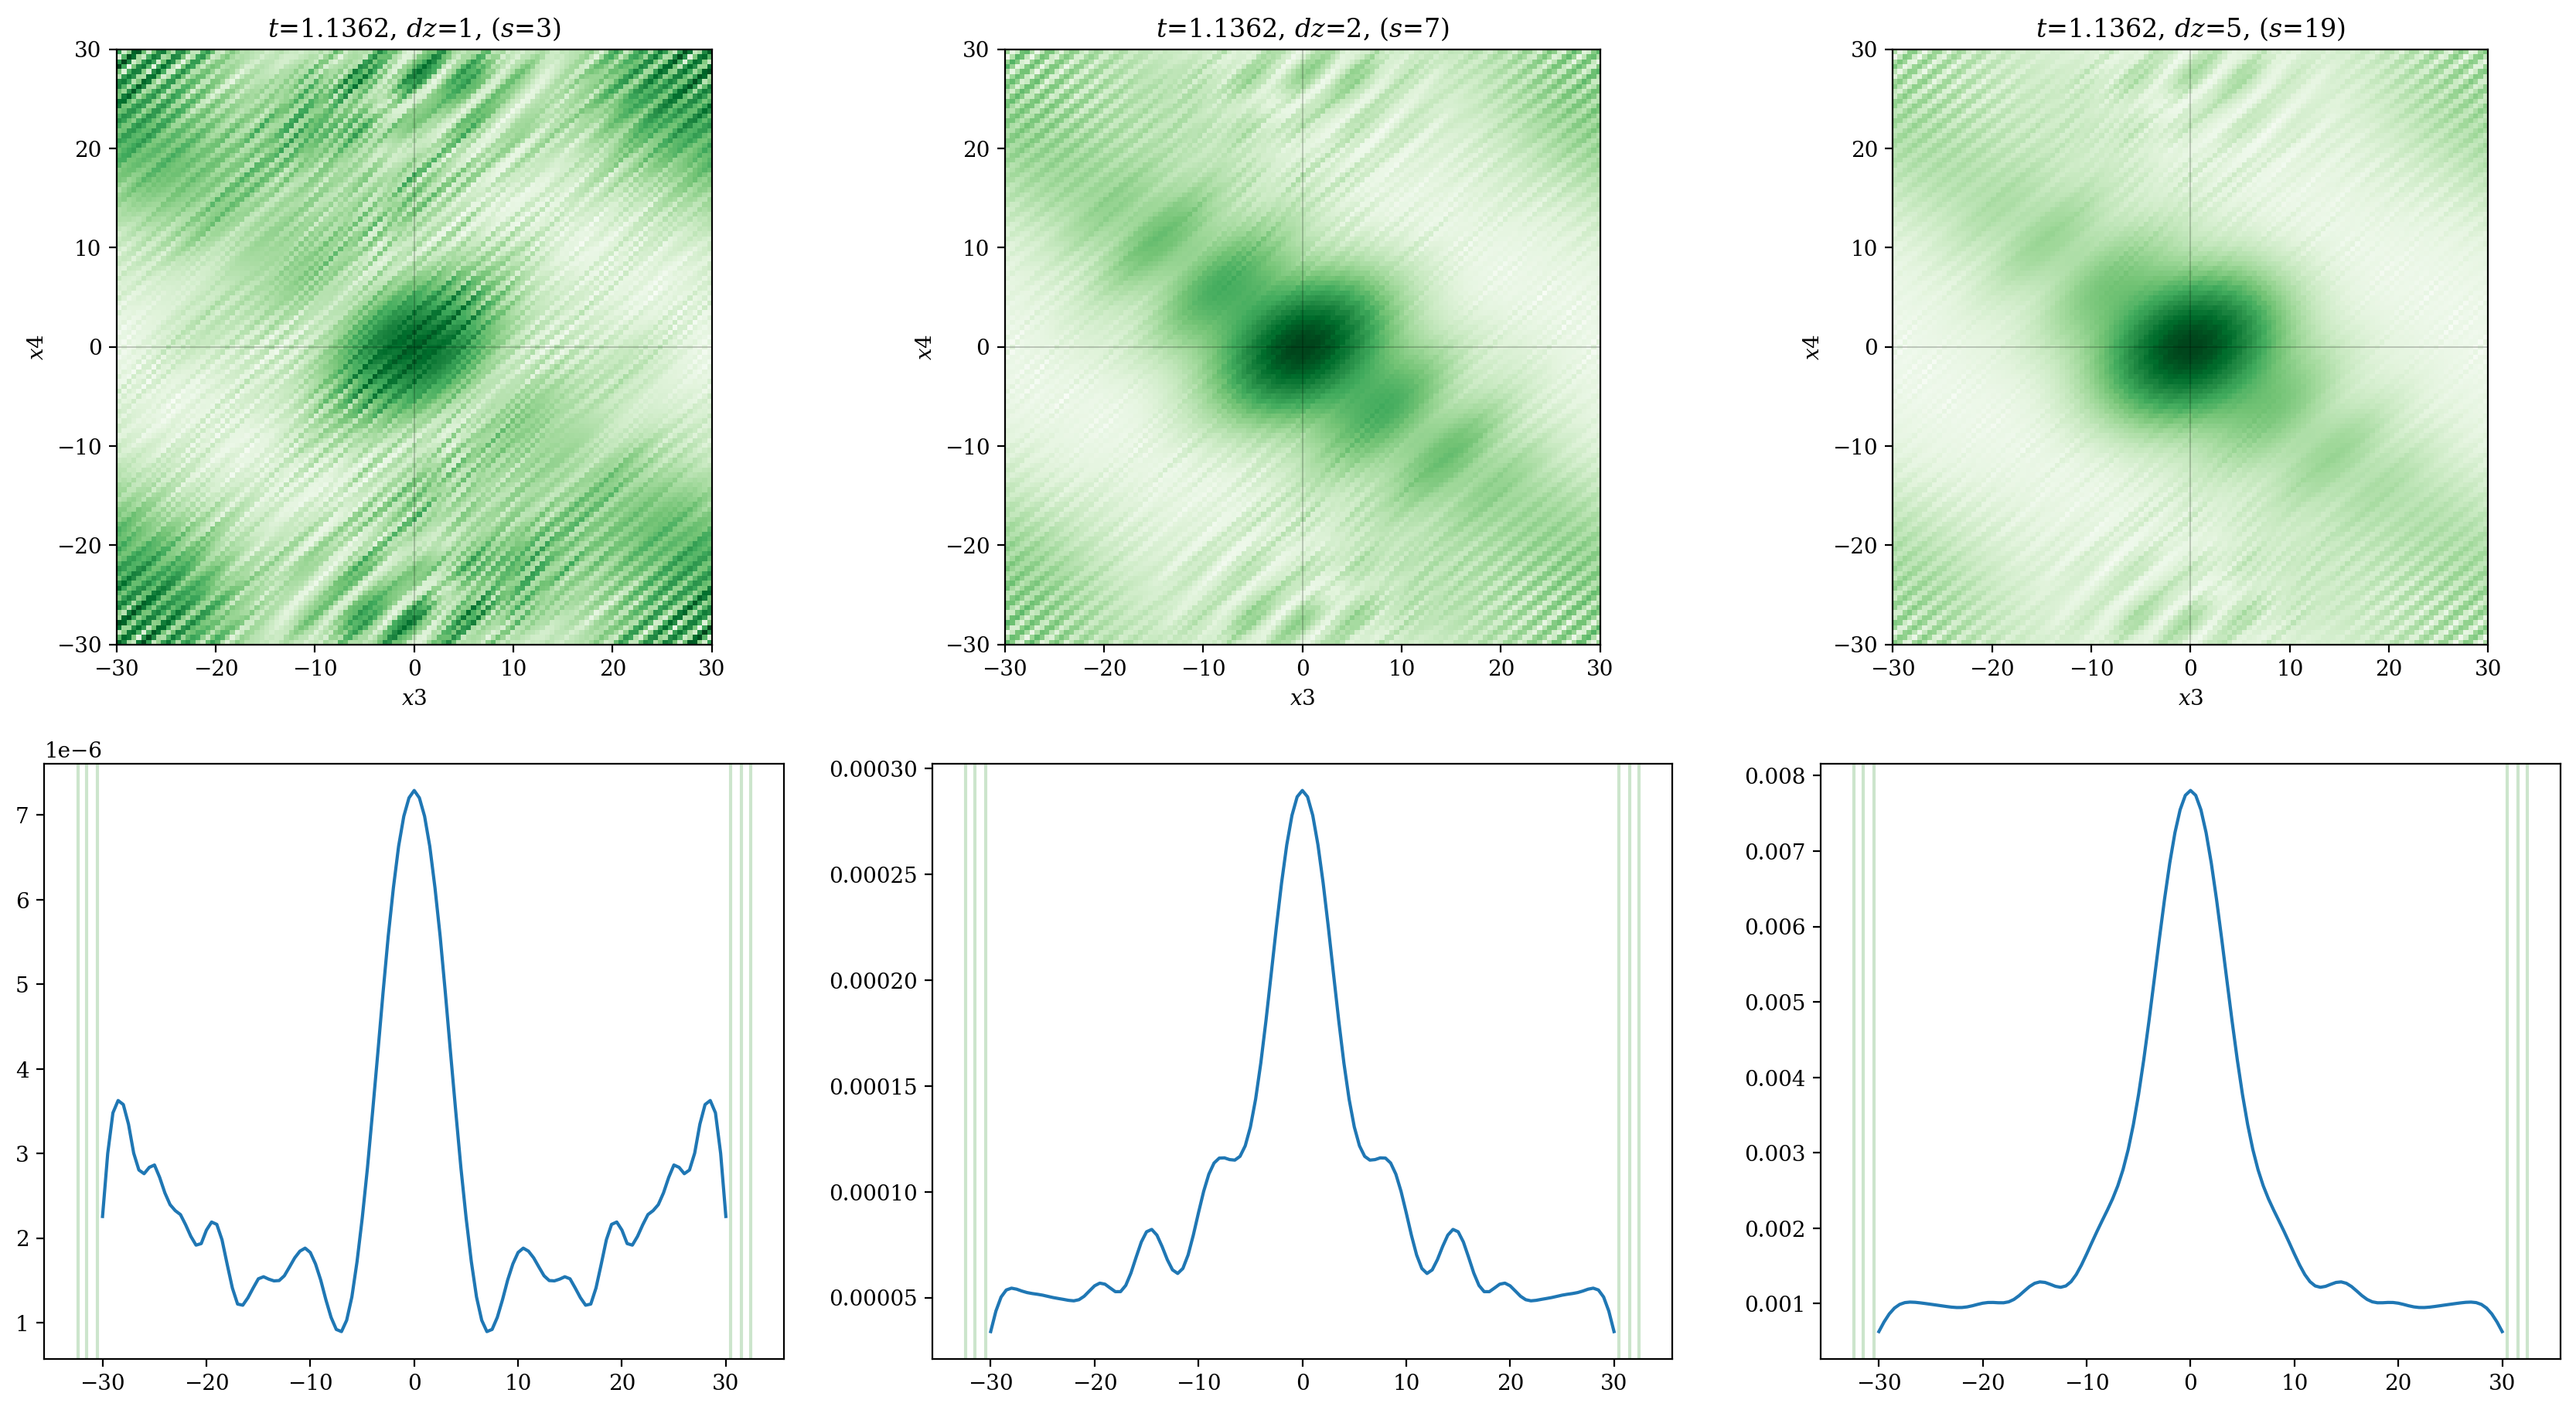

In [174]:
# plot_bs_l_free_time(psi2, t2, midCutZ=[1,3,10], pltShow=True, pltSave=True)
_ = plot_bs_l_free_time(psi2, t2, midCutZ=[1,2,5], pltShow=True, pltSave=False)

##### BS Timing Scan?

In [84]:
np.array([T_BS, T_BS_L, T_BS_R, tLongestBSPulse]) * 1000

array([1169.9 , 1136.65, 1203.15,   66.5 ])

In [85]:
(T_BS-1.5*tLongestBSPulse, T_BS+0.5*tLongestBSPulse)

(1.07015, 1.20315)

In [86]:
# T_BS_L_SCAN_TARGETS = np.arange(T_BS-1.5*tLongestBSPulse, T_BS+0.5*tLongestBSPulse, 50*dt)
T_BS_L_SCAN_TARGETS = np.arange(1.00,1.30, 20*dt)
l.info(f"""len(T_BS_L_SCAN_TARGETS) = {len(T_BS_L_SCAN_TARGETS)}
T_BS_L_SCAN_TARGETS: {T_BS_L_SCAN_TARGETS}""")

len(T_BS_L_SCAN_TARGETS) = 151
T_BS_L_SCAN_TARGETS: [1.    1.002 1.004 1.006 1.008 1.01  1.012 1.014 1.016 1.018 1.02  1.022
 1.024 1.026 1.028 1.03  1.032 1.034 1.036 1.038 1.04  1.042 1.044 1.046
 1.048 1.05  1.052 1.054 1.056 1.058 1.06  1.062 1.064 1.066 1.068 1.07
 1.072 1.074 1.076 1.078 1.08  1.082 1.084 1.086 1.088 1.09  1.092 1.094
 1.096 1.098 1.1   1.102 1.104 1.106 1.108 1.11  1.112 1.114 1.116 1.118
 1.12  1.122 1.124 1.126 1.128 1.13  1.132 1.134 1.136 1.138 1.14  1.142
 1.144 1.146 1.148 1.15  1.152 1.154 1.156 1.158 1.16  1.162 1.164 1.166
 1.168 1.17  1.172 1.174 1.176 1.178 1.18  1.182 1.184 1.186 1.188 1.19
 1.192 1.194 1.196 1.198 1.2   1.202 1.204 1.206 1.208 1.21  1.212 1.214
 1.216 1.218 1.22  1.222 1.224 1.226 1.228 1.23  1.232 1.234 1.236 1.238
 1.24  1.242 1.244 1.246 1.248 1.25  1.252 1.254 1.256 1.258 1.26  1.262
 1.264 1.266 1.268 1.27  1.272 1.274 1.276 1.278 1.28  1.282 1.284 1.286
 1.288 1.29  1.292 1.294 1.296 1.298 1.3  ]


In [276]:
t_bs_scan_diag_result = []
t_bs_scan_diag_result2 = []
for (ind, tbs) in tqdm(enumerate(T_BS_L_SCAN_TARGETS),total=len(T_BS_L_SCAN_TARGETS)):
    N_FREE_TO_BS = ceil((tbs-t)/dt)
    (t2,psi2,phi2) = evolve_free_part(t,psi,swnf,N_FREE_TO_BS)
    scattering_evolve_loop_plot(t2,ind,psi2,phi2, plt_show=False, plt_save=True)
    scattering_evolve_loop_plot_alt(t2,ind,psi2,phi2, plt_show=False, plt_save=True, logPlus=1, po=0.1)
    (tbs_result, tbs_resul2) = plot_bs_l_free_time(psi2, t2, midCutZ=[1,2,5], pltShow=False, pltSave=True)
    t_bs_scan_diag_result.append(tbs_result)
    t_bs_scan_diag_result2.append(tbs_resul2)
    gc.collect()
    # print(N_FREE_TO_BS)

  0%|          | 0/151 [00:00<?, ?it/s]

In [277]:
with pgzip.open(output_prefix+f"t_bs_scan_diag_result"+output_ext,'wb', thread=8, blocksize=1*10**8) as file:
    pickle.dump(t_bs_scan_diag_result, file) 
with pgzip.open(output_prefix+f"t_bs_scan_diag_result2"+output_ext,'wb', thread=8, blocksize=1*10**8) as file:
    pickle.dump(t_bs_scan_diag_result2, file) 

In [278]:
gc.collect()

5839804

In [279]:
T_MR

0.6

In [280]:
T_MR*2*v3

79.80625517025994

In [281]:
T_MR*2*v4

59.85469137769496

In [282]:
m3/(m3+m4)*v4*(2*T_MR) #v4

25.652010590440696

In [283]:
m4/(m3+m4)*v4*(2*T_MR) #v3

34.20268078725426

In [284]:
t_bs_scan_diag_result_bk = t_bs_scan_diag_result

In [285]:
t_bs_scan_diag_result_np = np.array(t_bs_scan_diag_result)

In [286]:
((nx-1)//2-middle_mask,(nx-1)//2+1+middle_mask)

(54, 67)

In [75]:
mask = np.ones(t_bs_scan_diag_result_np.shape[1], dtype=bool)
middle_mask = 6
mased_bs_scan = None
mased_bs_scan = np.copy(t_bs_scan_diag_result_np[:,1])
# mased_bs_scan[:,(nx-1)//2-middle_mask : (nx-1)//2+1+middle_mask] = 0

plt.imshow(np.flipud(mased_bs_scan)**0.001, 
# plt.imshow(np.flipud(t_bs_scan_diag_result_np[:,0]), 
           extent=[-xmax,xmax,T_BS_L_SCAN_TARGETS[0],T_BS_L_SCAN_TARGETS[-1]],
           aspect=2*xmax/(T_BS_L_SCAN_TARGETS[-1]-T_BS_L_SCAN_TARGETS[0]), cmap="Greens"
          )
plt.colorbar()
plt.show()

NameError: name 't_bs_scan_diag_result_np' is not defined

In [290]:
T_BS

1.1699

In [291]:
mask

array([ True,  True,  True])

In [292]:
filtered_data

NameError: name 'filtered_data' is not defined

In [293]:
10*dx

5.0

In [294]:
t_bs_scan_diag_result_np.shape

(151, 3, 121)

In [78]:
output_prefix

'output/twoParticleSim/20240903-163516-TFF/'

In [296]:
psixeqList = []
psiyeqList = []
for (ind, tbs) in enumerate(T_BS_L_SCAN_TARGETS):
    midCut = t_bs_scan_diag_result2[ind]
    psixeq = np.trapz(midCut[0], xlin, axis=0)
    psiyeq = np.trapz(midCut[0], zlin, axis=1)
    psixeqList.append(psixeq)
    psiyeqList.append(psiyeq)
psixeqList = np.array(psixeqList)
psiyeqList = np.array(psiyeqList)

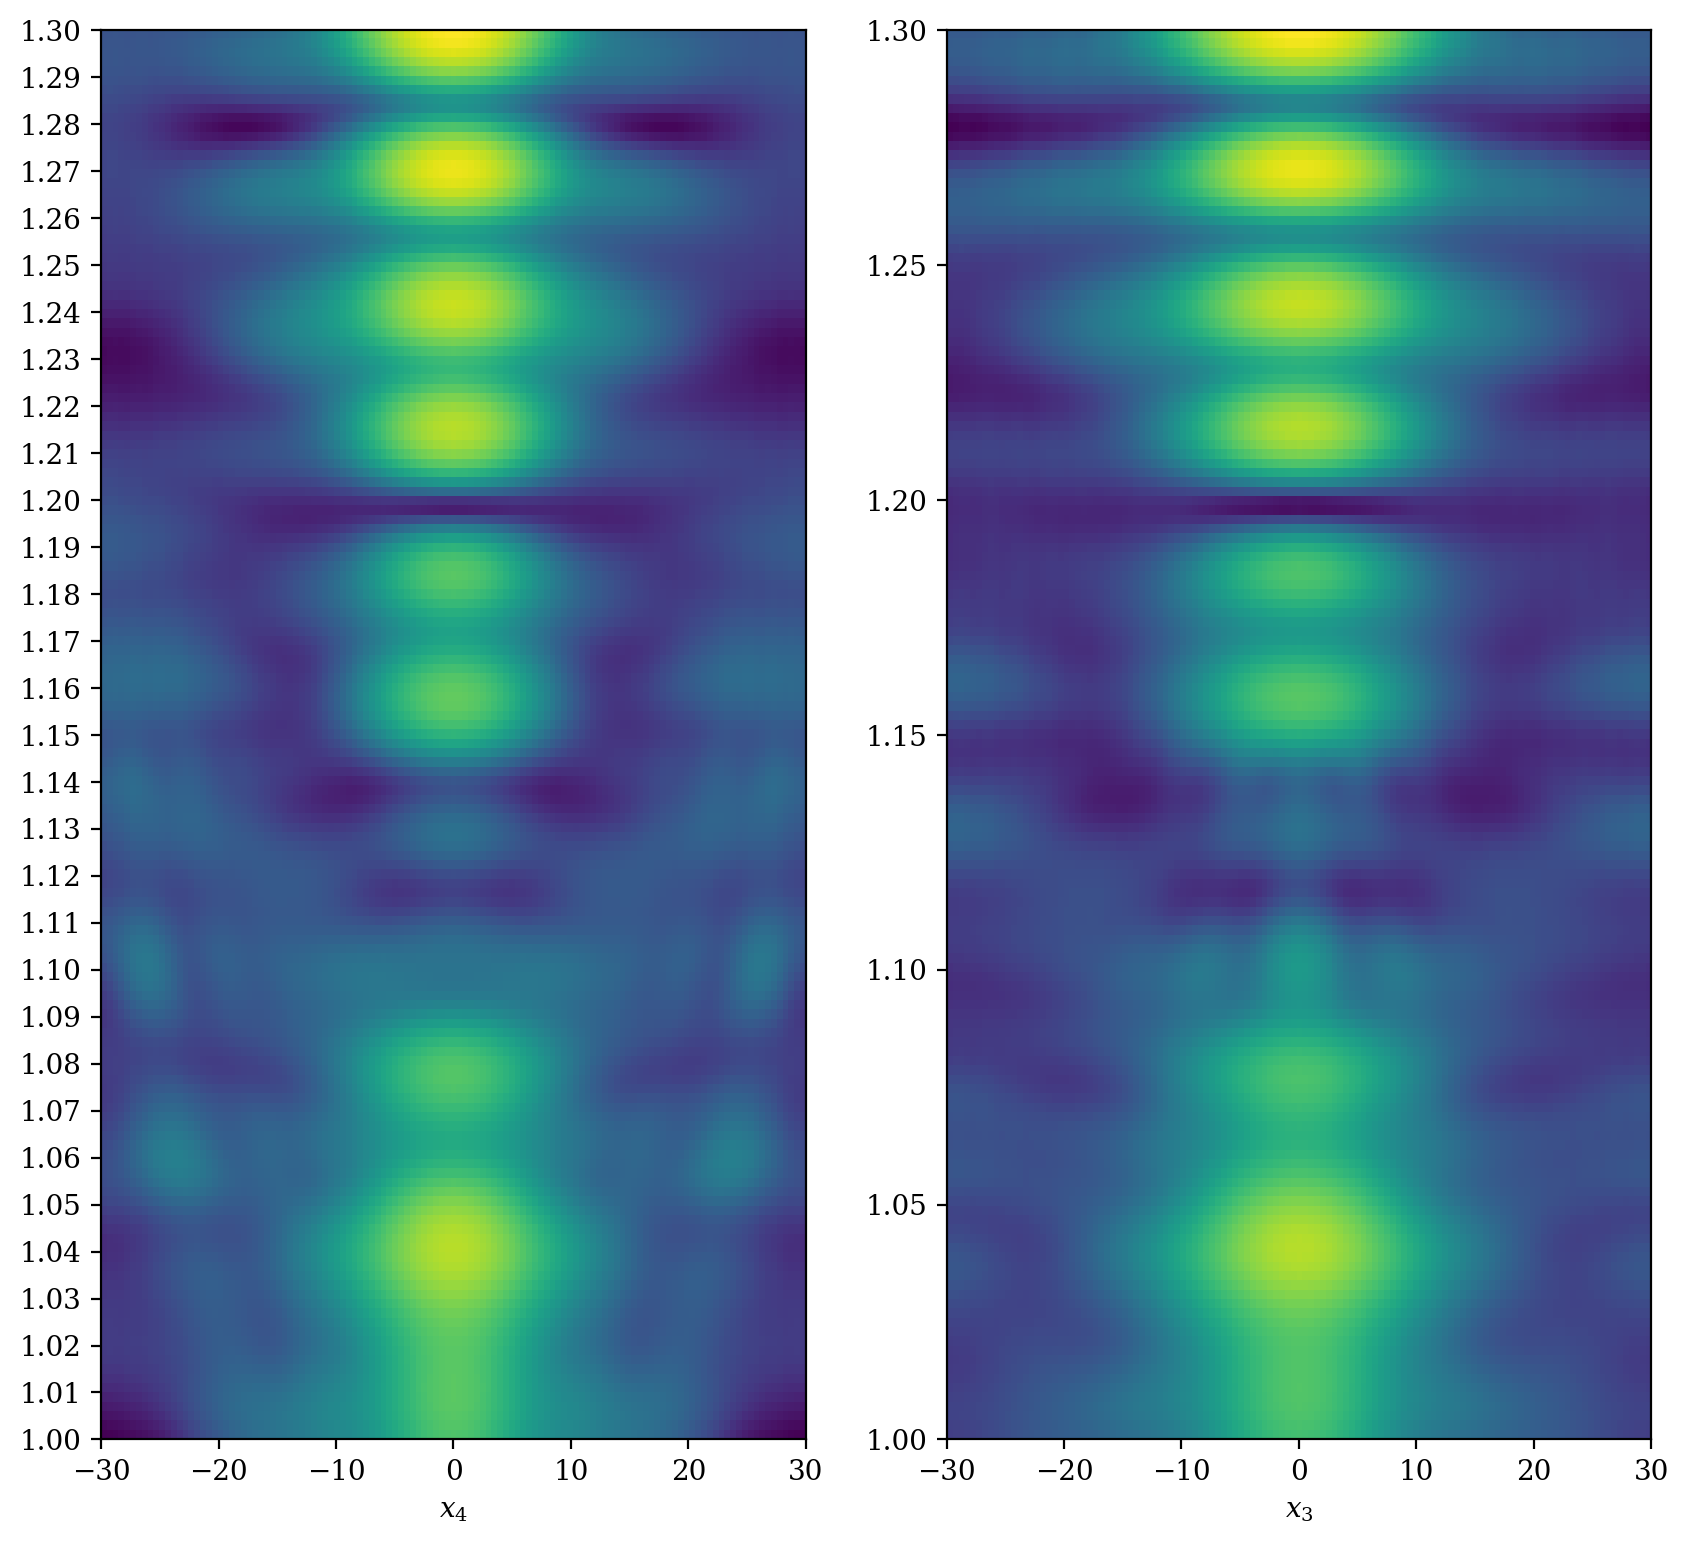

In [332]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(np.flipud(psixeqList)**0.001,
           extent=[-xmax,xmax, T_BS_L_SCAN_TARGETS[0], T_BS_L_SCAN_TARGETS[-1]],
           aspect= 4*xmax/(T_BS_L_SCAN_TARGETS[-1]-T_BS_L_SCAN_TARGETS[0])
          )
plt.xlabel("$x_4$")
plt.yticks(np.linspace(T_BS_L_SCAN_TARGETS[0],T_BS_L_SCAN_TARGETS[-1], 31))
plt.subplot(1,2,2)
plt.imshow(np.flipud(psiyeqList)**0.001,
           extent=[-xmax,xmax, T_BS_L_SCAN_TARGETS[0], T_BS_L_SCAN_TARGETS[-1]],
           aspect= 4*xmax/(T_BS_L_SCAN_TARGETS[-1]-T_BS_L_SCAN_TARGETS[0])
          )
plt.xlabel("$x_3$")
plt.show()

In [274]:
1.1*v4scat

23.514343041237307

In [275]:
1.1*v3scat

31.35245738831641

##### Actual BS Pulses

In [87]:
# may 22, oh fuck it, I'm just going to run with whatever

In [88]:
del psi2, phi2

NameError: name 'psi2' is not defined

In [87]:
t=0.6347

In [92]:
(t,psi,phi) = evolve_free_part(t,psi,swnf,N_FREE_TO_BS)

finding looplift candidates


In [112]:
###0 THIS CELL IS COPIED CODE FROM INITIAL SCATTERING!!!!! 
t=0.6347 + N_FREE_TO_BS*dt
print_every = 10 # every us 
# frames_count = ceil(NLongestBSPulse/print_every) # until T_a34off
frames_count = ceil((T_BS_R + 11*dt - t)/dt/print_every)
export_every = 30
total_steps = print_every * frames_count
t_end_target = frames_count*print_every*dt
evolve_loop_time_estimate = total_steps*evolve_loop_time_delta*1.1
l.info(f"""t={t},
print_every = {print_every}, \tframes_count = {frames_count}, total_steps = {total_steps}
Target simulation end time = {t_end_target} ms, {round(t+t_end_target,6)}
Estimated script runtime = {evolve_loop_time_estimate} which is {datetime.now()+evolve_loop_time_estimate}""")

t=1.1362,
print_every = 10, 	frames_count = 69, total_steps = 690
Target simulation end time = 0.069 ms, 1.2052
Estimated script runtime = 3:09:48.655344 which is 2024-09-19 20:54:15.690155


In [108]:
N_FREE_TO_BS*dt

1.1362

In [106]:
T_END

1.20315

In [103]:
t3pi1

0.0498

In [123]:
# evolve_loop_time_delta = datetime.timedelta(seconds=1)

In [87]:
len(comboSettSet)

16

In [113]:
comboSettSetS = set()
for combSetH in comboSettSet:
    print(combSetH)
    for tCombo in combSetH:
        (vv3, tt3), (vv4, tt4) = tCombo 
        # print(((vv3, tt3), (vv4, tt4)))
        # print(((round(vv3), round(tt3,6)), (round(vv4), round(tt4,6))))
        # print(((round(vv3/VR/0.02), round(tt3,6)), (round(vv4/VR/0.015), round(tt4,6))))
        # print(f"{round(vv3/VR/0.02)}π/4, {round(vv4/VR/0.015)}π/4")
        # print(f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}")
        settingStr = f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}"
        comboSettSetS.add(settingStr)
        print(settingStr)

[((0, 1), (1502.235391440187, 0.0665)), ((0, 1), (4506.706174320561, 0.0665)), ((12017.883131521496, 0.0498), (1502.235391440187, 0.0665)), ((12017.883131521496, 0.0498), (4506.706174320561, 0.0665))]
0-1
0-3
6-1
6-3
[((6008.941565760748, 0.0499), (9013.412348641123, 0.0664)), ((6008.941565760748, 0.0499), (0, 1)), ((2002.9805219202494, 0.0499), (9013.412348641123, 0.0664)), ((2002.9805219202494, 0.0499), (0, 1))]
3-6
3-0
1-6
1-0
[((10014.902609601248, 0.0498), (6008.941565760748, 0.0664)), ((10014.902609601248, 0.0498), (9013.412348641123, 0.0664)), ((6008.941565760748, 0.0499), (6008.941565760748, 0.0664)), ((6008.941565760748, 0.0499), (9013.412348641123, 0.0664))]
5-4
5-6
3-4
3-6
[((12017.883131521496, 0.0498), (4506.706174320561, 0.0665)), ((12017.883131521496, 0.0498), (7511.176957200935, 0.0664)), ((8011.922087680998, 0.0498), (4506.706174320561, 0.0665)), ((8011.922087680998, 0.0498), (7511.176957200935, 0.0664))]
6-3
6-5
4-3
4-5
[((2002.9805219202494, 0.0499), (0, 1)), ((2002.

In [89]:
thispklfile

NameError: name 'thispklfile' is not defined

In [184]:
os.path.exists(thispklfile)

False

In [103]:
gc.collect()
print_ram_usage()

                           phi:  3.2 GiB
                          phi2:  3.2 GiB
                      cosZGrid: 114.5 KiB
                         gx3x4: 114.5 KiB
                        gridX3: 114.5 KiB
                        gridX4: 114.5 KiB
                        tbtest: 94.1 KiB
                          _iii: 10.1 KiB
                          _i99: 10.1 KiB
                         _i100: 10.1 KiB


In [171]:
gc.collect()
for cind, combSetH in enumerate(comboSettSet):
    l.info(f"Combo Set ind = {cind}")
    for tCombo in combSetH:
        t=1.2052
        (vv3, tt3), (vv4, tt4) = tCombo 
        # IDEA: use 1/16 division scans? and scan all compo rather than just bell angles
        # IDEA: also need to scan T_BS using corrE as signal.
        # print(((vv3, tt3), (vv4, tt4)))
        # settingStr = ((round(vv3), round(tt3,6)), (round(vv4), round(tt4,6)))
        settingStr = f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}"
        # l.info(settingStr)
        l.info(f"  Setting: {round(vv3/VR/0.02)}π/4, {round(vv4/VR/0.015)}π/4, \t ShortForm {settingStr}")
        thispklfile = output_prefix+f"psi at t={round(t,6)} s={settingStr}"+output_ext
        if os.path.exists(thispklfile): 
            l.info(f"    Skipped: {thispklfile}")
            continue
        
        l.info("    Calculating...")
        t=0.6347
        data_folder = "20240919-173152-TFF"#"20240711-234819-TFF" # "20240521-231755-TFF"
        psi = None
        phi = None
        gc.collect()
        with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl'
                        , 'rb', thread=8) as file:
            psi = pickle.load(file)
        phi, swnf = phiAndSWNF(psi, nthreads=7)
        gc.collect()
        (t,psi,phi) = evolve_free_part(t,psi,swnf,N_FREE_TO_BS)
        
        ### THIS CELL IS COPIED CODE FROM INITIAL SCATTERING!!!!! 
        ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
        
        evolve_many_loops_start = datetime.now()
        frameAcc = 0 
        with ProgressBar(total=total_steps) as progressbar:
            for f in range(frames_count):
                evolve_many_loops_inner_now = datetime.now()
                tP = evolve_many_loops_inner_now - evolve_many_loops_start
                # if frameAcc > 0: 
                #     tR = (frames_count-frameAcc)* tP/frameAcc
                #     tE = datetime.now() + tR
                #     l.info(f"Now f={frameAcc}, t={round(t,6)}, tP={tP}, tR={tR}, tE = {tE}")
                # scattering_evolve_loop_plot(t,f,psi,phi, plt_show=False, plt_save=True)
                # scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
                gc.collect()
                (t,psi,phi) = scattering_evolve_bragg_loop_helper2(t,psi,swnf,
                                  steps=print_every,progress_proxy=progressbar,s34=0,
                                  t3mid=T_BS, t3wid=tt3, v3pot=vv3, #### THESE CHANGED, EVERYTHING ELSE COPIED
                                  t4mid=T_BS, t4wid=tt4, v4pot=vv4, ####     
                                  numba_threads = 8,
                                  fftw_threads  = 8             
                                  )
                frameAcc += 1
                # if frameAcc % export_every == 0:
                #     with pgzip.open(output_prefix+f"psi at t={round(t,6)}"+output_ext,
                #         'wb', thread=8, blocksize=1*10**8) as file:
                #         pickle.dump(psi, file) 
                        
        f += 1
        # scattering_evolve_loop_plot(t,f+1,psi,phi, plt_show=False, plt_save=True)
        # scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
        phi = None
        with pgzip.open(thispklfile,
                        'wb', thread=8, blocksize=1*10**8) as file:
            pickle.dump(psi, file) 
        gc.collect()

Combo Set ind = 0
  Setting: 0π/4, 1π/4, 	 ShortForm 0-1
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-1.pgz.pkl
  Setting: 0π/4, 3π/4, 	 ShortForm 0-3
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-3.pgz.pkl
  Setting: 6π/4, 1π/4, 	 ShortForm 6-1
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=6-1.pgz.pkl
  Setting: 6π/4, 3π/4, 	 ShortForm 6-3
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=6-3.pgz.pkl
Combo Set ind = 1
  Setting: 3π/4, 6π/4, 	 ShortForm 3-6
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=3-6.pgz.pkl
  Setting: 3π/4, 0π/4, 	 ShortForm 3-0
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=3-0.pgz.pkl
  Setting: 1π/4, 6π/4, 	 ShortForm 1-6
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=1-6.pgz.pkl
  Setting: 1π/4, 0π/4, 	 ShortForm 1-0
    Skipped: output/twoParticleSim/20240919-173152-TFF/ps

  0%|          | 0/690 [00:00<?, ?it/s]

finding looplift candidates
/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py:49: NumbaWarning: Cannot cache compiled function "scattering_evolve_bragg_loop_helper2" as it uses lifted code
  @jit(forceobj=True, cache=True)

/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py:49: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "scattering_evolve_bragg_loop_helper2" failed type inference due to: Invalid use of type(CPUDispatcher(<function toPhi at 0x1452aa2a0>)) with parameters (array(complex128, 4d, C), complex128, nthreads=int64)

During: resolving callee type: type(CPUDispatcher(<function toPhi at 0x1452aa2a0>))
During: typing of call at /var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py (73)


File "../../../../../../../../var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py", line 73:
<source missing, REPL/exec in use?>



  0%|          | 0/690 [00:00<?, ?it/s]

  Setting: 0π/4, 7π/4, 	 ShortForm 0-7
    Calculating...


...

finding looplift candidates
/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py:49: NumbaWarning: Cannot cache compiled function "scattering_evolve_bragg_loop_helper2" as it uses lifted code
  @jit(forceobj=True, cache=True)

/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py:49: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "scattering_evolve_bragg_loop_helper2" failed type inference due to: Invalid use of type(CPUDispatcher(<function toPhi at 0x1452aa2a0>)) with parameters (array(complex128, 4d, C), complex128, nthreads=int64)

During: resolving callee type: type(CPUDispatcher(<function toPhi at 0x1452aa2a0>))
During: typing of call at /var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py (73)


File "../../../../../../../../var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_94507/2064340682.py", line 73:
<source missing, REPL/exec in use?>



  0%|          | 0/690 [00:00<?, ?it/s]

  Setting: 2π/4, 7π/4, 	 ShortForm 2-7
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=2-7.pgz.pkl
Combo Set ind = 7
  Setting: 7π/4, 2π/4, 	 ShortForm 7-2
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=7-2.pgz.pkl
  Setting: 7π/4, 4π/4, 	 ShortForm 7-4
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=7-4.pgz.pkl
  Setting: 5π/4, 2π/4, 	 ShortForm 5-2
    Calculating...


  0%|          | 0/690 [00:00<?, ?it/s]

  Setting: 5π/4, 4π/4, 	 ShortForm 5-4
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=5-4.pgz.pkl
Combo Set ind = 8
  Setting: 1π/4, 0π/4, 	 ShortForm 1-0
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=1-0.pgz.pkl
  Setting: 1π/4, 6π/4, 	 ShortForm 1-6
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=1-6.pgz.pkl
  Setting: 3π/4, 0π/4, 	 ShortForm 3-0
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=3-0.pgz.pkl
  Setting: 3π/4, 6π/4, 	 ShortForm 3-6
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=3-6.pgz.pkl
Combo Set ind = 9
  Setting: 6π/4, 3π/4, 	 ShortForm 6-3
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=6-3.pgz.pkl
  Setting: 6π/4, 1π/4, 	 ShortForm 6-1
    Skipped: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=6-1.pgz.pkl
  Setting: 0π/4, 3π/4, 	 ShortForm 0-3
    Skipped: output/twoParticleSim/20240919-173152-TFF/ps

In [149]:
time.sleep(3)

In [119]:
# numba.config.NUMBA_NUM_THREADS

10

In [118]:
# numba.set_num_threads(6)

In [120]:
numba.get_num_threads()

6

                      cosZGrid: 114.5 KiB
                         gx3x4: 114.5 KiB
                        tbtest: 94.1 KiB
                         _i121: 10.5 KiB
                         _i123: 10.5 KiB
                         _i157: 10.5 KiB
                         _i159: 10.5 KiB
                         _i162: 10.5 KiB
                         _i165: 10.5 KiB
                         _i115: 10.2 KiB


In [91]:
settingStr = f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}"
thispklfile = output_prefix+f"psi at t={round(t,6)} s={settingStr}"+output_ext
os.path.exists(thispklfile)

True

In [60]:
os.path.exists(output_prefix+f"psi at t={round(0.6347,6)}"+output_ext)

False

##### Massive everything scans

In [444]:
omegaNDivs = 8
omegaNDivsList = np.arange(0,2*omegaNDivs+1)
# omegaNDivsList = np.flip(omegaNDivsList)
omegalist = pi/omegaNDivs*omegaNDivsList
l.info(f"omegaNDivsList = {omegaNDivsList}")
l.info(f"omegalist = {omegalist}")

omegaNDivsList = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
omegalist = [0.         0.39269908 0.78539816 1.17809725 1.57079633 1.96349541
 2.35619449 2.74889357 3.14159265 3.53429174 3.92699082 4.3196899
 4.71238898 5.10508806 5.49778714 5.89048623 6.28318531]


In [445]:
frames_count

69

In [446]:
print_every

10

In [447]:
2%2

0

In [448]:
(2%omegaNDivs)

2

In [449]:
int((V4pi1*5/omegaNDivs)/VR/0.015*(omegaNDivs/4))

4

In [451]:
for (i3,o3) in enumerate(omegaNDivsList):
    for (i4,o4) in enumerate(omegaNDivsList):
        # if i3>=1: break # DEBUGGING SKIP LOOP
        
        t=1.2052
        # (vv3, tt3), (vv4, tt4) = tCombo 
        # print(((vv3, tt3), (vv4, tt4)))
        # settingStr = ((round(vv3), round(tt3,6)), (round(vv4), round(tt4,6)))
        tt3 = t3pi1
        tt4 = t4pi1
        vv3 = V3pi1 * o3/omegaNDivs
        vv4 = V4pi1 * o4/omegaNDivs
        sv3 = round(vv3/VR/0.02 *(omegaNDivs/4))
        sv4 = round(vv4/VR/0.015*(omegaNDivs/4))
        assert sv3 == o3 and sv4 == o4, "I think this should be fine?"
        settingStr = f"{sv3}-{sv4}"
        print(f"i3={i3}, i4={i4}, o3={o3}, o4={o4}, sv3={sv3}, sv4={sv4}") 
        # l.info(settingStr)
        if omegaNDivs == 4 or (sv3%(omegaNDivs/4)==0 and sv4%(omegaNDivs/4)==0):
            settingStr = f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}"
            thispklfile = output_prefix+f"psi at t={round(t,6)} s={settingStr}"+output_ext
            thisPhiCorrFile = output_prefix+f"phi-corr-stats s={settingStr}"+output_ext
        else:
            thispklfile = output_prefix+f"psi at t={round(t,6)} s={settingStr}D{omegaNDivs}"+output_ext
            thisPhiCorrFile = output_prefix+f"phi-corr-stats s={settingStr}D{omegaNDivs}"+output_ext

        l.info(f"  Setting: {sv3}π/{omegaNDivs}, {sv4}π/{omegaNDivs}, \t path: {thispklfile}")
        if os.path.exists(thispklfile): 
            l.info(f"    File exist, SKIPPED (yey)")
            continue
        

        l.info("    Calculating...")
        t=0.6347
        data_folder = "20240919-173152-TFF"#"20240919-173152-TFF" #"20240711-234819-TFF" # "20240521-231755-TFF"
        psi = None
        phi = None
        gc.collect()

        # continue # DEBUGGING SKIP LOOP SPEED UP
        with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl', 'rb', thread=8) as file:
            psi = pickle.load(file)
        phi, swnf = phiAndSWNF(psi, nthreads=7)
        gc.collect()
        (t,psi,phi) = evolve_free_part(t,psi,swnf,N_FREE_TO_BS)
        
        ### THIS CELL IS COPIED CODE FROM INITIAL SCATTERING!!!!! 
        ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
        
        evolve_many_loops_start = datetime.now()
        frameAcc = 0 
        with ProgressBar(total=total_steps) as progressbar:
            for f in range(frames_count):
                evolve_many_loops_inner_now = datetime.now()
                tP = evolve_many_loops_inner_now - evolve_many_loops_start
                # if frameAcc > 0: 
                #     tR = (frames_count-frameAcc)* tP/frameAcc
                #     tE = datetime.now() + tR
                #     l.info(f"Now f={frameAcc}, t={round(t,6)}, tP={tP}, tR={tR}, tE = {tE}")
                # scattering_evolve_loop_plot(t,f,psi,phi, plt_show=False, plt_save=True)
                # scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
                gc.collect()
                (t,psi,phi) = scattering_evolve_bragg_loop_helper2(t,psi,swnf,
                                  steps=print_every,progress_proxy=progressbar,s34=0,
                                  t3mid=T_BS, t3wid=tt3, v3pot=vv3, #### THESE CHANGED, EVERYTHING ELSE COPIED
                                  t4mid=T_BS, t4wid=tt4, v4pot=vv4,  ####      
                                  numba_threads = 8,
                                  fftw_threads  = 8              
                                  )
                frameAcc += 1
                # t += print_every * dt
                # if frameAcc % export_every == 0:
                #     with pgzip.open(output_prefix+f"psi at t={round(t,6)}"+output_ext,
                #         'wb', thread=8, blocksize=1*10**8) as file:
                #         pickle.dump(psi, file) 
                        
        f += 1
        l.info(f"    t = {t}")
        # scattering_evolve_loop_plot(t,f+1,psi,phi, plt_show=False, plt_save=True)
        # scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)


        ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
        scattering_evolve_loop_plot(t,settingStr,psi,phi, plt_show=False, plt_save=True)
        scattering_evolve_loop_plot_alt(t,settingStr,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
        psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True,save_str=f"s={settingStr}",title_str=f"s={settingStr}",cmax3x=2e-3,cmax4x=2e-3,cmax3p=2e-5,cmax4p=2e-5)
        psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True,save_str=f"s={settingStr}",title_str=f"s={settingStr}",cmax3x=5e-3,cmax4x=5e-3,cmax3p=5e-5,cmax4p=5e-5)
        psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True,save_str=f"s={settingStr}",title_str=f"s={settingStr}",cmax3x=1e-3,cmax4x=1e-3,cmax3p=1e-5,cmax4p=1e-5)
        tempPlotOutput = plot_g34_v2(phi, cutPlot=1.5, saveFig=True, pMaxCut=2,title2=f"$\phi_3$={round(vv3/VR/0.02)}π/4, $\phi_4=${round(vv4/VR/0.015)}π/4",title2filestr=settingStr, skipPlot=True)
        with pgzip.open(thisPhiCorrFile,'wb', thread=8, blocksize=1*10**8) as file:
            pickle.dump(tempPlotOutput, file)
        l.info(f"  calced corrE({settingStr}) = {corrE(np.flipud(tempPlotOutput[4].T))}")
        ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 


        phi = None 
        with pgzip.open(thispklfile,
                        'wb', thread=8, blocksize=1*10**8) as file:
            pickle.dump(psi, file) 
        gc.collect()
    



i3=0, i4=0, o3=0, o4=0, sv3=0, sv4=0
  Setting: 0π/8, 0π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-0.pgz.pkl
    File exist, SKIPPED (yey)
i3=0, i4=1, o3=0, o4=1, sv3=0, sv4=1
  Setting: 0π/8, 1π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-1D8.pgz.pkl
    Calculating...


  0%|          | 0/690 [00:00<?, ?it/s]

    t = 1.2051999999999925
  calced corrE(0-1) = 0.8800574073000016
i3=0, i4=2, o3=0, o4=2, sv3=0, sv4=2
  Setting: 0π/8, 2π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-1.pgz.pkl
    File exist, SKIPPED (yey)
i3=0, i4=3, o3=0, o4=3, sv3=0, sv4=3
  Setting: 0π/8, 3π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-3D8.pgz.pkl
    Calculating...


  0%|          | 0/690 [00:00<?, ?it/s]

    t = 1.2051999999999925
  calced corrE(0-3) = 0.48266817100358844
i3=0, i4=4, o3=0, o4=4, sv3=0, sv4=4
  Setting: 0π/8, 4π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-2.pgz.pkl
    File exist, SKIPPED (yey)
i3=0, i4=5, o3=0, o4=5, sv3=0, sv4=5
  Setting: 0π/8, 5π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-5D8.pgz.pkl
    Calculating...


...

    t = 1.2051999999999925
  calced corrE(1-0) = 0.8703246767339692
i3=1, i4=1, o3=1, o4=1, sv3=1, sv4=1
  Setting: 1π/8, 1π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=1-1D8.pgz.pkl
    Calculating...


  0%|          | 0/690 [00:00<?, ?it/s]

    t = 1.2051999999999925
  calced corrE(1-1) = 0.7316488334024162
i3=1, i4=2, o3=1, o4=2, sv3=1, sv4=2
  Setting: 1π/8, 2π/8, 	 path: output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=1-2D8.pgz.pkl
    Calculating...


  0%|          | 0/690 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [451]:
for (i3,o3) in enumerate(omegaNDivsList):
    for (i4,o4) in enumerate(omegaNDivsList):
        print(i3,o3,i4,o4)
        print(f"  {o3+o4}\t {(o3+o4)*2*pi/omegaNDivs}")

0 0 0 0
  0	 0.0
0 0 1 1
  1	 0.7853981633974483
0 0 2 2
  2	 1.5707963267948966
0 0 3 3
  3	 2.356194490192345
0 0 4 4
  4	 3.141592653589793
0 0 5 5
  5	 3.9269908169872414
0 0 6 6
  6	 4.71238898038469
0 0 7 7
  7	 5.497787143782138
0 0 8 8
  8	 6.283185307179586
0 0 9 9
  9	 7.0685834705770345
0 0 10 10
  10	 7.853981633974483
0 0 11 11
  11	 8.63937979737193
0 0 12 12
  12	 9.42477796076938
0 0 13 13
  13	 10.210176124166829
0 0 14 14
  14	 10.995574287564276
0 0 15 15
  15	 11.780972450961723
0 0 16 16
  16	 12.566370614359172
1 1 0 0
  1	 0.7853981633974483
1 1 1 1
  2	 1.5707963267948966
1 1 2 2
  3	 2.356194490192345
1 1 3 3
  4	 3.141592653589793
1 1 4 4
  5	 3.9269908169872414
1 1 5 5
  6	 4.71238898038469
1 1 6 6
  7	 5.497787143782138
1 1 7 7
  8	 6.283185307179586
1 1 8 8
  9	 7.0685834705770345
1 1 9 9
  10	 7.853981633974483
1 1 10 10
  11	 8.63937979737193
1 1 11 11
  12	 9.42477796076938
1 1 12 12
  13	 10.210176124166829
1 1 13 13
  14	 10.995574287564276
1 1 14 14
 

# Some Correlation Calculations

### Function Definitations (🔄)

In [167]:
# @jit(forceobjd=True, parallel=True)
def gp3p4_dhalo_calc_noAb(phi,cut=5.0,offset3=0,offset4=0):
    ind3 = abs(pzlin-offset3) < (cut+1e-15)*dpz
    ind4 = abs(pzlin-offset4) < (cut+1e-15)*dpz
    gx3x4 = np.trapz(phi[:,:,:,ind4],pzlin[ind4],axis=3)
    gx3x4 = np.trapz(gx3x4[:,ind3,:],pzlin[ind3],axis=1)
    # print(gx3x4.shape)
    return gx3x4 
def gp3p4_dhalo_calc(phiHere,cut=5.0,offset3=0,offset4=0):
    ind3 = abs(pzlin-offset3) < (cut+1e-15)*dpz
    ind4 = abs(pzlin-offset4) < (cut+1e-15)*dpz
    gx3x4 = np.trapz(np.abs(phiHere[:,:,:,ind4])**2,pzlin[ind4],axis=3)
    gx3x4 = np.trapz(gx3x4[:,ind3,:],pzlin[ind3],axis=1)
    xip = pxlin > +0*cut*dpz 
    xim = pxlin < -0*cut*dpz 
    #REVIEW: proper integration box
    gpp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xip],pxlin[xip],axis=0)
    gpm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xip],pxlin[xip],axis=0)
    gmp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xim],pxlin[xim],axis=0)
    gmm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xim],pxlin[xim],axis=0)
    return (gx3x4,[gpp,gpm,gmp,gmm])

In [168]:
def gp3p4_dhaloUD_calc(phi,cut=5.0,offset3=0,offset4=0):
    ind3 = abs(pxlin-offset3) < (cut+1e-15)*dpz
    ind4 = abs(pxlin-offset4) < (cut+1e-15)*dpz
    # print(ind4)
    gx3x4 = np.trapz(np.abs(phi[:,:,ind4,:])**2,pxlin[ind4],axis=2)
    gx3x4 = np.trapz(gx3x4[ind3,:,:],pxlin[ind3],axis=0)
    xip = pxlin > +0*cut*dpz 
    xim = pxlin < -0*cut*dpz 
    gpp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xip],pxlin[xip],axis=0)
    gpm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xip],pxlin[xip],axis=0)
    gmp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xim],pxlin[xim],axis=0)
    gmm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xim],pxlin[xim],axis=0)
    return (gx3x4,[gpp,gpm,gmp,gmm])

In [169]:
def plot_dhalo_gp3p4(gx3x4,cut,offset3=0,offset4=0):
    xip = pxlin > +0*cut*dpz 
    xim = pxlin < -0*cut*dpz 
    gpp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xip],pxlin[xip],axis=0)
    gpm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xip],pxlin[xip],axis=0)
    gmp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xim],pxlin[xim],axis=0)
    gmm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xim],pxlin[xim],axis=0)
    E = (gpp+gmm-gpm-gmp)/((gpp+gmm+gpm+gmp))
    
    plt.imshow(np.flipud(gx3x4.T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Greens')
    plt.title("$g^{(2)}_{\pm\pm}$ of $p_\mathrm{cut} = "+str(cut)+"dpz$ and $E="+str(round(E,4))+"$")
    plt.xlabel("$p_3$")
    plt.ylabel("$p_4$")
    plt.axhline(y=0,color='k',alpha=0.2,linewidth=0.7)
    plt.axvline(x=0,color='k',alpha=0.2,linewidth=0.7)
    plt.text(+pxmax*0.6/(hb*k),+pxmax*0.8/(hb*k),"$g^{(2)}_{++}="+str(round(gpp,1))+"$", color='k',ha='center',alpha=0.9)
    plt.text(-pxmax*0.6/(hb*k),+pxmax*0.8/(hb*k),"$g^{(2)}_{-+}="+str(round(gmp,1))+"$", color='k',ha='center',alpha=0.9)
    plt.text(+pxmax*0.6/(hb*k),-pxmax*0.8/(hb*k),"$g^{(2)}_{+-}="+str(round(gpm,1))+"$", color='k',ha='center',alpha=0.9)
    plt.text(-pxmax*0.6/(hb*k),-pxmax*0.8/(hb*k),"$g^{(2)}_{--}="+str(round(gmm,1))+"$", color='k',ha='center',alpha=0.9)

In [170]:
# https://artmenlope.github.io/plotting-complex-variable-functions/
def colorize(fz):
    """
    The original colorize function can be found at:
    https://stackoverflow.com/questions/17044052/mathplotlib-imshow-complex-2d-array
    by the user nadapez.
    """
    r = np.log2(1. + np.abs(fz))
    h = np.angle(fz)/(2*np.pi)
    # l = 1 - 0.45**(np.log(1+r)) 
    # l = 0.75*((np.abs(fz))/np.abs(fz).max())**1.2
    l = ((np.abs(fz)**2)/((np.abs(fz)**2).max()))
    s = 1
    c = np.vectorize(hls_to_rgb)(h,l,s) # --> tuple
    c = np.array(c)  # -->  array of (3,n,m) shape, but need (m,n,3)
    c = np.rot90(c.transpose(2,1,0), 1) # Change shape to (m,n,3) and rotate 90 degrees
    return c

legend_elements = [Line2D([0], [0], marker='o', color='cyan', label='$Arg=\pm\pi$', markersize=10, lw=0),
                   Line2D([0], [0], marker='o', color='red', label='$Arg=0$', markersize=10, lw=0)]

In [171]:
def plot_g34(phiHere, cutPlot=1.5, saveFig=True, 
             title2="", title2filestr="NA",
             skipPlot=False):
    gx3px4p = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=+p,offset4=+p)
    gx3px4m = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=+p,offset4=-p)
    gx3mx4p = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=-p,offset4=+p)
    gx3mx4m = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=-p,offset4=-p)
    
    gx3x4combined = np.zeros((2*nx,2*nx))
    gx3x4combined[:nx, :nx] = gx3px4p[0]
    gx3x4combined[:nx, nx:] = gx3px4m[0]
    gx3x4combined[nx:, :nx] = gx3mx4p[0]
    gx3x4combined[nx:, nx:] = gx3mx4m[0]

    gx3x4combined2 = np.zeros((2*2,2*2))
    gx3x4combined2[:2, :2] = [[gx3px4p[1][3],gx3px4p[1][2]],[gx3px4p[1][1],gx3px4p[1][0]]]
    gx3x4combined2[:2, 2:] = [[gx3px4m[1][3],gx3px4m[1][2]],[gx3px4m[1][1],gx3px4m[1][0]]]
    gx3x4combined2[2:, :2] = [[gx3mx4p[1][3],gx3mx4p[1][2]],[gx3mx4p[1][1],gx3mx4p[1][0]]]
    gx3x4combined2[2:, 2:] = [[gx3mx4m[1][3],gx3mx4m[1][2]],[gx3mx4m[1][1],gx3mx4m[1][0]]]
    gx3x4n = gx3x4combined2/sum(sum(gx3x4combined2))
    
    # if not skipPlot: 
    ticks = np.linspace(0, 2*nx, 17)
    ticksL = np.linspace(0, 2*nx, 9)
    tick_labels = ["","+3","+2","+1","0","-1","-2","-3","","+3","+2","+1","0","-1","-2","-3",""]
    # tick_labels = np.concatenate((np.linspace(-4, 4, 5), np.linspace(-4, 4, 5)))
    # plt.imshow(np.flipud(gx3x4combined.T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Greens')
    plt.figure(figsize=(11,5))
    ax = plt.subplot(1,2,1)
    im = ax.imshow(np.flipud(gx3x4combined.T),cmap='Greens')
    # ax.set_yticks(ticksL, ["","A↗︎","","A↖︎","","A↘︎","","A↙︎",""])
    # ax.set_xticks(ticksL, ["","B↗︎","","B↖︎","","B↘︎","","B↙︎",""])
    ax.set_yticks(ticks, ["","","","A↗︎","","A↖︎","","","","","","A↘︎","","A↙︎","","",""])
    ax.set_xticks(ticks, ["","","","B↙︎","","B↘︎","","","","","","B↖︎","","B↗","","",""])
    
    ax.axhline(y=1.0*nx,color='k',alpha=0.3,linewidth=0.7)
    ax.axhline(y=0.5*nx,color='k',alpha=0.1,linewidth=0.7)
    ax.axhline(y=1.5*nx,color='k',alpha=0.1,linewidth=0.7)
    ax.axvline(x=1.0*nx,color='k',alpha=0.3,linewidth=0.7)
    ax.axvline(x=0.5*nx,color='k',alpha=0.1,linewidth=0.7)
    ax.axvline(x=1.5*nx,color='k',alpha=0.1,linewidth=0.7)
    ax2 = ax.secondary_xaxis('top')
    ax3 = ax.secondary_yaxis('right')
    ax2.set_xticks(ticks, tick_labels[::-1])
    ax3.set_yticks(ticks, tick_labels)
    plt.title(f"t = {t}")
    
    # l.info(f"""gx3px4p[1] = {gx3px4p[1]}
    # gx3px4m[1] = {gx3px4m[1]}
    # gx3mx4p[1] = {gx3mx4p[1]}
    # gx3mx4m[1] = {gx3mx4m[1]}""")
    
    ax = plt.subplot(1,2,2)
    im = ax.imshow(np.flipud(gx3x4combined2.T),cmap='Greens')
    ticks=np.arange(0,4,1)
    ax.set_yticks(ticks, ["A↗︎","A↖︎","A↘︎","A↙︎"])
    ax.set_xticks(ticks, ["B↙︎","B↘︎","B↖︎","B↗"])
    # ax2 = ax.secondary_xaxis('top')
    # ax3 = ax.secondary_yaxis('right')
    # ax2.set_yticks(ticks, ["A↗︎","A↖︎","A↘︎","A↙︎"])
    # ax3.set_xticks(ticks, ["B↙︎","B↘︎","B↖︎","B↗"])
    for i in range(gx3x4n.shape[0]):
        for j in range(gx3x4n.shape[1]):
            plt.text(j, i, str(round(np.flipud(gx3x4n.T)[i, j],4)), ha='center', va='center', color='dodgerblue')
    plt.title(f"{title2}\ncut = {cutPlot}")
    title = f"CorrE t={round(t,5)}, cut = {cutPlot}, s={title2filestr}"
    if saveFig:
        plt.savefig(output_prefix+title+".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(output_prefix+title+".png", dpi=600, bbox_inches='tight')
    if skipPlot:
        plt.close()
    else:
        plt.show()
    return (gx3px4p, gx3px4m, gx3mx4p, gx3mx4m, gx3x4n)

In [202]:
def plot_g34_v2(phiHere, cutPlot=1.5, saveFig=True, 
             pMaxCut=2,
             title2="", title2filestr="NA",
             skipPlot=False,
             figSize=(9,3.5)):
    gx3px4p = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=+p,offset4=+p)
    gx3px4m = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=+p,offset4=-p)
    gx3mx4p = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=-p,offset4=+p)
    gx3mx4m = gp3p4_dhalo_calc(phiHere,cut=cutPlot,offset3=-p,offset4=-p)
    
    nc = int(pMaxCut*p/dpx)*2+1;
    nr = (nx-nc)//2
    # print(nc,nr)
    # print(gx3px4p[0].shape)
    # print(gx3px4p[0][nr:-nr,nr:-nr].shape)

    gx3x4combined = np.zeros((2*nc,2*nc))
    gx3x4combined[:nc, :nc] = gx3px4p[0][nr:-nr,nr:-nr]
    gx3x4combined[:nc, nc:] = gx3px4m[0][nr:-nr,nr:-nr]
    gx3x4combined[nc:, :nc] = gx3mx4p[0][nr:-nr,nr:-nr]
    gx3x4combined[nc:, nc:] = gx3mx4m[0][nr:-nr,nr:-nr]

    gx3x4combined2 = np.zeros((2*2,2*2))
    gx3x4combined2[:2, :2] = [[gx3px4p[1][3],gx3px4p[1][2]],[gx3px4p[1][1],gx3px4p[1][0]]]
    gx3x4combined2[:2, 2:] = [[gx3px4m[1][3],gx3px4m[1][2]],[gx3px4m[1][1],gx3px4m[1][0]]]
    gx3x4combined2[2:, :2] = [[gx3mx4p[1][3],gx3mx4p[1][2]],[gx3mx4p[1][1],gx3mx4p[1][0]]]
    gx3x4combined2[2:, 2:] = [[gx3mx4m[1][3],gx3mx4m[1][2]],[gx3mx4m[1][1],gx3mx4m[1][0]]]
    gx3x4n = gx3x4combined2/sum(sum(gx3x4combined2))
    
    corrE = gx3x4n[0,3]-gx3x4n[0,1]+gx3x4n[1,2]-gx3x4n[1,0]+gx3x4n[2,1]-gx3x4n[2,3]+gx3x4n[3,0]-gx3x4n[3,2]

    # if not skipPlot: 
    ticks = np.linspace(-0.5, 2*(nc+0.5), 9)
    ticksL = np.linspace(-0.0, 2*(nc+0.0), 9)
    tick_labelsX = ["","$+p_{B_x}$","$0$","$-p_{B_x}$","","$+p_{B_x}$","$0$","$-p_{B_x}$",""]
    tick_labelsY = ["","$+p_{A_x}$","$0$","$-p_{A_x}$","","$+p_{A_x}$","$0$","$-p_{A_x}$",""]
    # tick_labels = np.concatenate((np.linspace(-4, 4, 5), np.linspace(-4, 4, 5)))
    # plt.imshow(np.flipud(gx3x4combined.T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Greens')
    plt.figure(figsize=figSize)
    ax = plt.subplot(1,2,1)
    im = ax.imshow(np.flipud(gx3x4combined.T)*1e6,cmap='Greens',norm=matplotlib.colors.Normalize(vmin=0, vmax=0.25))
    # ax.set_yticks(ticksL, ["","A↗︎","","A↖︎","","A↘︎","","A↙︎",""])
    # ax.set_xticks(ticksL, ["","B↗︎","","B↖︎","","B↘︎","","B↙︎",""])
    ax.set_yticks(ticks, ["","$A$↗︎","","$A$↖︎","","$A$↘︎","","$A$↙︎",""])
    ax.set_xticks(ticks, ["","$B$↙︎","","$B$↘︎","","$B$↖︎","","$B$↗",""])
    
    ax.axhline(y=1.0*nc,color='k',alpha=0.3,linewidth=0.7)
    ax.axhline(y=0.5*nc,color='k',alpha=0.1,linewidth=0.7)
    ax.axhline(y=1.5*nc,color='k',alpha=0.1,linewidth=0.7)
    ax.axvline(x=1.0*nc,color='k',alpha=0.3,linewidth=0.7)
    ax.axvline(x=0.5*nc,color='k',alpha=0.1,linewidth=0.7)
    ax.axvline(x=1.5*nc,color='k',alpha=0.1,linewidth=0.7)
    ax2 = ax.secondary_xaxis('top')
    ax3 = ax.secondary_yaxis('right')
    ax2.set_xticks(ticks, tick_labelsX[::-1])
    ax3.set_yticks(ticks, tick_labelsY)
    plt.title(f"cE={round(corrE,5)}\nt = {t}")
    plt.colorbar(im,pad=0.15,fraction=0.046)

    # l.info(f"""gx3px4p[1] = {gx3px4p[1]}
    # gx3px4m[1] = {gx3px4m[1]}
    # gx3mx4p[1] = {gx3mx4p[1]}
    # gx3mx4m[1] = {gx3mx4m[1]}""")
    
    ax = plt.subplot(1,2,2)
    im = ax.imshow(np.flipud(gx3x4n.T),cmap='Greens',norm=matplotlib.colors.Normalize(vmin=0, vmax=0.25))
    ticks=np.arange(0,4,1)
    ax.set_yticks(ticks, ["$A$↗︎","$A$↖︎","$A$↘︎","$A$↙︎"])
    ax.set_xticks(ticks, ["$B$↙︎","$B$↘︎","$B$↖︎","$B$↗"])
    ax2 = ax.secondary_xaxis('top')
    ax3 = ax.secondary_yaxis('right')
    # # ax2.set_yticks(ticks, ticks)
    ax3.set_yticks(ticks, ["$+p_{A_x}$","$-p_{A_x}$","$+p_{A_x}$","$-p_{A_x}$"])
    ax2.set_xticks(ticks, ["$+p_{B_x}$","$-p_{B_x}$","$+p_{B_x}$","$-p_{B_x}$"])
    for i in range(gx3x4n.shape[0]):
        for j in range(gx3x4n.shape[1]):
            # plt.text(j, i, str(round(np.flipud(gx3x4n.T)[i, j],3)), ha='center', va='center', color='black',fontsize='small')
            plt.text(j, i, format(np.flipud(gx3x4n.T)[i, j],'.4f'), ha='center', va='center', color='black',fontsize='small')
    plt.title(f"{title2}\ncut = {cutPlot}")
    cbar = plt.colorbar(im,pad=0.15,fraction=0.046)
    # cbar.set_ticks(np.linspace(0,0.25,6))

    title = f"CorrE t={round(t,5)}, cut = {cutPlot}, s={title2filestr}"
    if saveFig:
        plt.savefig(output_prefix+title+".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(output_prefix+title+".png", dpi=600, bbox_inches='tight')
    if skipPlot:
        plt.close()
    else:
        plt.show()
    return (gx3px4p, gx3px4m, gx3mx4p, gx3mx4m, gx3x4n)

### Actually running stuff (🈶)

In [ ]:
assert False, "just to catch run all"

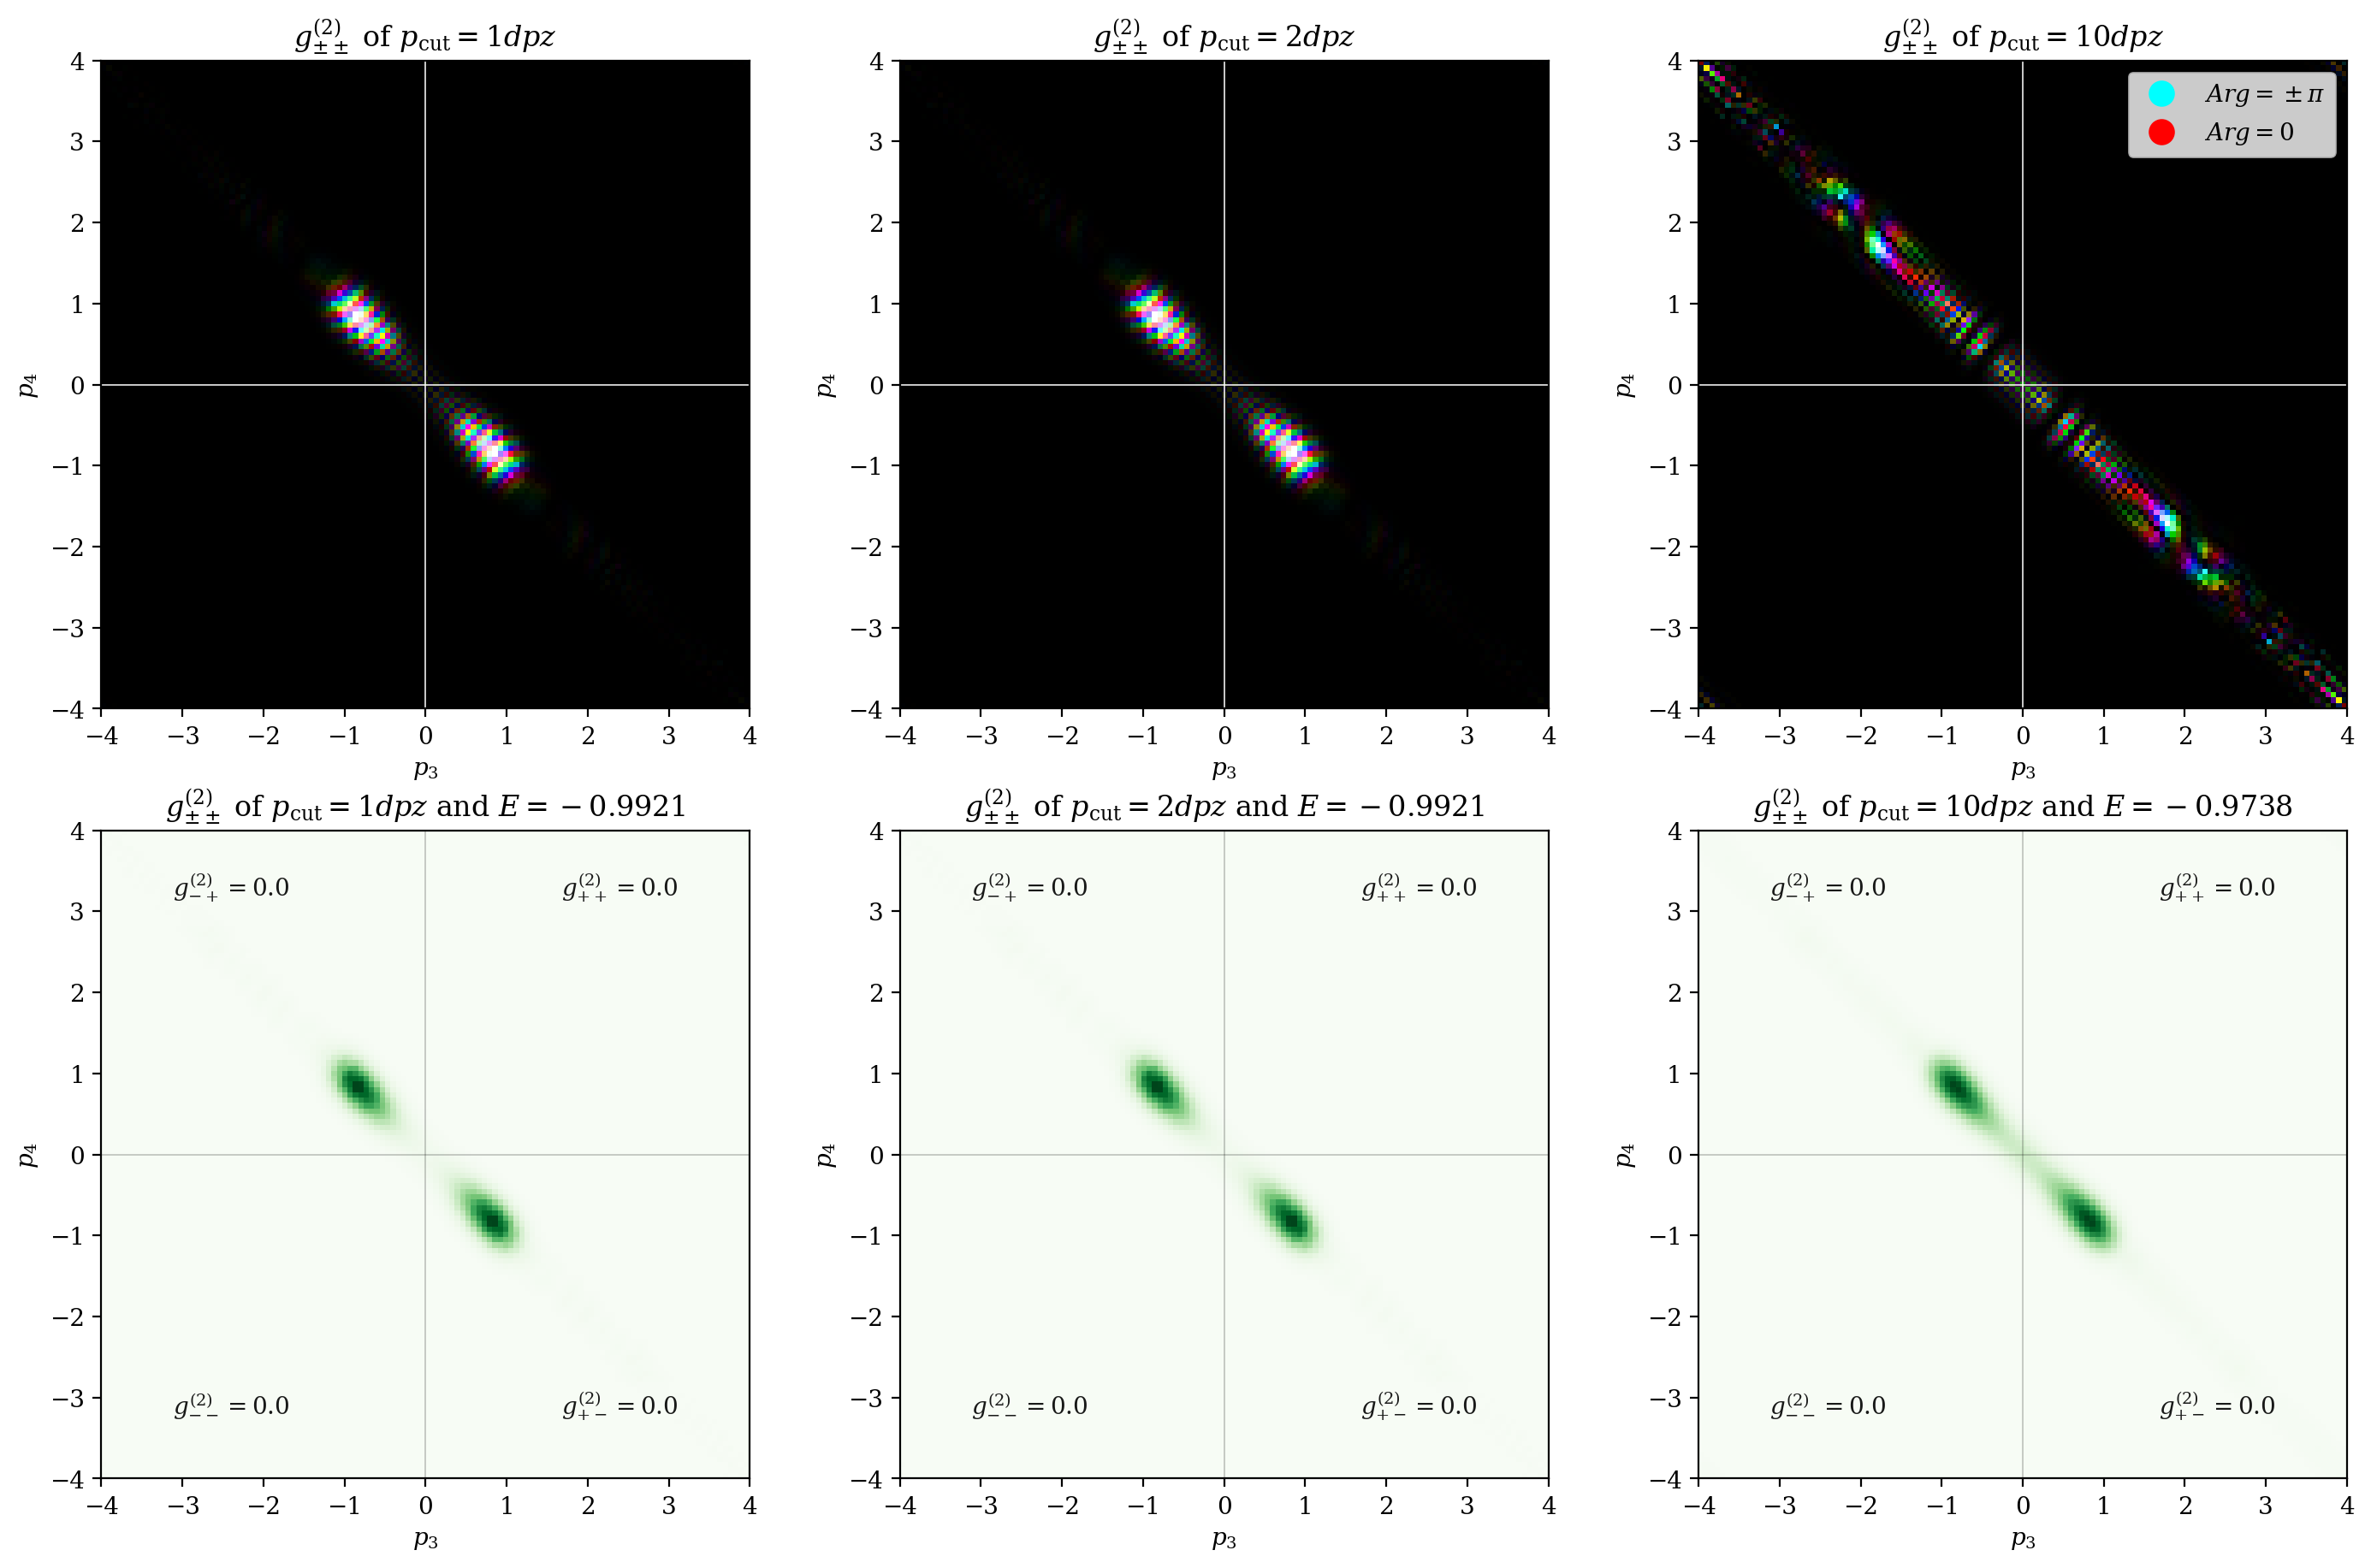

In [110]:
plt.figure(figsize=(14,9))

# cut_list = [1, 10, 30]
cut_list = [1, 2, 10]
for i in range(3):
    cut = cut_list[i]
    gx3x4 = gp3p4_dhalo_calc_noAb(phi,cut=cut,offset3=+p,offset4=+p)
    plt.subplot(2,len(cut_list),i+1)
    gx3x4_img = colorize(gx3x4.T)
    
    # xip = pxlin > +0*cut*dpz 
    # xim = pxlin < -0*cut*dpz 
    # gpp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xip],pxlin[xip],axis=0)
    # gpm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xip],pxlin[xip],axis=0)
    # gmp = np.trapz(np.trapz(gx3x4[:,xip],pxlin[xip],axis=1)[xim],pxlin[xim],axis=0)
    # gmm = np.trapz(np.trapz(gx3x4[:,xim],pxlin[xim],axis=1)[xim],pxlin[xim],axis=0)
    # ECHSH = (gpp+gmm-gpm-gmp)/((gpp+gmm+gpm+gmp))
    
    plt.imshow(gx3x4_img, extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k))
#     ax.imshow(np.flipud(gx3x4_img.T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k))
#     plt.title("$g^{(2)}_{\pm\pm}$ of $p_\mathrm{cut} = "+str(cut)+"dpz$ and $E="+str(round(E,4))+"$")
    plt.title("$g^{(2)}_{\pm\pm}$ of $p_\mathrm{cut} = "+str(cut)+"dpz$")
    plt.xlabel("$p_3$")
    plt.ylabel("$p_4$")
    plt.axhline(y=0,color='white',alpha=0.8,linewidth=0.7)
    plt.axvline(x=0,color='white',alpha=0.8,linewidth=0.7)
#     plt.text(+pxmax*0.6/(hb*k),+pxmax*0.8/(hb*k),"$g^{(2)}_{++}="+str(round(gpp,4))+"$", color='white',ha='center',alpha=0.9)
#     plt.text(-pxmax*0.6/(hb*k),+pxmax*0.8/(hb*k),"$g^{(2)}_{-+}="+str(round(gmp,4))+"$", color='white',ha='center',alpha=0.9)
#     plt.text(+pxmax*0.6/(hb*k),-pxmax*0.8/(hb*k),"$g^{(2)}_{+-}="+str(round(gpm,4))+"$", color='white',ha='center',alpha=0.9)
#     plt.text(-pxmax*0.6/(hb*k),-pxmax*0.8/(hb*k),"$g^{(2)}_{--}="+str(round(gmm,4))+"$", color='white',ha='center',alpha=0.9)
    # plt.colorbar()
plt.legend(handles=legend_elements, loc='upper right')    

for i in range(3):
    cut = cut_list[i]
    gx3x4, gx3x4config = gp3p4_dhalo_calc(phi,cut=cut,offset3=+p,offset4=+p)
    # gx3x4 = gp3p4_dhalo_calc_noAb(phi,cut=cut,offset3=+p,offset4=+p)
    plt.subplot(2,len(cut_list),i+1+3)
    plot_dhalo_gp3p4(gx3x4,cut)
    # plt.colorbar()

# plt.colorbar()
    
plt.tight_layout(pad=0)
title = "double halo corr with phase"
plt.savefig(output_prefix+title+f" t={round(t,5)}"+".pdf", dpi=600)
plt.savefig(output_prefix+title+f" t={round(t,5)}"+".png", dpi=600)

plt.show()

In [92]:
((np.abs(gx3x4)**2).max())

2.2073610880731254e-16

In [93]:
((np.abs(gx3x4)**2).min())

9.720618993070498e-80

In [95]:
gx3x4[0].shape

(121,)

In [379]:
t=1.2052
# t=0.5657
# t=0.6347
# t=0.03
# t = 0.5
# data_folder = "20240512-005555-TFF" 
data_folder = "20240911-182427-TFF"#"20240711-234819-TFF" #"20240528-224811-TFF"
# settingStr = "1-0"
settingStr = "6-5"
psi, phi = None, None
gc.collect()
# with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl', 'rb', thread=8) as file:
with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)} s={settingStr}.pgz.pkl', 'rb', thread=8) as file:
    psi = pickle.load(file)
phi, swnf = phiAndSWNF(psi, nthreads=7)
gc.collect()

0

In [411]:
psi, phi = None, None

t = 1.2052 		 frame = -2 		 memory used: 11114.611MB  


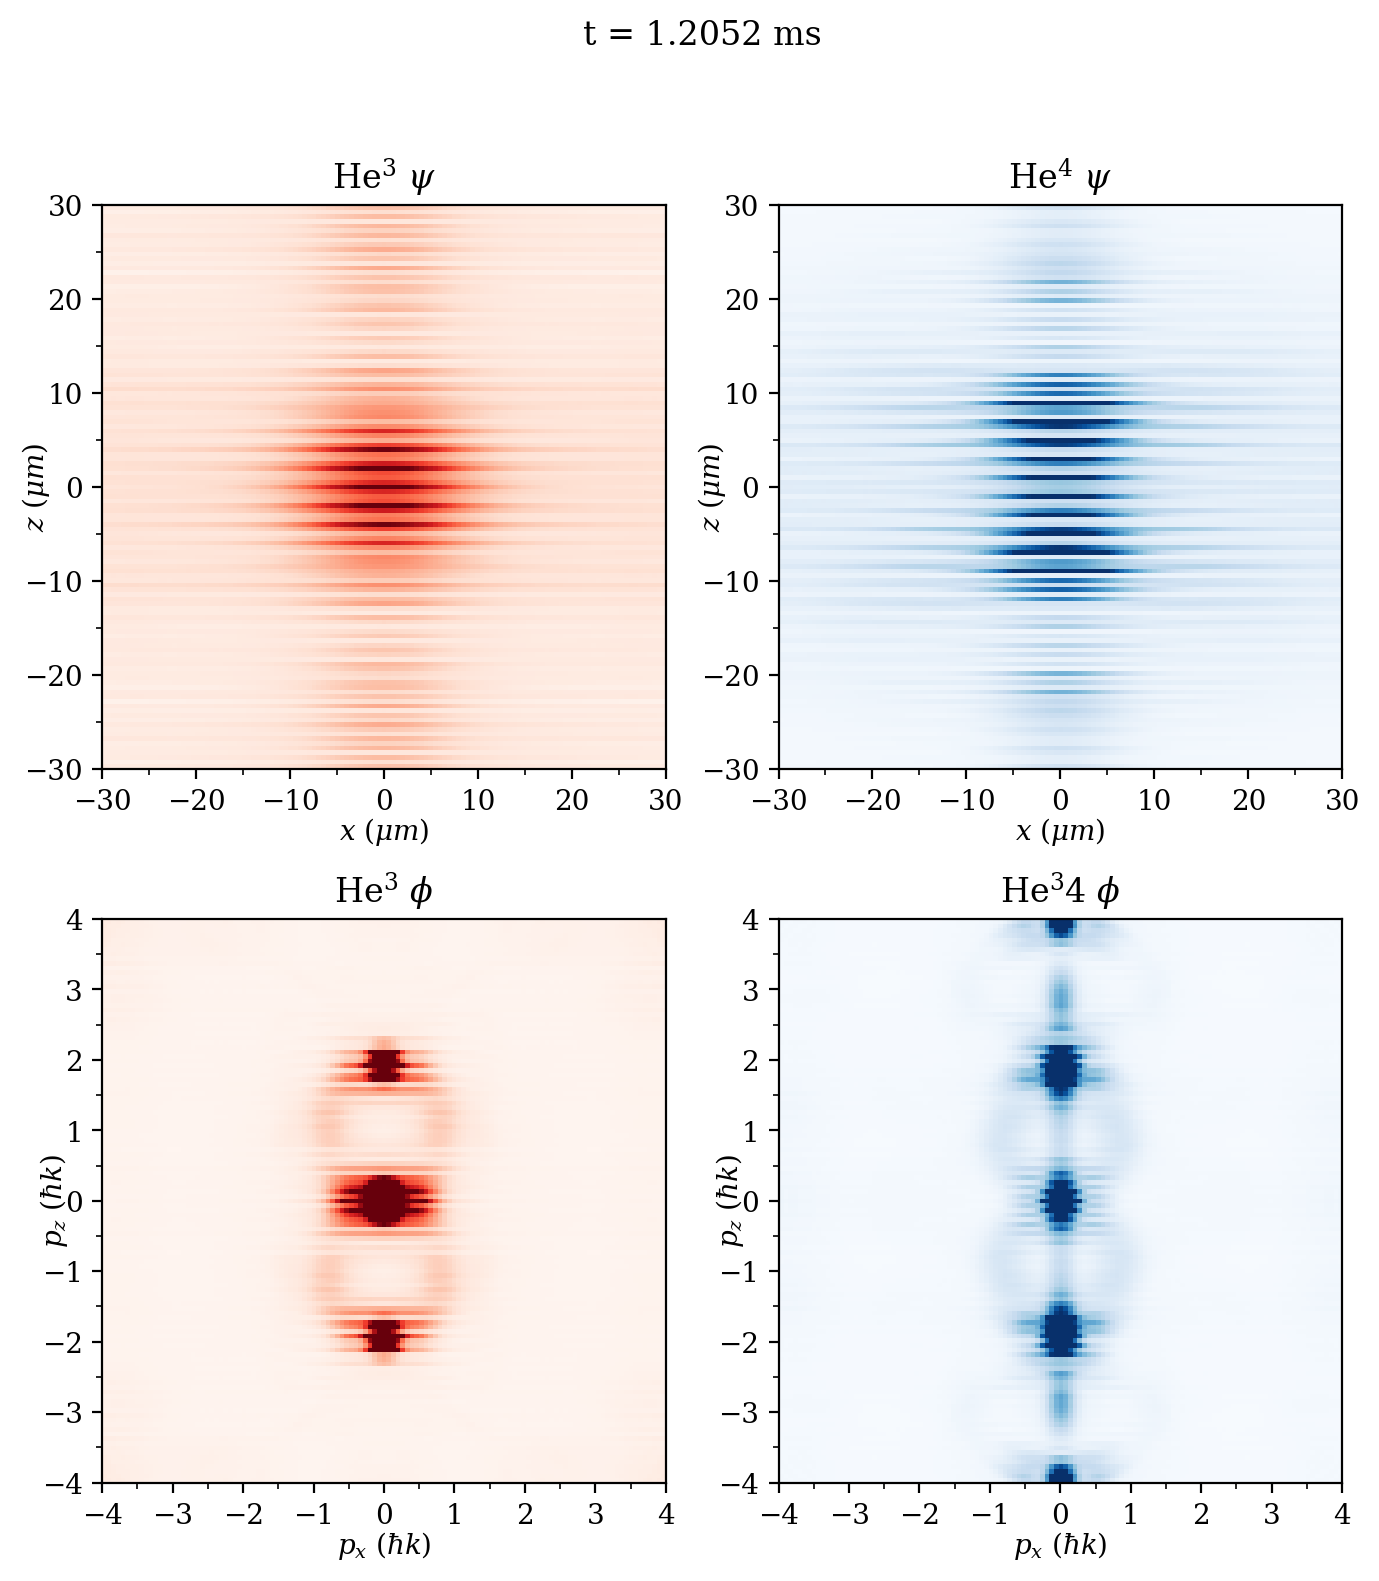

In [127]:
psi_phi_plot1(t,-2,psi,phi, plt_show=True, plt_save=True, 
              cmax3x=2e-3,
              cmax4x=2e-3,
              cmax3p=2e-5,
              cmax4p=2e-5,
              xxlima=-xmax,xxlimb=+xmax,xylima=-zmax,xylimb=+zmax,
              pxlima=-pxmax/(hb*k),pxlimb=+pxmax/(hb*k),pzlima=-pzmax/(hb*k),pzlimb=+pzmax/(hb*k),
              xxTmaj=10,xxTmin=5,xyTmaj=10,xyTmin=5,
                pxTmaj=1,pxTmin=0.5,pzTmaj=1,pzTmin=0.5
              )

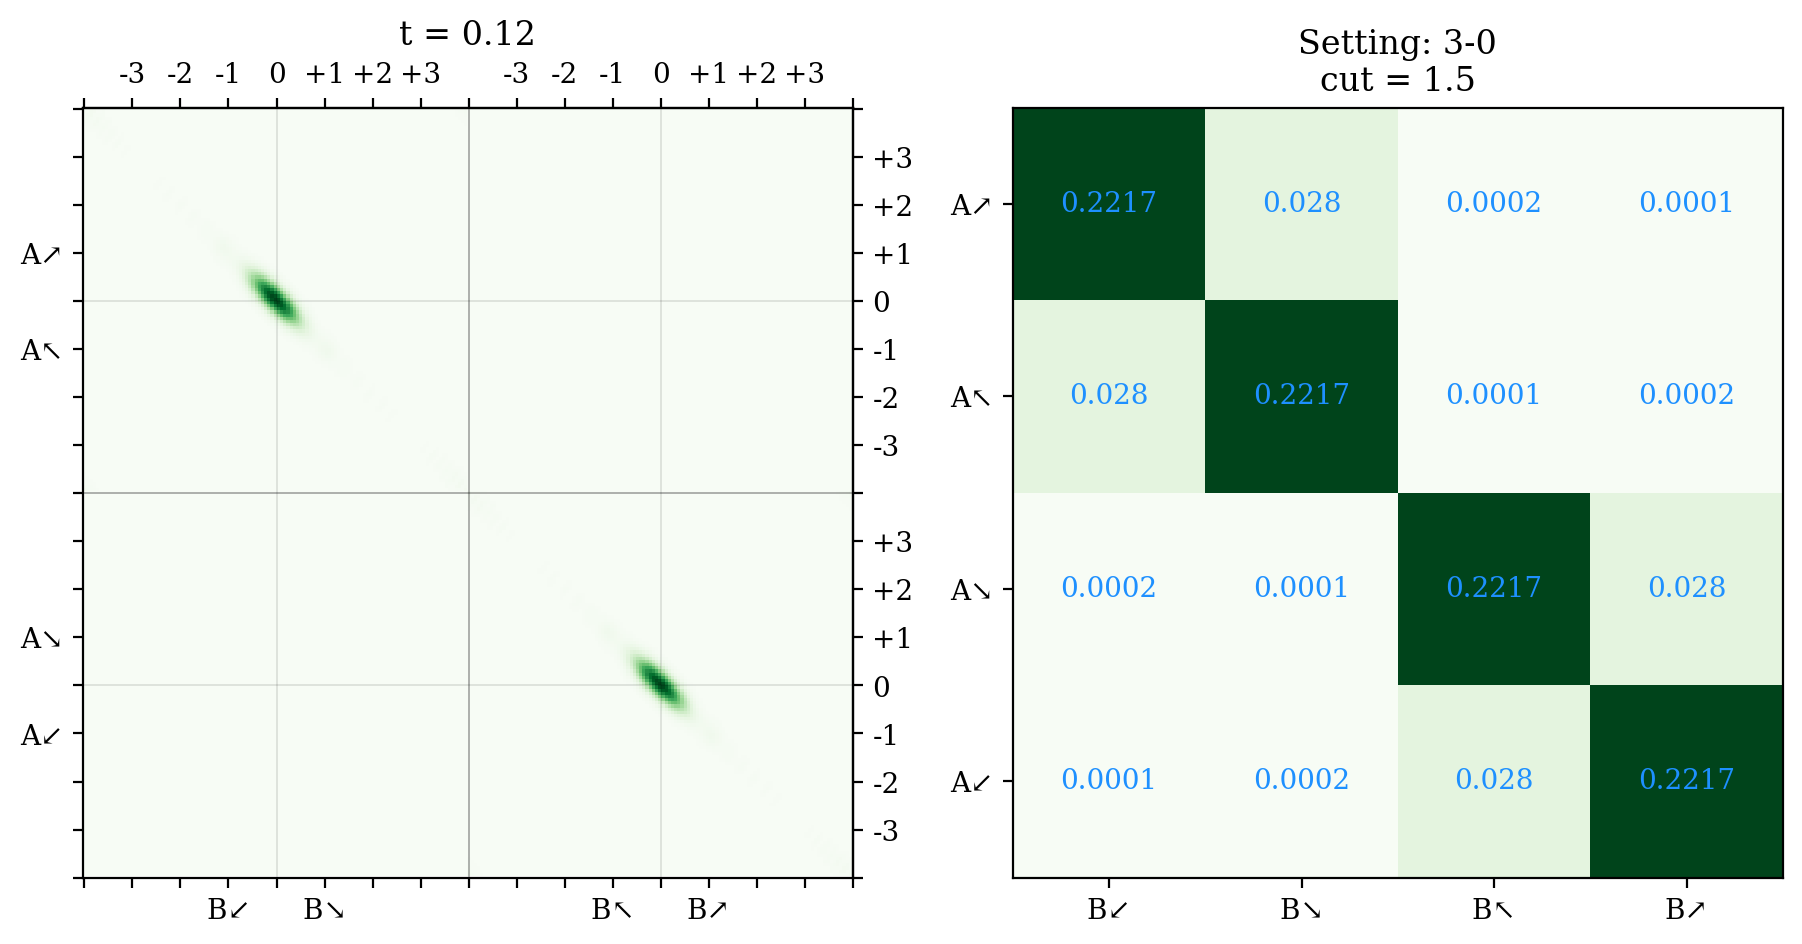

In [103]:
whatever_bla_testing2 = plot_g34(phi, cutPlot=1.5, saveFig=True, 
        title2=f"Setting: 3-0",
        title2filestr="s3-0", skipPlot=False
        )

In [174]:
# t=1.2052
# t = 0.15
t = 0.15
data_folder = "20240919-173152-TFF"
# settingStr = "2-7"
# settingStr = selected_sett[0]
psi, phi = None, None
gc.collect()
with pgzip.open(f'./output/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl', 'rb', thread=8) as file:
# with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)} s={settingStr}.pgz.pkl', 'rb', thread=8) as file:
    psi = pickle.load(file)
phi, swnf = phiAndSWNF(psi, nthreads=7)
gc.collect()

7

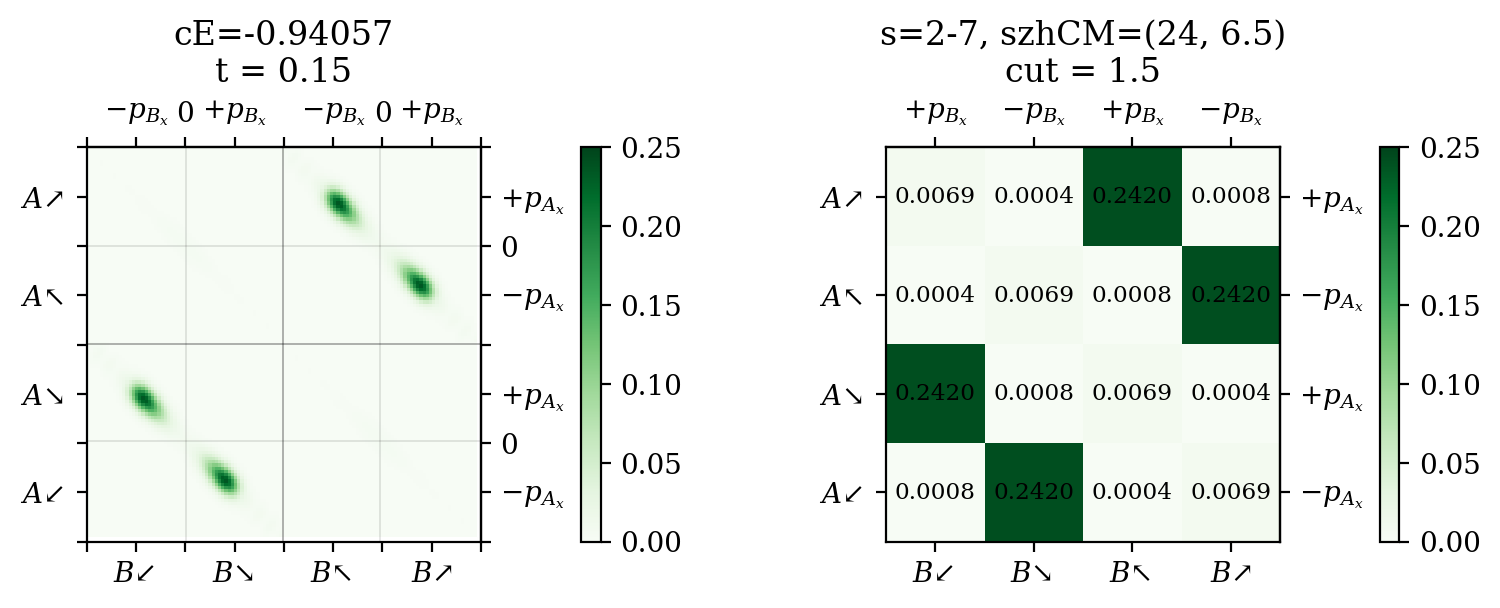

In [211]:
# figSizeHere = (10.5,4.0)
figSizeHereCM = (24,6.5)
figSizeHere = (figSizeHereCM[0]/2.54, figSizeHereCM[1]/2.54)
figSizeHere = (round(figSizeHere[0],4), round(figSizeHere[1],4))
whatever_bla_testing2v2 = plot_g34_v2(phi, cutPlot=1.5, saveFig=True, 
        pMaxCut=2,
        title2=f"s={settingStr}, szhCM={figSizeHereCM}",
        title2filestr=f"{settingStr}, fshCM={figSizeHereCM}", skipPlot=False,
        figSize=figSizeHere
        )
del figSizeHere, figSizeHereCM

In [104]:
p

49.87890948141247

In [192]:
whatever_bla_testing2v2[4][0,3]-whatever_bla_testing2v2[4][0,1]+\
whatever_bla_testing2v2[4][1,2]-whatever_bla_testing2v2[4][1,0]+\
whatever_bla_testing2v2[4][2,1]-whatever_bla_testing2v2[4][2,3]+\
whatever_bla_testing2v2[4][3,0]-whatever_bla_testing2v2[4][3,2]

0.5078490492189837

In [177]:
whatever_bla_testing2v2[4]

array([[0.00042054, 0.06071309, 0.00119101, 0.18767536],
       [0.06071309, 0.00042054, 0.18767536, 0.00119101],
       [0.00119101, 0.18767536, 0.00042054, 0.06071309],
       [0.18767536, 0.00119101, 0.06071309, 0.00042054]])

In [185]:
whatever_bla_testing2v2[4][1,2]

0.18767535528182192

In [187]:
(whatever_bla_testing2v2[4][0,3],whatever_bla_testing2v2[4][0,1]
,whatever_bla_testing2v2[4][1,2],whatever_bla_testing2v2[4][1,0]
,whatever_bla_testing2v2[4][2,1],whatever_bla_testing2v2[4][2,3]
,whatever_bla_testing2v2[4][3,0],whatever_bla_testing2v2[4][3,2])

(0.18767535528182663,
 0.06071309297708798,
 0.18767535528182192,
 0.060713092977086526,
 0.18767535528183926,
 0.06071309297708279,
 0.18767535528183446,
 0.06071309297708129)

In [193]:
corrE

NameError: name 'corrE' is not defined

In [85]:
pxmax/dpx

60.00000000000001

In [86]:
nx

121

In [87]:
nc

NameError: name 'nc' is not defined

In [83]:
# 2024 Aug 31 Fig




In [98]:
psi, phi = None, None
gc.collect()

490

### CorrE Visualisation (🈶)

In [ ]:
assert False, "just to catch run all"

In [230]:
comboSettSet

[[((0, 1), (1502.235391440187, 0.0665)),
  ((0, 1), (4506.706174320561, 0.0665)),
  ((12017.883131521496, 0.0498), (1502.235391440187, 0.0665)),
  ((12017.883131521496, 0.0498), (4506.706174320561, 0.0665))],
 [((6008.941565760748, 0.0499), (9013.412348641123, 0.0664)),
  ((6008.941565760748, 0.0499), (0, 1)),
  ((2002.9805219202494, 0.0499), (9013.412348641123, 0.0664)),
  ((2002.9805219202494, 0.0499), (0, 1))],
 [((10014.902609601248, 0.0498), (6008.941565760748, 0.0664)),
  ((10014.902609601248, 0.0498), (9013.412348641123, 0.0664)),
  ((6008.941565760748, 0.0499), (6008.941565760748, 0.0664)),
  ((6008.941565760748, 0.0499), (9013.412348641123, 0.0664))],
 [((12017.883131521496, 0.0498), (4506.706174320561, 0.0665)),
  ((12017.883131521496, 0.0498), (7511.176957200935, 0.0664)),
  ((8011.922087680998, 0.0498), (4506.706174320561, 0.0665)),
  ((8011.922087680998, 0.0498), (7511.176957200935, 0.0664))]]

In [95]:
# t=0.15
# t=0.2657
# t=0.2957
# t=0.3257
# t=0.3347
# t=0.5657
# t=0.5857
# t=0.6057
# t=0.6257
t=1.2052
# data_folder = "20240521-231755-TFF"
data_folder="20240528-224811-TFF"
(vv3, tt3), (vv4, tt4) = comboSettSet[0][0] 
settingStr = f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}"
l.info(f"Loading t={round(t,5)}  s={settingStr}")
# with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)} s={settingStr}.pgz.pkl'
#                 , 'rb', thread=8) as file:
#     psi = pickle.load(file)
# phi, swnf = phiAndSWNF(psi, nthreads=7)
# plot_g34(phi, cutPlot=1.5, saveFig=False, 
#          title2=f"$\phi_3$={round(vv3/VR/0.02)}π/4, $\phi_4=${round(vv4/VR/0.02)}π/4",
#          title2filestr=settingStr
#         )

Loading t=1.2052  s=0-1


In [96]:
# assert False, "just to catch run all"


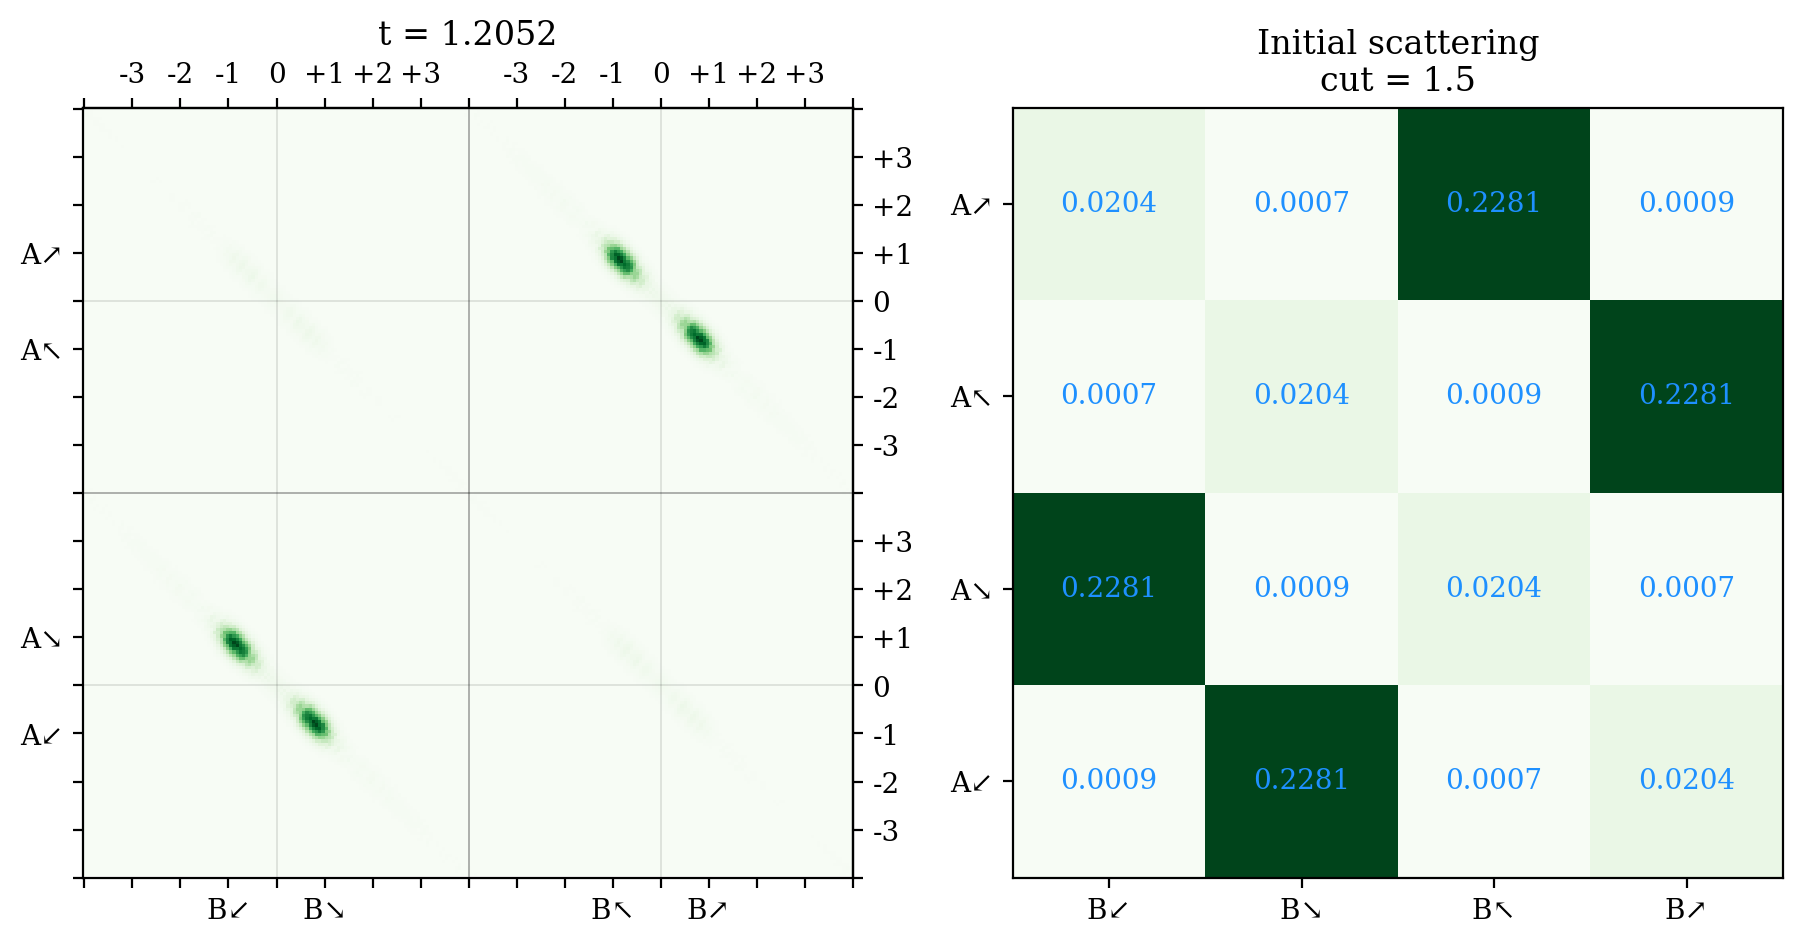

In [97]:
whatever_bla_testing1 = plot_g34(phi, cutPlot=1.5, saveFig=True, 
        title2=f"Initial scattering",
        title2filestr="NA", skipPlot=False
        )

In [70]:
psi_phi_plot1(t,-1,psi,phi, plt_show=True, plt_save=True)

NameError: name 'psi_phi_plot1' is not defined

In [213]:
psi=None
phi=None

In [82]:
# find all psi at t=1.2052
def extract_pgzpkl_t(filename):
    # match = re.search(r's=(\d+-\d+)', filename)
    # match = re.search(r's=(\d+-\dD?\d*+)', filename)
    match = re.search(r's=(\d+-\d+(D\d*)?)', filename)
    # return float(match.group(1)) if match else None
    if match: # Remove any non-numeric characters after the number
        # print(match)
        return match.group(1)
    return None

In [83]:
psi_pgzpkl_list = glob.glob(output_prefix+"*t=1.2052*.pgz.pkl")
psi_pgzpkl_list.sort(key=extract_pgzpkl_t)
psi_pgzpkl_ss_l = [extract_pgzpkl_t(x) for x in psi_pgzpkl_list]

In [83]:
psi_pgzpkl_list

[]

In [490]:
extract_pgzpkl_t(psi_pgzpkl_list[20])

'1-1D8'

In [491]:
psi_pgzpkl_list[:3]

['output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-0.pgz.pkl',
 'output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-1.pgz.pkl',
 'output/twoParticleSim/20240919-173152-TFF/psi at t=1.2052 s=0-11D8.pgz.pkl']

In [492]:
psi_pgzpkl_ss_l[:3]

['0-0', '0-1', '0-11D8']

In [78]:
t=1.2052
outputOfSett = {}
data_folder = "20240919-173152-TFF"#"20240906-124041-TFF" #"20240711-234819-TFF" #"20240528-224811-TFF"
# for combSetH in comboSettSet:
#     for tCombo in combSetH:
# for psi_pgzpkl in psi_pgzpkl_list:
for settingStr in psi_pgzpkl_ss_l:
    # (vv3, tt3), (vv4, tt4) = tCombo
    # settingStr = f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}"
    l.info(f"Loading {data_folder} \t t={round(t,5)}  s={settingStr}")
    # del psi, phi, swnf
    # if 'psi' in locals():   del psi
    # if 'phi' in locals():   del phi
    psi, phi = None, None
    # s3 = float(settingStr.split("-")[0])
    # s4 = float(settingStr.split("-")[1])
    if 'D' in settingStr:
        dd = float(settingStr.split("D")[1])
        s3 = float(settingStr.split("D")[0].split("-")[0])
        s4 = float(settingStr.split("D")[0].split("-")[1])
    else:
        s3 = float(settingStr.split("-")[0])
        s4 = float(settingStr.split("-")[1])
        dd = 4 
    thispklfile = f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)} s={settingStr}.pgz.pkl'
    thisPhiCorrFile = output_prefix+f"phi-corr-stats s={settingStr}"+output_ext
    if not os.path.exists(thispklfile): 
        print("AHHHHHHH")
        break
    if os.path.exists(thisPhiCorrFile): 
        with pgzip.open(thisPhiCorrFile,'rb', thread=8) as file:
            tempPlotOutput = pickle.load(file)
            l.info(f"  loaded corrE({settingStr}) = {corrE(np.flipud(tempPlotOutput[4].T))}")
        outputOfSett[settingStr] = tempPlotOutput
        continue

    with pgzip.open(thispklfile, 'rb', thread=8) as file:
        psi = pickle.load(file)
    phi, swnf = phiAndSWNF(psi, nthreads=7)
    
    # (gx3px4p, gx3px4m, gx3mx4p, gx3mx4m, gx3x4n) 
    scattering_evolve_loop_plot(t,settingStr,psi,phi, plt_show=False, plt_save=True)
    gc.collect()
    scattering_evolve_loop_plot_alt(t,settingStr,psi,phi, plt_show=False, plt_save=True, logPlus=1, po=0.1)
    gc.collect()
    psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True,save_str=f"s={settingStr}",title_str=f"s={settingStr}",
                    cmax3x=2e-3,cmax4x=2e-3,cmax3p=2e-5,cmax4p=2e-5)
    # tempPlotOutput = plot_g34(
    gc.collect()
    psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True,save_str=f"s={settingStr}",title_str=f"s={settingStr}",
                    cmax3x=5e-3,cmax4x=5e-3,cmax3p=5e-5,cmax4p=5e-5)
    gc.collect()
    psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True,save_str=f"s={settingStr}",title_str=f"s={settingStr}",
                    cmax3x=1e-3,cmax4x=1e-3,cmax3p=1e-5,cmax4p=1e-5)
    gc.collect()
    tempPlotOutput = plot_g34_v2(
        phi, cutPlot=1.5, saveFig=True, 
        pMaxCut=2,
        title2=f"$\phi_3$={s3}π/4, $\phi_4=${s4}π/4",
        title2filestr=settingStr, skipPlot=True
        )
    # l.info(tempPlotOutput)
    with pgzip.open(thisPhiCorrFile,'wb', thread=8, blocksize=1*10**8) as file:
        pickle.dump(tempPlotOutput, file)

    outputOfSett[settingStr] = tempPlotOutput
    # del psi, phi, swnf
    l.info(f"  calced corrE({settingStr}) = {corrE(np.flipud(tempPlotOutput[4].T))}")
    gc.collect()
with pgzip.open(output_prefix+f"outputOfSett"+output_ext,'wb', thread=8, blocksize=1*10**8) as file:
    pickle.dump(outputOfSett, file)

NameError: name 'psi_pgzpkl_ss_l' is not defined

In [ ]:
with pgzip.open("/Volumes/tonyNVME Gold/twoParticleSim/20240711-234819-TFF/outputOfSett.pgz.pkl", 'rb', thread=1) as file:
    outputOfSett = pickle.load(file)

In [85]:
with pgzip.open("./output/twoParticleSim/20240919-173152-TFF/outputOfSett.pgz.pkl", 'rb', thread=1) as file:
    outputOfSett = pickle.load(file)

In [84]:
# phi_corrE_list = glob.glob(output_prefix+"phi-corr-stats*")
phi_corrE_list = glob.glob("./output/twoParticleSim/20240919-173152-TFF/"+"phi-corr-stats*")
phi_corrE_list.sort(key=extract_pgzpkl_t)
phi_corrE_ss_l = [extract_pgzpkl_t(x) for x in phi_corrE_list]

In [87]:
selected_sett = ["2-7","2-1","0-7","0-1"]
corrE_3p4 = []
corrE_3m4 = []
corrE_3a4 = [] 
corrE_val = []
corrE_3p4s = []
corrE_3m4s = []
corrE_3a4s = []
corrE_vals = []  
for (pcI, pcE) in enumerate(phi_corrE_list):
    sss = extract_pgzpkl_t(pcE)
    if 'D' in sss:
        dd = float(sss.split("D")[1])
        s3 = float(sss.split("D")[0].split("-")[0])
        s4 = float(sss.split("D")[0].split("-")[1])
    else:
        s3 = float(sss.split("-")[0])
        s4 = float(sss.split("-")[1])
        dd = 4 

    # print(sss,s3,s4, dd)
    # continue
    with pgzip.open(pcE,'rb', thread=2) as file:
        tempPlotOutput = pickle.load(file)
    cE = corrE(np.flipud(tempPlotOutput[4].T))
    print(f"corrE({sss}) = {cE}")

    if sss in selected_sett:
        corrE_3p4s.append((s3+s4)*pi/dd)
        corrE_vals.append(cE)
        corrE_3m4s.append((s3-s4)*pi/dd)
        corrE_3a4s.append((s3,s4))
    else:
        corrE_3p4.append((s3+s4)*pi/dd)
        corrE_val.append(cE)
        corrE_3m4.append((s3-s4)*pi/dd)
        corrE_3a4.append((s3,s4))


corrE_3p4 = np.array(corrE_3p4)
corrE_3m4 = np.array(corrE_3m4)
corrE_3a4 = np.array(corrE_3a4)
corrE_val = np.array(corrE_val)
corrE_3p4s = np.array(corrE_3p4s)
corrE_vals = np.array(corrE_vals)
corrE_3m4s = np.array(corrE_3m4s)
corrE_3a4s = np.array(corrE_3a4s)


corrE(0-0) = 0.8880875455320086
corrE(0-1) = 0.7293684840932898
corrE(0-11D8) = -0.4501587906923501
corrE(0-13D8) = 0.20830343684545846
corrE(0-15D8) = 0.744658564711308
corrE(0-1D8) = 0.8800574073000016
corrE(0-2) = 0.15489980101978898
corrE(0-3) = -0.47572979031120016
corrE(0-3D8) = 0.48266817100358844
corrE(0-4) = -0.8645666484685115
corrE(0-5) = -0.7028167674085488
corrE(0-5D8) = -0.1944776432586346
corrE(0-6) = -0.13018413204913104
corrE(0-7) = 0.5147590582859592
corrE(0-7D8) = -0.7463399013690686
corrE(0-8) = 0.8659105735488983
corrE(0-9D8) = -0.8488040670365176
corrE(1-0) = 0.7062065022235003
corrE(1-0D8) = 0.8703246767339692
corrE(1-1) = 0.15060547451473255
corrE(1-1D8) = 0.7316488334024162
corrE(1-2) = -0.47571422421929094
corrE(1-3) = -0.8526152567269557
corrE(1-4) = -0.6902022273189289
corrE(1-5) = -0.11815850396043802
corrE(1-6) = 0.5077095113823976
corrE(1-7) = 0.8632926956477444
corrE(1-8) = 0.7198607520407696
corrE(16-11D8) = -0.4677361104277102
corrE(16-13D8) = 0.180805

In [712]:
float(sss.split("-")[0])

8.0

In [713]:
corrE_3p4s

array([0.78539816, 5.49778714, 2.35619449, 7.06858347])

a = 0.8649139744870314 ± 0.003993922398432576
o = 0.1674688964648424 ± 0.004765429650431838
h = 0.0039990335597420825 ± 0.002872443822200576


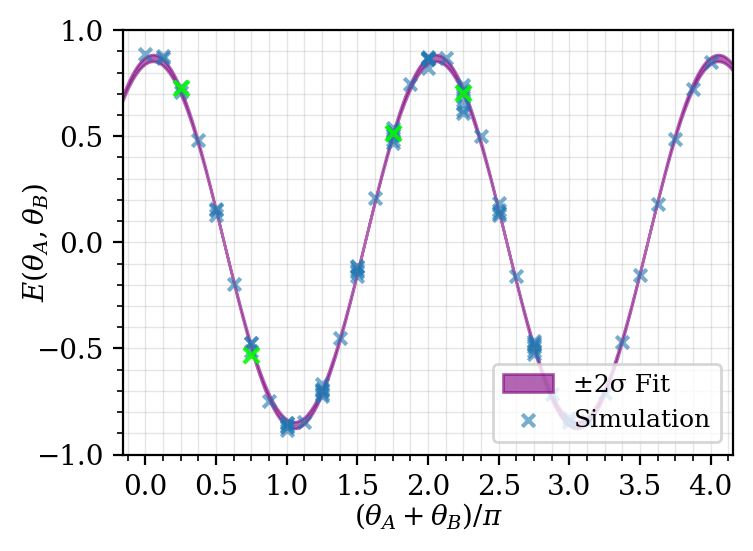

In [129]:
from tkinter import font


def cosM(x, a, o, h):
    return a*np.cos(x-o)+h
par, cov = scipy.optimize.curve_fit(cosM, corrE_3p4, corrE_val)
par_sig = np.sqrt(np.diag(cov))
xxx = np.linspace(min(corrE_3p4)-1,max(corrE_3p4)+1,1000)
xxe = np.linspace(min(corrE_3p4)-10,max(corrE_3p4)+10,3000)
yyy = cosM(xxx, *par)
yys = 2 * par_sig[0] * np.cos(xxx-par[1])
yyd = np.sqrt(np.sum(par_sig**2))

figsize = (10,7)
plt.figure(figsize=(figsize[0]/2.54, figsize[1]/2.54))
# plt.fill_between(xxe, -1, -1/sqrt(2), color='gray', alpha=0.2, label="_nolegend_",linewidth=0)
# plt.fill_between(xxe, +1/sqrt(2), +1, color='gray', alpha=0.2, label="_nolegend_",linewidth=0)
# plt.fill_between(xxe, -1, -0.5, color='gray', alpha=0.2, label="_nolegend_")
# plt.fill_between(xxe, +0.5, +1, color='gray', alpha=0.2, label="_nolegend_")

plt.fill_between(xxx, yyy-2*yys, yyy+2*yys, color='purple', alpha=0.6, label="±2σ Fit")
plt.scatter(corrE_3p4,corrE_val,20,marker='x',alpha=0.6, label="Simulation")
plt.scatter(corrE_3p4s,corrE_vals,30,marker='x',alpha=0.9, color="lime", label="_nolegend_")
l.info(f"a = {par[0]} ± {par_sig[0]}")
l.info(f"o = {par[1]} ± {par_sig[1]}")
l.info(f"h = {par[2]} ± {par_sig[2]}")
# plt.xlabel("$(\\varphi_{A} + \\varphi_B)/\\pi$")
# plt.ylabel("$E(\\varphi_{ A},\\varphi_{ B})$")
plt.xlabel("$(\\theta_{A} + \\theta_{B})/\\pi$", labelpad=0,fontsize=10)
plt.ylabel("$E(\\theta_{A},\\theta_{ B})$",labelpad=-5, fontsize=10)
plt.yticks(np.linspace(-1,1,4+1),fontsize=10)
# plt.xticks(np.linspace(0,2*2*pi,8+1), [str(int(x*2))+"π/4" for x in np.linspace(0,8,8+1)] )
# plt.xticks(np.linspace(0,2*2*pi,8+1), ["0","$\\pi/2$","$\\pi$","$3\\pi/2$","$2\\pi$","${5\\pi}/{2}$","$3\\pi$","${7\\pi}/{2}$","$4\\pi$"])
# plt.xticks(np.linspace(0,2*2*pi,16+1), ["0","$\\pi/4$", "$\\pi/2$", "$3\\pi/4$", "$\\pi$", "$5\\pi/4$", "$3\\pi/2$", "$7\\pi/4$", "$2\\pi$", "$9\\pi/4$", "$5\\pi/2$", "$11\\pi/4$", "$3\\pi$", "$13\\pi/4$", "$7\\pi/2$", "$15\\pi/4$", "$4\\pi$"])
# plt.xticks(np.linspace(0,2*2*pi,16+1),np.linspace(0,4,16+1))
plt.xticks(np.linspace(0,2*2*pi,8+1),np.linspace(0,4,8+1),fontsize=10)
plt.gca().xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(pi/8))
plt.gca().yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
plt.xlim(0-0.5,2*2*pi+0.5)
plt.ylim(-1,+1)
plt.grid(which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.2)
# plt.text(4*pi-0.8,-0.81,"Non-local")
# plt.text(4*pi-0.8,-0.67,"Local")
# plt.text(4*pi-0.8,-0.61,"Non-local")  # this one
# plt.text(4*pi-0.8,-0.46,"Local")      # this one
# plt.text(4*pi-0.7,+0.38,"Non-local")
# plt.text(4*pi-0.7,+0.55,"Local")
plt.legend(loc='lower right',fontsize=9)

plt.savefig(output_prefix+f"corrE-3p4-v3b fS={figsize}cm.pdf", dpi=600, bbox_inches='tight')
plt.savefig(output_prefix+f"corrE-3p4-v3b fS={figsize}cm.png", dpi=600, bbox_inches='tight')
plt.show()

In [305]:
["0","$\\frac{\\pi}{2}$","$\\pi$","$\\frac{3\\pi}{2}$","$2\\pi$","$\\frac{5\\pi}{2}$","$3\\pi$","$\\frac{7\\pi}{2}$","$4\\pi$"] 

['0',
 '$\\frac{\\pi}{2}$',
 '$\\pi$',
 '$\\frac{3\\pi}{2}$',
 '$2\\pi$',
 '$\\frac{5\\pi}{2}$',
 '$3\\pi$',
 '$\\frac{7\\pi}{2}$',
 '$4\\pi$']

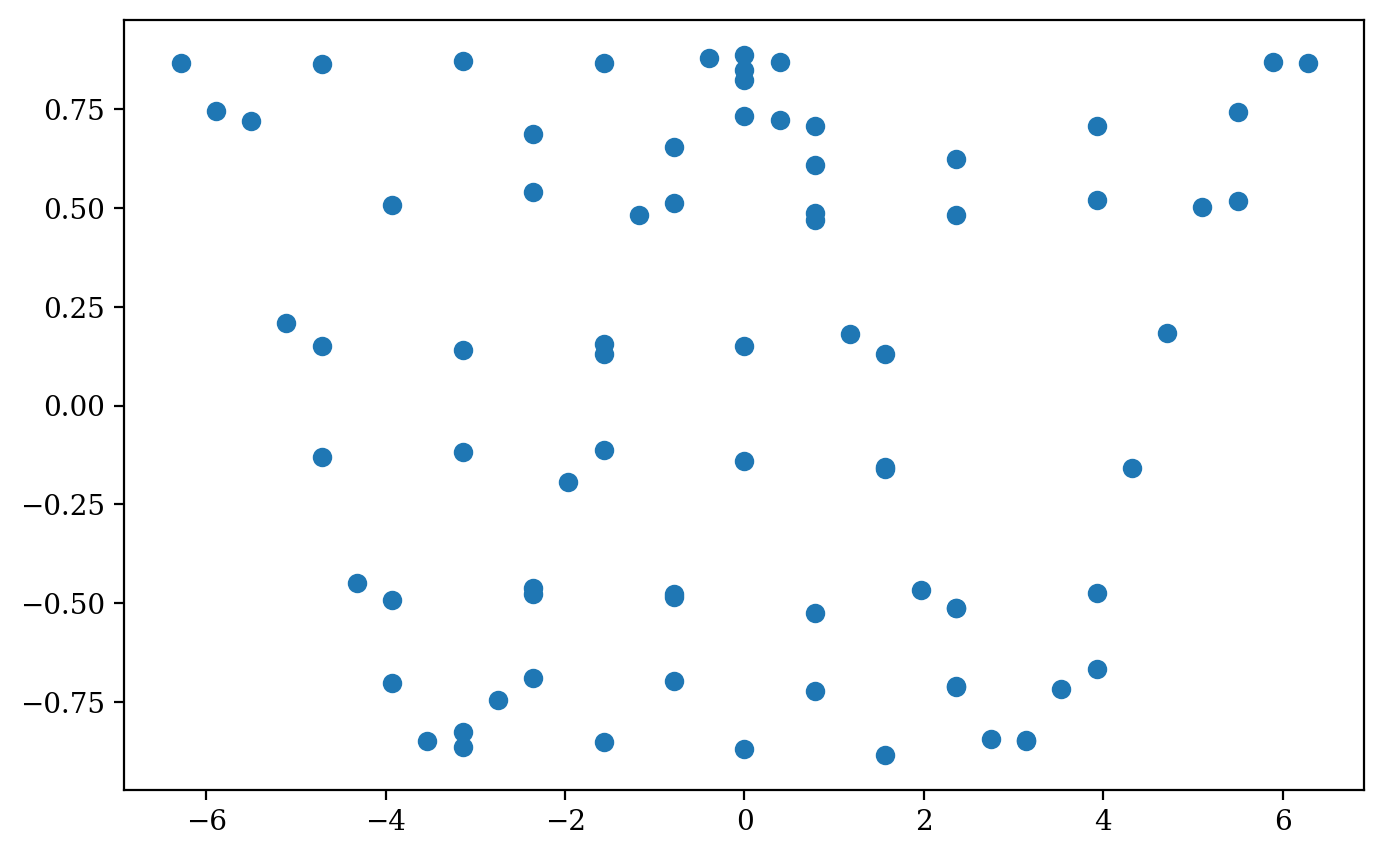

In [484]:
plt.scatter(corrE_3m4, corrE_val)

In [215]:
outputOfSett["0-1"][0][0].shape

(121, 121)

In [216]:
outputOfSett["0-1"][4]

array([[0.00063649, 0.21485993, 0.00087982, 0.03362376],
       [0.21485993, 0.00063649, 0.03362376, 0.00087982],
       [0.00087982, 0.03362376, 0.00063649, 0.21485993],
       [0.03362376, 0.00087982, 0.21485993, 0.00063649]])

In [217]:
outputOfSett["0-1"][4].T

array([[0.00063649, 0.21485993, 0.00087982, 0.03362376],
       [0.21485993, 0.00063649, 0.03362376, 0.00087982],
       [0.00087982, 0.03362376, 0.00063649, 0.21485993],
       [0.03362376, 0.00087982, 0.21485993, 0.00063649]])

In [218]:
np.flipud(outputOfSett["0-1"][4].T)

array([[0.03362376, 0.00087982, 0.21485993, 0.00063649],
       [0.00087982, 0.03362376, 0.00063649, 0.21485993],
       [0.21485993, 0.00063649, 0.03362376, 0.00087982],
       [0.00063649, 0.21485993, 0.00087982, 0.03362376]])

In [128]:
gx3px4p

NameError: name 'gx3px4p' is not defined

In [86]:
def corrE(g):
    return (g[0,2]+g[2,0]-g[0,0]-g[2,2])/(g[0,2]+g[2,0]+g[0,0]+g[2,2])

In [221]:
corrE(np.flipud(outputOfSett["0-1"][4].T))

0.7293684840932898

In [222]:
1/sqrt(2)

0.7071067811865475

In [223]:
 corrE(np.flipud(outputOfSett["0-1"][4].T))\
+corrE(np.flipud(outputOfSett["6-3"][4].T))\
+corrE(np.flipud(outputOfSett["6-1"][4].T))\
-corrE(np.flipud(outputOfSett["0-3"][4].T))

2.3490548986811537

In [224]:
 corrE(np.flipud(outputOfSett["3-6"][4].T))\
+corrE(np.flipud(outputOfSett["1-0"][4].T))\
+corrE(np.flipud(outputOfSett["1-6"][4].T))\
-corrE(np.flipud(outputOfSett["3-0"][4].T))

2.41158369328701

In [225]:
 corrE(np.flipud(outputOfSett["5-4"][4].T))\
+corrE(np.flipud(outputOfSett["3-6"][4].T))\
+corrE(np.flipud(outputOfSett["3-4"][4].T))\
-corrE(np.flipud(outputOfSett["5-6"][4].T))

2.290372693301188

In [495]:
 corrE(np.flipud(outputOfSett["6-3"][4].T))\
+corrE(np.flipud(outputOfSett["4-5"][4].T))\
+corrE(np.flipud(outputOfSett["4-3"][4].T))\
-corrE(np.flipud(outputOfSett["6-5"][4].T))

2.272887321646815

In [227]:
2*sqrt(2)

2.8284271247461903

In [142]:
corrE(np.flipud(outputOfSett["6-1"][4].T))

0.5192874276896465

In [143]:
corrE(np.flipud(outputOfSett["6-3"][4].T))

0.6246691965870169

In [144]:
corrE(np.flipud(outputOfSett["0-3"][4].T))

-0.47572979031120016

In [147]:
np.flipud(outputOfSett["0-3"][4].T)

array([[0.18309105, 0.0013876 , 0.06504523, 0.00047612],
       [0.0013876 , 0.18309105, 0.00047612, 0.06504523],
       [0.06504523, 0.00047612, 0.18309105, 0.0013876 ],
       [0.00047612, 0.06504523, 0.0013876 , 0.18309105]])

In [506]:
(corrE(np.flipud(outputOfSett["0-1"][4].T))\
,corrE(np.flipud(outputOfSett["0-3"][4].T))\
,corrE(np.flipud(outputOfSett["1-0"][4].T))\
,corrE(np.flipud(outputOfSett["0-1"][4].T)))

(0.7293684840932898,
 -0.47572979031120016,
 0.7062065022235003,
 0.7293684840932898)

In [205]:
cEResults = {}
for (ci, combSetH) in enumerate(comboSettSet):
    (tC1, tC2, tC3, tC4) = combSetH
    (v31,_), (v41,_) = tC1 
    (v32,_), (v42,_) = tC2
    (v33,_), (v43,_) = tC3
    (v34,_), (v44,_) = tC4
    ss1 = f"{round(v31/VR/0.02)}-{round(v41/VR/0.015)}"
    ss2 = f"{round(v32/VR/0.02)}-{round(v42/VR/0.015)}"
    ss3 = f"{round(v33/VR/0.02)}-{round(v43/VR/0.015)}"
    ss4 = f"{round(v34/VR/0.02)}-{round(v44/VR/0.015)}"
        # (vv3, tt3), (vv4, tt4) = tCombo
        # settingStr = f"{round(vv3/VR/0.02)}-{round(vv4/VR/0.015)}"
        # print(settingStr)
    cE = corrE(np.flipud(outputOfSett[ss1][4].T))\
        -corrE(np.flipud(outputOfSett[ss2][4].T))\
        +corrE(np.flipud(outputOfSett[ss3][4].T))\
        +corrE(np.flipud(outputOfSett[ss4][4].T))
    
    print(f"ci={ci}, g({ss1})-g({ss2})+g({ss3})+g({ss4}) \t cE = {round(cE,5)}")
    print(f"    {round(corrE(np.flipud(outputOfSett[ss1][4].T)),4)}"+\
          f"    {round(corrE(np.flipud(outputOfSett[ss2][4].T)),4)}"+\
          f"    {round(corrE(np.flipud(outputOfSett[ss3][4].T)),4)}"+\
          f"    {round(corrE(np.flipud(outputOfSett[ss4][4].T)),4)}")

ci=0, g(0-1)-g(0-3)+g(6-1)+g(6-3) 	 cE = 2.34905
    0.7294    -0.4757    0.5193    0.6247
ci=1, g(3-6)-g(3-0)+g(1-6)+g(1-0) 	 cE = 2.41158
    0.6865    -0.5111    0.5077    0.7062
ci=2, g(5-4)-g(5-6)+g(3-4)+g(3-6) 	 cE = 2.29037
    0.6077    -0.4846    0.5116    0.6865
ci=3, g(6-3)-g(6-5)+g(4-3)+g(4-5) 	 cE = 2.27289
    0.6247    -0.5255    0.469    0.6537
ci=4, g(1-0)-g(1-2)+g(7-0)+g(7-2) 	 cE = 2.40783
    0.7062    -0.4757    0.5187    0.7072
ci=5, g(2-7)-g(2-1)+g(0-7)+g(0-1) 	 cE = 2.47796
    0.7048    -0.529    0.5148    0.7294
ci=6, g(4-5)-g(4-7)+g(2-5)+g(2-7) 	 cE = 2.36168
    0.6537    -0.4628    0.5403    0.7048
ci=7, g(7-2)-g(7-4)+g(5-2)+g(5-4) 	 cE = 2.30876
    0.7072    -0.5124    0.4814    0.6077
ci=8, g(1-0)-g(1-6)+g(3-0)+g(3-6) 	 cE = 0.37388
    0.7062    0.5077    -0.5111    0.6865
ci=9, g(6-3)-g(6-1)+g(0-3)+g(0-1) 	 cE = 0.35902
    0.6247    0.5193    -0.4757    0.7294
ci=10, g(4-5)-g(4-3)+g(6-5)+g(6-3) 	 cE = 0.28379
    0.6537    0.469    -0.5255    0.6247
c

In [106]:
comboSettSet[5]

[((4005.961043840499, 0.0499), (10515.64774008131, 0.0664)),
 ((4005.961043840499, 0.0499), (1502.235391440187, 0.0665)),
 ((0, 1), (10515.64774008131, 0.0664)),
 ((0, 1), (1502.235391440187, 0.0665))]

In [110]:
comboSettSet[5][0]

((4005.961043840499, 0.0499), (10515.64774008131, 0.0664))

In [111]:
4005/VR/0.02

1.9995201931172164

In [113]:
comboSettingsGen(thetaCombo5)

[((2002.9805219202494, 0.0499), (0, 1)),
 ((2002.9805219202494, 0.0499), (3004.470782880374, 0.0665)),
 ((14020.863653441747, 0.0498), (0, 1)),
 ((14020.863653441747, 0.0498), (3004.470782880374, 0.0665))]

In [121]:
gc.collect()

2120639

#### CorrE alt - not good?

In [ ]:
assert False, "just to catch run all"

In [ ]:
1/sqrt(2)

In [ ]:
sideP = sqrt((3*m3-m4)/(m3+m4))*hb*k
l.info(f"sideP = {sideP}")

In [ ]:
cutPlot=1
gx3px4p = gp3p4_dhaloUD_calc(phi,cut=cutPlot,offset3=+sideP,offset4=+sideP)
gx3px4m = gp3p4_dhaloUD_calc(phi,cut=cutPlot,offset3=+sideP,offset4=-sideP)
gx3mx4p = gp3p4_dhaloUD_calc(phi,cut=cutPlot,offset3=-sideP,offset4=+sideP)
gx3mx4m = gp3p4_dhaloUD_calc(phi,cut=cutPlot,offset3=-sideP,offset4=-sideP)
gx3x4combined = np.zeros((2*nx,2*nx))
gx3x4combined[:nx, :nx] = gx3px4p[0]
gx3x4combined[:nx, nx:] = gx3px4m[0]
gx3x4combined[nx:, :nx] = gx3mx4p[0]
gx3x4combined[nx:, nx:] = gx3mx4m[0]

plt.figure(figsize=(11,5))
ax = plt.subplot(1,2,1)
ax.imshow(np.flipud(gx3x4combined.T),cmap="Greens")
ticks = np.linspace(0, 2*nx, 17)
ticksL = np.linspace(0, 2*nx, 9)
tick_labels = ["","+3","+2","+1","0","-1","-2","-3","","+3","+2","+1","0","-1","-2","-3",""]
ax.set_yticks(ticks, ["","","","A↖︎","","A↙︎","","","","","","A↗︎","","A↘︎","","",""]) # ↗︎↘︎↖︎↙︎
ax.set_xticks(ticks, ["","","","B↘︎","","B↗︎","","","","","","B↙︎","","B↖︎","","",""]) # ↗︎↘︎↖︎↙︎

ax.axhline(y=1.0*nx,color='k',alpha=0.3,linewidth=0.7)
ax.axhline(y=0.5*nx,color='k',alpha=0.1,linewidth=0.7)
ax.axhline(y=1.5*nx,color='k',alpha=0.1,linewidth=0.7)
ax.axvline(x=1.0*nx,color='k',alpha=0.3,linewidth=0.7)
ax.axvline(x=0.5*nx,color='k',alpha=0.1,linewidth=0.7)
ax.axvline(x=1.5*nx,color='k',alpha=0.1,linewidth=0.7)
ax2 = ax.secondary_xaxis('top')
ax3 = ax.secondary_yaxis('right')
ax2.set_xticks(ticks, tick_labels[::-1])
ax3.set_yticks(ticks, tick_labels)
plt.title(f"t = {t}")

l.info(f"""gx3px4p[1] = {gx3px4p[1]}
gx3px4m[1] = {gx3px4m[1]}
gx3mx4p[1] = {gx3mx4p[1]}
gx3mx4m[1] = {gx3mx4m[1]}""")

gx3x4combined = np.zeros((2*2,2*2))
gx3x4combined[:2, :2] = [[gx3px4p[1][3],gx3px4p[1][2]],[gx3px4p[1][1],gx3px4p[1][0]]]
gx3x4combined[:2, 2:] = [[gx3px4m[1][3],gx3px4m[1][2]],[gx3px4m[1][1],gx3px4m[1][0]]]
gx3x4combined[2:, :2] = [[gx3mx4p[1][3],gx3mx4p[1][2]],[gx3mx4p[1][1],gx3mx4p[1][0]]]
gx3x4combined[2:, 2:] = [[gx3mx4m[1][3],gx3mx4m[1][2]],[gx3mx4m[1][1],gx3mx4m[1][0]]]
gx3x4n = gx3x4combined/sum(sum(gx3x4combined))
ax = plt.subplot(1,2,2)
im = ax.imshow(np.flipud(gx3x4combined.T),cmap='Greens')
ticks=np.arange(0,4,1)
ax.set_yticks(ticks, ["A↖︎","A↙︎","A↗︎","A↘︎"])
ax.set_xticks(ticks, ["B↘︎","B↗︎","B↙︎","B↖︎"])
# ax2 = ax.secondary_xaxis('top')
# ax3 = ax.secondary_yaxis('right')
# ax2.set_yticks(ticks, ["A↗︎","A↖︎","A↘︎","A↙︎"])
# ax3.set_xticks(ticks, ["B↙︎","B↘︎","B↖︎","B↗"])
for i in range(gx3x4n.shape[0]):
    for j in range(gx3x4n.shape[1]):
        plt.text(j, i, str(round(np.flipud(gx3x4n.T)[i, j],4)), ha='center', va='center', color='dodgerblue')
plt.title(f"cut = {cutPlot}")
title = f"CorrE alt t={round(t,5)}, cut = {cutPlot}"
plt.savefig(output_prefix+title+".pdf", dpi=600)
plt.savefig(output_prefix+title+".png", dpi=600)
plt.show()

In [ ]:
scattering_evolve_loop_plot(t,f,psi,phi, plt_show=True, plt_save=False)

In [ ]:
scattering_evolve_loop_plot_alt(t,f,psi,phi, plt_show=True, plt_save=False, logPlus=1, po=0.1)

# Exporting to Video (Quite high VM RAM usage)

In [ ]:
assert False, "just to catch run all"

In [391]:
# Function to extract frame number from filename
def extract_frame_number(filename):
    match = re.search(r't=([0-9.]+)', filename)
    # return float(match.group(1)) if match else None
    if match: # Remove any non-numeric characters after the number
        number = match.group(1).rstrip('.')
        return float(number)
    return None
img_alt_list = glob.glob(output_pre_selp+'*.png')
# img_alt_list = glob.glob(output_pre_selpa+'*.png')
# img_alt_list = glob.glob(output_prefix+'BS_L free time scan ok 3/*.png')
img_alt_list.sort(key=extract_frame_number)

In [392]:
extract_frame_number(img_alt_list[2])

0.5677

In [393]:
img_alt_list[2]

'output/twoParticleSim/20240521-231755-TFF/scattering_evolve_loop_plot/f=2,t=0.5677.png'

In [394]:
N_JOBS

2

In [395]:
# img_alt_frames = []  # Read and process images, storing them in a list
# for image in tqdm(img_alt_list, desc="Processing Images"):
#     img = cv2.imread(image)
#     img_alt_frames.append(img)  # Append processed frame to list
img_alt_frames = Parallel(n_jobs=-1)(
    delayed(lambda image: cv2.imread(image))(image) for image in tqdm(img_alt_list, desc="Processing Images")
)

Processing Images:   0%|          | 0/290 [00:00<?, ?it/s]

In [396]:
if img_alt_frames:  # Determine the width and height from the first image if not empty
    height, width, layers = img_alt_frames[0].shape # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'hvc1')  # HEVC codec
    out = cv2.VideoWriter(
        output_prefix+"scattering_evolve_loop_plot.mov", 
        # output_prefix+"scattering_evolve_loop_plot_alt.mov", 
        # output_prefix+"BS_L free time scan ok 3.mov",
        fourcc, 10.0, (width, height), True) # Write img_alt_frames to the video file
    for frame in tqdm(img_alt_frames, desc="Writing Video"):
        out.write(frame)  # Write out frame to video
    out.release()  # Release the video writer
    del frame, out
else:
    print("No images found or processed.")
del img_alt_frames
gc.collect()

x265 [info]: HEVC encoder version 3.4+31-6722fce1f
x265 [info]: build info [Mac OS X][clang 12.0.5][32 bit][noasm] 8bit+10bit+12bit
x265 [info]: using cpu capabilities: none!
x265 [info]: Main profile, Level-6.1 (High tier)
x265 [info]: Thread pool created using 10 threads
x265 [info]: Slices                              : 1
x265 [info]: frame threads / pool features       : 1 / wpp(66 rows)
x265 [info]: Coding QT: max CU size, min CU size : 64 / 8
x265 [info]: Residual QT: max TU size, max depth : 32 / 1 inter / 1 intra
x265 [info]: ME / range / subpel / merge         : hex / 57 / 2 / 3
x265 [info]: Keyframe min / max / scenecut / bias  : 1 / 12 / 40 / 5.00 
x265 [info]: Lookahead / bframes / badapt        : 20 / 4 / 2
x265 [info]: b-pyramid / weightp / weightb       : 1 / 1 / 0
x265 [info]: References / ref-limit  cu / depth  : 3 / off / on
x265 [info]: AQ: mode / str / qg-size / cu-tree  : 2 / 1.0 / 32 / 1
x265 [info]: Rate Control / qCompress            : ABR-403200 kbps / 0.60
x26

Writing Video:   0%|          | 0/290 [00:00<?, ?it/s]

x265 [info]: frame I:     25, Avg QP:3.00  kb/s: 27958.55
x265 [info]: frame P:     63, Avg QP:3.00  kb/s: 10120.18
x265 [info]: frame B:    202, Avg QP:4.18  kb/s: 5311.26 
x265 [info]: Weighted P-Frames: Y:0.0% UV:0.0%
x265 [info]: consecutive B-frames: 6.8% 17.0% 33.0% 26.1% 17.0% 

encoded 290 frames in 239.73s (1.21 fps), 8308.31 kb/s, Avg QP:3.82


16131

In [397]:
gc.collect()
%reset -f in
%reset -f out
ram_py_log()
print_ram_usage(globals().items(),10)

Flushing input history
Flushing output cache (4 entries)
1794.392MB of system memory used
                           phi:  3.2 GiB
                          phi2:  3.2 GiB
      t_bs_scan_diag_result_np: 428.4 KiB
                 mased_bs_scan: 142.9 KiB
                    psixeqList: 142.9 KiB
                    psiyeqList: 142.9 KiB
                      cosZGrid: 114.5 KiB
                        gridX3: 114.5 KiB
                        gridX4: 114.5 KiB
                    gridFilter: 114.5 KiB


# Making Figures

In [193]:
output_pre_ppp = output_prefix + "psi_phi_plot/"
os.makedirs(output_pre_ppp, exist_ok=True)
def psi_phi_plot1(t,f,psi,phi, 
                  plt_show=True, plt_save=False, 
                  save_str="", title_str="",
                  cmax3x=1,cmax3p=1,cmax4x=1,cmax4p=1,
                  xxlima=-xmax,xxlimb=+xmax,xylima=-zmax,xylimb=+zmax,
                  pxlima=-pxmax/(hb*k),pxlimb=+pxmax/(hb*k),pzlima=-pzmax/(hb*k),pzlimb=+pzmax/(hb*k),
                  xxTmaj=10,xxTmin=5,xyTmaj=10,xyTmin=5,
                  pxTmaj=1,pxTmin=0.5,pzTmaj=1,pzTmin=0.5,
                  cbar=False
                  ):
    t_str = str(round(t,5))
    if plt_show:
        print("t = " +t_str+ " \t\t frame =", f, "\t\t memory used: " + 
              str(round(ram_py_MB(),3)) + "MB  ")
    # normC = matplotlib.colors.Normalize(vmin=0, vmax=cmax)
    # normP = matplotlib.colors.Normalize(vmin=0, vmax=cmaxp)
    fig = plt.figure(figsize=(8,8.5))
    plt.subplot(2,2,1)
    plt.imshow(np.flipud(only3(psi).T), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax3x))
    plt.xlabel("$x \ (\mu m)$", labelpad=0)
    plt.ylabel("$z \ (\mu m)$", labelpad=-10)
    plt.title("He$^3\ \psi$")
    plt.xlim(xxlima,xxlimb)
    plt.ylim(xylima,xylimb)
    # plt.title("$t="+t_str+" \ ms $")
    # add a label to the top left corner
    # plt.text(-xmax*0.95,zmax*0.95,"He$^3\ \psi$",color='k',ha='left',va='top',alpha=0.9)
    plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=xxTmaj))
    plt.gca().xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=xxTmin))
    plt.gca().yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=xyTmaj))
    plt.gca().yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=xyTmin))

    plt.subplot(2,2,2)
    plt.imshow(np.flipud(only4(psi).T), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax4x))
    plt.xlabel("$x \ (\mu m)$", labelpad=0)
    plt.ylabel("$z \ (\mu m)$", labelpad=-10)
    plt.title("He$^4\ \psi$")
    plt.xlim(xxlima,xxlimb)
    plt.ylim(xylima,xylimb)
    # plt.text(-xmax*0.95,zmax*0.95,"He$^4\ \psi$",color='k',ha='left',va='top',alpha=0.9)
    plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=xxTmaj))
    plt.gca().xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=xxTmin))
    plt.gca().yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=xyTmaj))
    plt.gca().yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=xyTmin))

    plt.subplot(2,2,3)
    plt.imshow((only3phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax3p))
    plt.xlabel("$p_x \ (\hbar k)$", labelpad=0)
    plt.ylabel("$p_z \ (\hbar k)$", labelpad=-10)
    plt.title("He$^3\ \phi$")
    plt.xlim(pxlima,pxlimb)
    plt.ylim(pzlima,pzlimb)
    # plt.text(-pxmax*0.95/p,pzmax*0.95/p,"He$^3\ \phi$",color='k',ha='left',va='top',alpha=0.9)
    plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=pxTmaj))
    plt.gca().xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=pxTmin))
    plt.gca().yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=pzTmaj))
    plt.gca().yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=pzTmin))
    # add color bar
    if cbar: plt.colorbar()

    plt.subplot(2,2,4)
    plt.imshow((only4phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax4p))
    plt.xlabel("$p_x \ (\hbar k)$", labelpad=0)
    plt.ylabel("$p_z \ (\hbar k)$", labelpad=-10)
    plt.title("He$^34\ \phi$")
    plt.xlim(pxlima,pxlimb)
    plt.ylim(pzlima,pzlimb)
    # plt.text(-pxmax*0.95/p,pzmax*0.95/p,"He$^4\ \phi$",color='k',ha='left',va='top',alpha=0.9)
    plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=pxTmaj))
    plt.gca().xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=pxTmin))
    plt.gca().yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=pzTmaj))
    plt.gca().yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(base=pzTmin))
    if cbar: plt.colorbar()

    # add suptitle
    if title_str=="": plt.suptitle("t = "+t_str+" ms")
    else: plt.suptitle("t = "+t_str+" ms, "+title_str)

    if plt_save:
        title= "f="+str(f)+",t="+t_str+","+str((cmax3x,cmax3p,cmax4x,cmax4p))+save_str
        plt.savefig(output_pre_ppp+title+".pdf", dpi=600, bbox_inches='tight')
        plt.savefig(output_pre_ppp+title+".png", dpi=600, bbox_inches='tight')
    
    if plt_show: plt.show() 
    else:        plt.close(fig) 
    gc.collect()

t = 0.5 		 frame = -3 		 memory used: 9220.243MB  


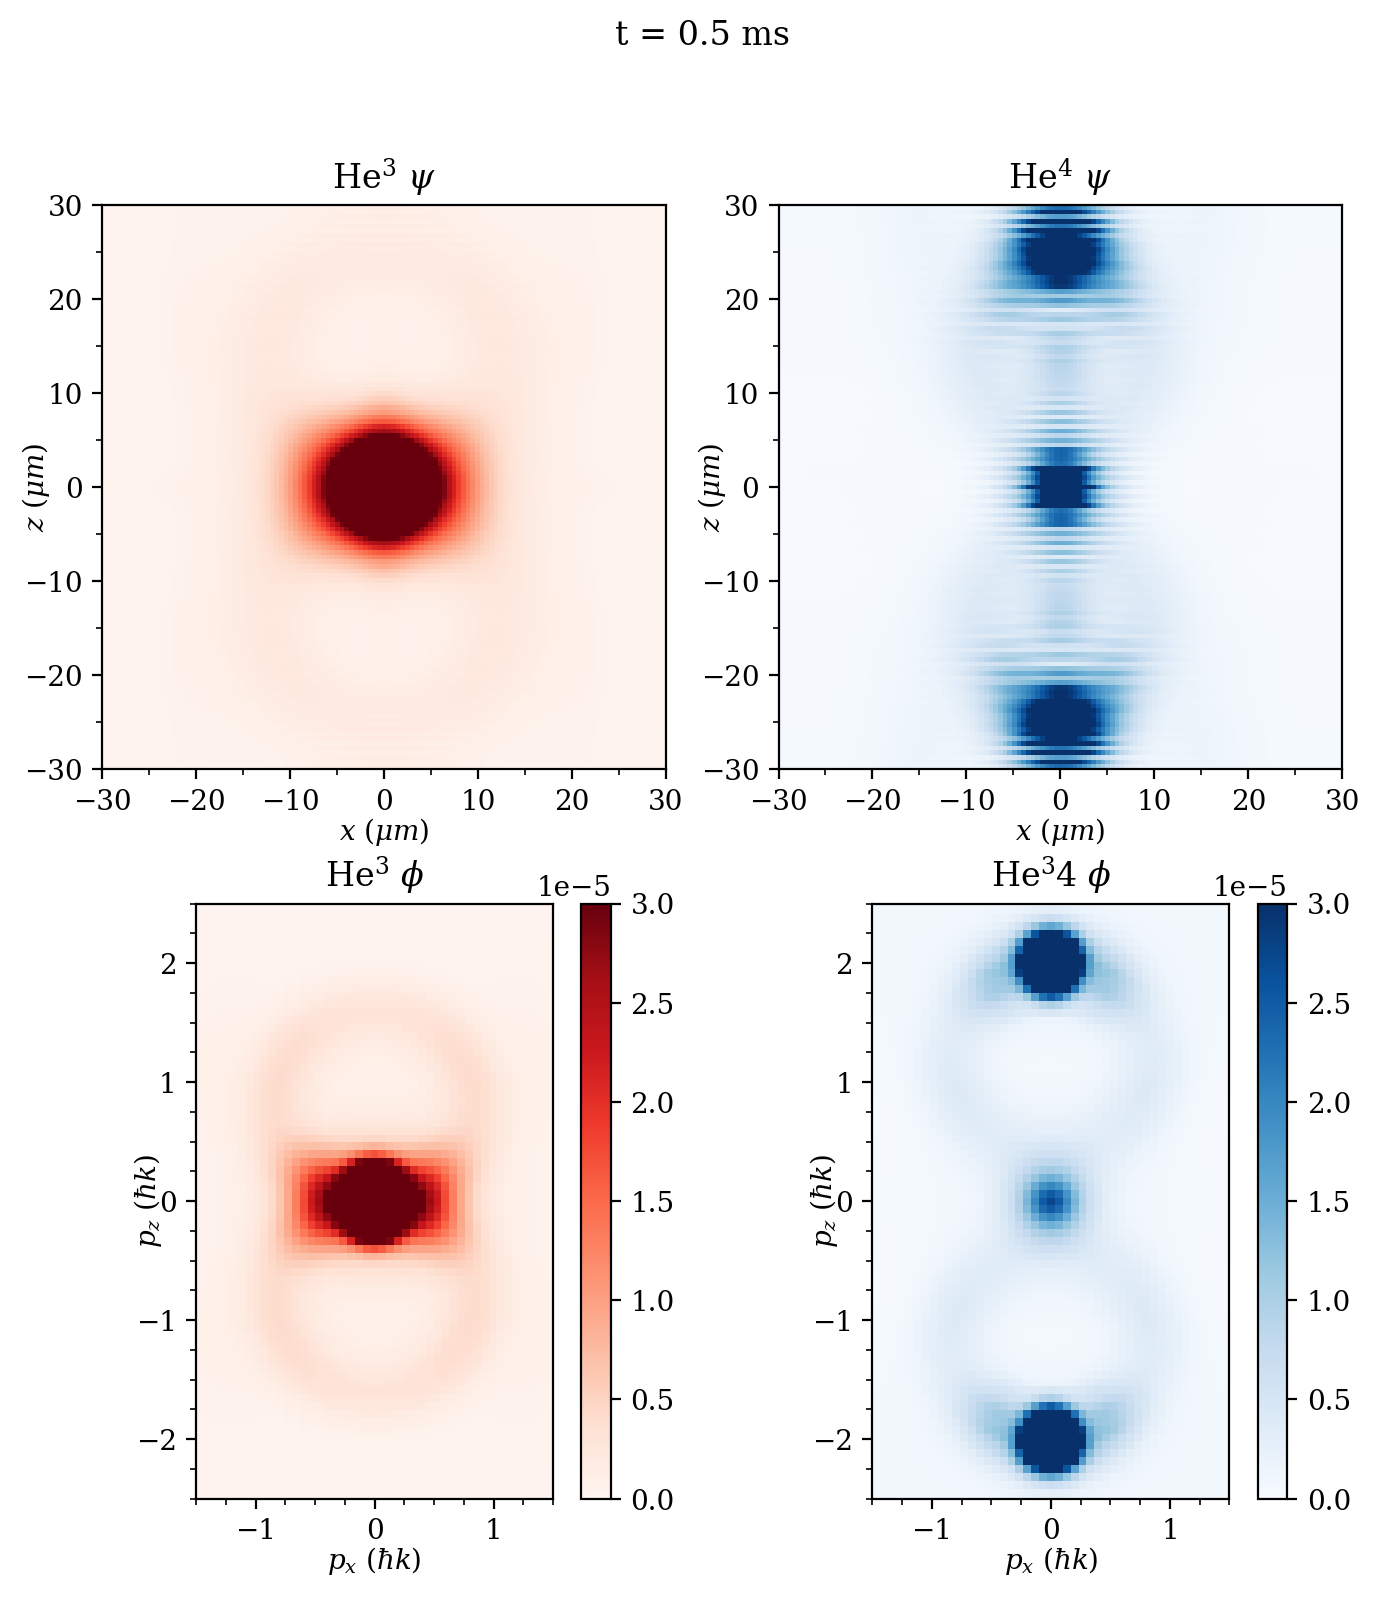

In [161]:
psi_phi_plot1(t,-3,psi,phi, plt_show=True, plt_save=True, 
            cmax3x=2e-3,
            cmax4x=2e-3,
            cmax3p=3e-5,
            cmax4p=3e-5,
            xxlima = -xmax,
            xxlimb = +xmax,
            xylima = -zmax,
            xylimb = +zmax,
            pxlima = -1.5,
            pxlimb = +1.5,
            pzlima = -2.5,
            pzlimb = +2.5,
            xxTmaj = 10,
            xxTmin = 5,
            xyTmaj = 10,
            xyTmin = 5,
            pxTmaj = 1,
            pxTmin = 0.25,
            pzTmaj = 1,
            pzTmin = 0.25,
            cbar=True
              )

t = 0.5 		 frame = -2 		 memory used: 9220.997MB  


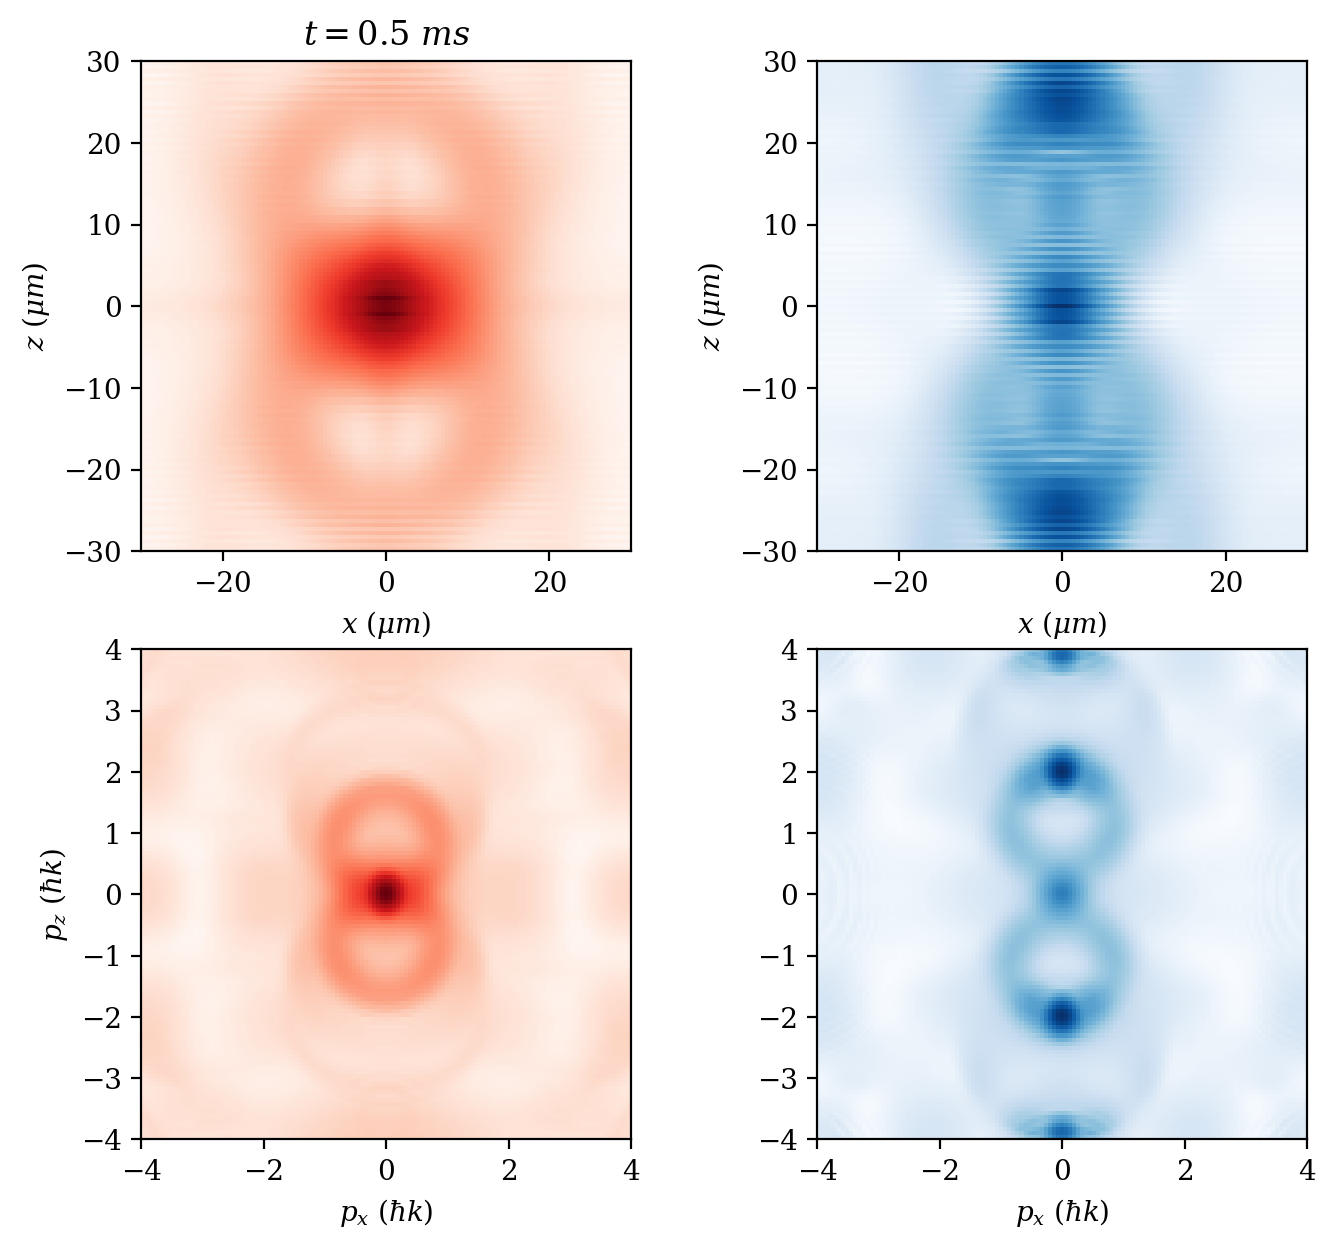

In [163]:
scattering_evolve_loop_plot_alt(t,-2,psi,phi, plt_show=True, plt_save=False, logPlus=1, po=0.1)

In [186]:
1e-20

1e-20

In [59]:
# t=1.2052
# t=0.5657
# t=0.6347
t = 0.15
data_folder = "20240919-173152-TFF"
# data_folder = "20240512-005555-TFF" 
# data_folder = "20240911-182427-TFF"#"20240711-234819-TFF" #"20240528-224811-TFF"
settingStr = "1-0"
# settingStr = "6-5"
psi, phi = None, None
gc.collect()
with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl', 'rb', thread=8) as file:
# with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)} s={settingStr}.pgz.pkl', 'rb', thread=8) as file:
    psi = pickle.load(file)
phi, swnf = phiAndSWNF(psi, nthreads=7)
gc.collect()

0

In [57]:
def fucking_scaling_fuck(x, cutoff, amp, bb=1):
    # if x <= cutoff: return cutoff
    # else: return np.arctan(x-cutoff)/(pi/2)*amp + cutoff
    return np.where(x <= cutoff, x, np.arctan(bb*(x - cutoff) / (np.pi / 2) * amp + cutoff))

finding looplift candidates
finding looplift candidates
0.0004029646425614628 0.0001661340583523337
t = 0.15 		 frame = -7 		 memory used: 10491.15MB  


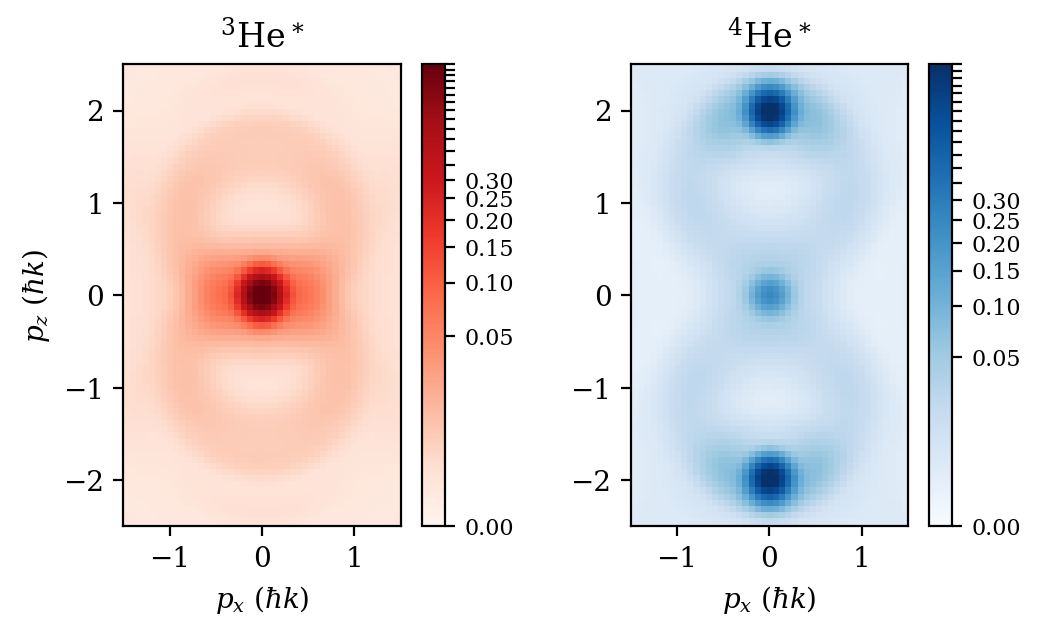

73719

In [181]:
logPlus=1; po=0.4; f=-7
# o3pM = np.max(only3phi(phi))
# o4pM = np.max(only4phi(phi))
print(np.max(only3phi(phi)),np.max(only4phi(phi)))
# o3pM = 0.0003863759165270296
# o4pM = 0.00016002514388641225
o3pM = 0.00032
o4pM = 0.00014
mmm = 1e-6
mm3 = 1
mm4 = 1
lm = 1e5
atm=6e4
cmax3p= 5e-5
cmax4p= 5e-5
camp3 = 0e-5
camp4 = 0e-5
bbb = 1e5
bbc = 1e4

cb3tlins = np.linspace(0,o3pM,20)
cb3ticks = mm3*np.power(np.log(logPlus+bbc*cb3tlins),po)
cb3tlbls = [format(x,'.2f') if i<7 else "" for (i, x) in enumerate(cb3tlins*0.05/(cb3tlins[1]-cb3tlins[0]))]
cb4tlins = np.linspace(0,o4pM,20)
cb4ticks = mm4*np.power(np.log(logPlus+bbc*cb4tlins),po)
cb4tlbls = [format(x,'.2f') if i<7 else "" for (i, x) in enumerate(cb4tlins*0.05/(cb4tlins[1]-cb4tlins[0]))]

t_str = str(round(t,5))
print("t = " +t_str+ " \t\t frame =", f, "\t\t memory used: " + 
        str(round(ram_py_MB(),3)) + "MB  ")

fig = plt.figure(figsize=(6,3))
# plt.subplot(2,2,1)
# plt.imshow(np.power(np.log(logPlus+np.flipud(only3(psi).T)),po), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
# plt.xlabel("$x \ (\mu m)$")
# plt.ylabel("$z \ (\mu m)$")
# plt.title("$t="+t_str+" \ ms $")

# plt.subplot(2,2,2)
# plt.imshow(np.power(np.log(logPlus+np.flipud(only4(psi).T)),po), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
# plt.xlabel("$x \ (\mu m)$")
# plt.ylabel("$z \ (\mu m)$")

plt.subplot(1,2,1)
# plt.imshow(fucking_scaling_fuck(only3phi(phi).T,cmax3p,camp3,bbb), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
# plt.imshow(np.power(np.log(1+lm*only3phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax3p))
# plt.imshow(fucking_scaling_fuck(np.power(np.log(1+lm*only3phi(phi).T),po),cmax3p,camp3), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
# plt.imshow(np.arctan(atm*only3phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
plt.imshow(mm3*np.power(np.log(logPlus+bbc*only3phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=np.max(cb3ticks)))
# plt.imshow(np.power(np.log(logPlus+only3phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax3p))
plt.xlabel("$p_x \ (\hbar k)$")
plt.ylabel("$p_z \ (\hbar k)$")
plt.xlim(-1.5,+1.5)
plt.ylim(-2.5,+2.5)
cbar = plt.colorbar()
cbar.set_ticks(cb3ticks)
cbar.set_ticklabels(cb3tlbls)
cbar.ax.tick_params(labelsize=8)
plt.title("${}^3\\text{He}^\\ast$")

plt.subplot(1,2,2)
# plt.imshow(fucking_scaling_fuck(only4phi(phi).T,cmax4p,camp4,bbb), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
# plt.imshow(np.power(np.log(1+lm*only4phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax4p))
# plt.imshow(fucking_scaling_fuck(np.power(np.log(1+lm*only4phi(phi).T),po),cmax4p,camp4), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
# plt.imshow(np.arctan(atm*only4phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
plt.imshow(mm4*np.power(np.log(logPlus+bbc*only4phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=np.max(cb4ticks)))
# plt.imshow(np.power(np.log(logPlus+only4phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax4p))
plt.xlabel("$p_x \ (\hbar k)$")
plt.xlabel("$p_x \ (\hbar k)$")
plt.xlim(-1.5,+1.5)
plt.ylim(-2.5,+2.5)
cbar = plt.colorbar()
cbar.set_ticks(cb4ticks)
cbar.set_ticklabels(cb4tlbls)
cbar.ax.tick_params(labelsize=8)
plt.title("${}^4\\text{He}^\\ast$")

title= "f="+str(f)+",t="+t_str+",logPlus="+str(logPlus)+f" s={settingStr}"
plt.savefig(output_pre_selpa+title+".pdf", dpi=600, bbox_inches='tight')
plt.savefig(output_pre_selpa+title+".png", dpi=600, bbox_inches='tight')
plt.show()
gc.collect()

0.0004029646425614628 0.0001661340583523337
t = 0.15 		 frame = -7 		 memory used: 7447.757MB  


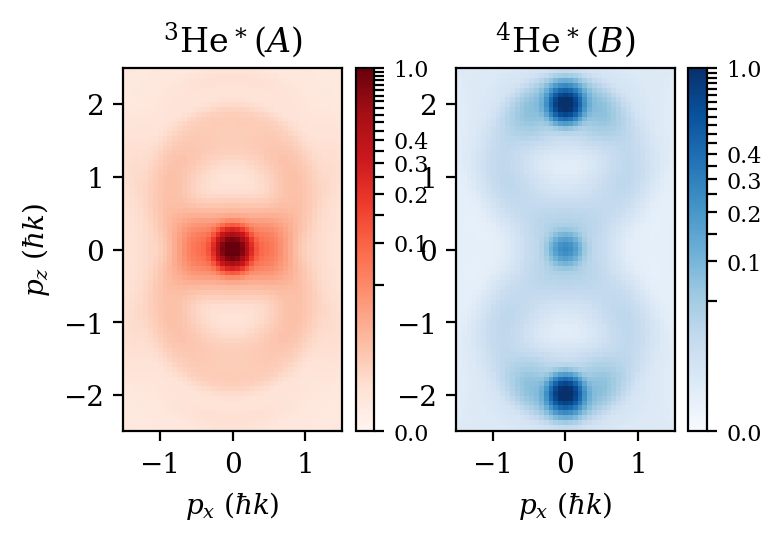

15410

In [199]:
logPlus=1; po=0.4; f=-7
# o3pM = np.max(only3phi(phi))
# o4pM = np.max(only4phi(phi))
print(np.max(only3phi(phi)),np.max(only4phi(phi)))
# o3pM = 0.0003863759165270296
# o4pM = 0.00016002514388641225
o3pM = 0.00032
o4pM = 0.00014
mmm = 1e-6
mm3 = 1
mm4 = 1
lm = 1e5
atm=6e4
cmax3p= 5e-5
cmax4p= 5e-5
camp3 = 0e-5
camp4 = 0e-5
bbb = 1e5
bbc = 1e4

cb3tlins = np.linspace(0,o3pM,20+1)
cb3ticks = mm3*np.power(np.log(logPlus+bbc*cb3tlins),po)
cb3tlbls = [format(x,'.1f') if i%2==0 and (i<9 or i >= 20) else "" for (i, x) in enumerate(cb3tlins*0.05/(cb3tlins[1]-cb3tlins[0]))]
cb4tlins = np.linspace(0,o4pM,20+1)
cb4ticks = mm4*np.power(np.log(logPlus+bbc*cb4tlins),po)
cb4tlbls = [format(x,'.1f') if i%2==0 and (i<9 or i >= 20) else "" for (i, x) in enumerate(cb4tlins*0.05/(cb4tlins[1]-cb4tlins[0]))]

t_str = str(round(t,5))
print("t = " +t_str+ " \t\t frame =", f, "\t\t memory used: " + 
        str(round(ram_py_MB(),3)) + "MB  ")
figsizeHereCM = (10,6)
fig = plt.figure(figsize=(figsizeHereCM[0]/2.54,figsizeHereCM[1]/2.54))
# plt.subplot(2,2,1)
# plt.imshow(np.power(np.log(logPlus+np.flipud(only3(psi).T)),po), extent=[-xmax,xmax,-zmax, zmax],cmap='Reds')
# plt.xlabel("$x \ (\mu m)$")
# plt.ylabel("$z \ (\mu m)$")
# plt.title("$t="+t_str+" \ ms $")

# plt.subplot(2,2,2)
# plt.imshow(np.power(np.log(logPlus+np.flipud(only4(psi).T)),po), extent=[-xmax,xmax,-zmax, zmax],cmap='Blues')
# plt.xlabel("$x \ (\mu m)$")
# plt.ylabel("$z \ (\mu m)$")

plt.subplot(1,2,1)
# plt.imshow(fucking_scaling_fuck(only3phi(phi).T,cmax3p,camp3,bbb), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
# plt.imshow(np.power(np.log(1+lm*only3phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax3p))
# plt.imshow(fucking_scaling_fuck(np.power(np.log(1+lm*only3phi(phi).T),po),cmax3p,camp3), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
# plt.imshow(np.arctan(atm*only3phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds')
plt.imshow(mm3*np.power(np.log(logPlus+bbc*only3phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=np.max(cb3ticks)))
# plt.imshow(np.power(np.log(logPlus+only3phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Reds',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax3p))
plt.xlabel("$p_x \ (\hbar k)$")
plt.ylabel("$p_z \ (\hbar k)$")
plt.xlim(-1.5,+1.5)
plt.ylim(-2.5,+2.5)
cbar = plt.colorbar()
cbar.set_ticks(cb3ticks)
cbar.set_ticklabels(cb3tlbls)
cbar.ax.tick_params(labelsize=8)
plt.title("${}^3\\text{He}^\\ast (A)$")

plt.subplot(1,2,2)
# plt.imshow(fucking_scaling_fuck(only4phi(phi).T,cmax4p,camp4,bbb), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
# plt.imshow(np.power(np.log(1+lm*only4phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax4p))
# plt.imshow(fucking_scaling_fuck(np.power(np.log(1+lm*only4phi(phi).T),po),cmax4p,camp4), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
# plt.imshow(np.arctan(atm*only4phi(phi).T), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues')
plt.imshow(mm4*np.power(np.log(logPlus+bbc*only4phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=np.max(cb4ticks)))
# plt.imshow(np.power(np.log(logPlus+only4phi(phi).T),po), extent=np.array([-pxmax,pxmax,-pzmax,pzmax])/(hb*k),cmap='Blues',norm=matplotlib.colors.Normalize(vmin=0, vmax=cmax4p))
plt.xlabel("$p_x \ (\hbar k)$")
plt.xlabel("$p_x \ (\hbar k)$")
plt.xlim(-1.5,+1.5)
plt.ylim(-2.5,+2.5)
cbar = plt.colorbar()
cbar.set_ticks(cb4ticks)
cbar.set_ticklabels(cb4tlbls)
cbar.ax.tick_params(labelsize=8)
plt.title("${}^4\\text{He}^\\ast (B)$")

title= "f="+str(f)+",t="+t_str+",logPlus="+str(logPlus)+f" s={settingStr}"+f" fS={figsizeHereCM}"
plt.savefig(output_pre_selpa+title+".pdf", dpi=600, bbox_inches='tight')
plt.savefig(output_pre_selpa+title+".png", dpi=600, bbox_inches='tight')
plt.show()
gc.collect()

In [649]:
0.05 * np.size(cb3tlins)

1.0

In [635]:
5/v3

0.07518207673320222

In [616]:
o3pM

0.0003863759165270296

In [617]:
o4pM

0.00016002514388641225

In [587]:
np.linspace(0,o3pM,10)

array([0.00000000e+00, 4.29306574e-05, 8.58613148e-05, 1.28791972e-04,
       1.71722630e-04, 2.14653287e-04, 2.57583944e-04, 3.00514602e-04,
       3.43445259e-04, 3.86375917e-04])

In [582]:
np.linspace(0,o3pM,10)*2e3

array([0.        , 0.08586131, 0.17172263, 0.25758394, 0.34344526,
       0.42930657, 0.51516789, 0.6010292 , 0.68689052, 0.77275183])

In [615]:
[format(x,'.2f') if i<7 else "" for (i, x) in enumerate(cb3tlins*2.45e3)]

['0.00',
 '0.05',
 '0.10',
 '0.15',
 '0.20',
 '0.25',
 '0.30',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '']

In [602]:
[format(x,'.4f') if i<7 else "" for (i, x) in enumerate(cb3tlins*2.5e3)]

['0.0000',
 '0.0508',
 '0.1017',
 '0.1525',
 '0.2034',
 '0.2542',
 '0.3050',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '']

In [563]:
np.max(only3phi(phi))

0.0003863759165270296

In [293]:
pzlin[45]/hb/k

-1.0000000000000002

In [294]:
only3phi(phi)[45]

array([4.15836243e-07, 4.08405371e-07, 3.99669473e-07, 3.83314075e-07,
       3.65653471e-07, 3.48123462e-07, 3.27485367e-07, 3.03803347e-07,
       2.77934380e-07, 2.52891557e-07, 2.31624021e-07, 2.20208323e-07,
       2.50433608e-07, 2.64193373e-07, 2.93101312e-07, 3.17974463e-07,
       3.27070694e-07, 3.13608376e-07, 2.85392479e-07, 2.56058740e-07,
       2.35296227e-07, 2.30135820e-07, 2.40014588e-07, 2.61728911e-07,
       2.88868669e-07, 3.16677234e-07, 3.43066898e-07, 3.66714347e-07,
       3.86913833e-07, 4.05647386e-07, 4.21695133e-07, 4.40368548e-07,
       4.59676295e-07, 4.92851167e-07, 5.34868127e-07, 6.06789723e-07,
       7.06395647e-07, 8.51189063e-07, 1.04946002e-06, 1.29322958e-06,
       1.58189240e-06, 1.88958756e-06, 2.19134682e-06, 2.47247725e-06,
       2.71432375e-06, 2.89720081e-06, 3.01525147e-06, 3.07247232e-06,
       3.08160280e-06, 3.05757995e-06, 3.01605497e-06, 2.96864796e-06,
       2.91806353e-06, 2.85708824e-06, 2.77095156e-06, 2.64635266e-06,
      

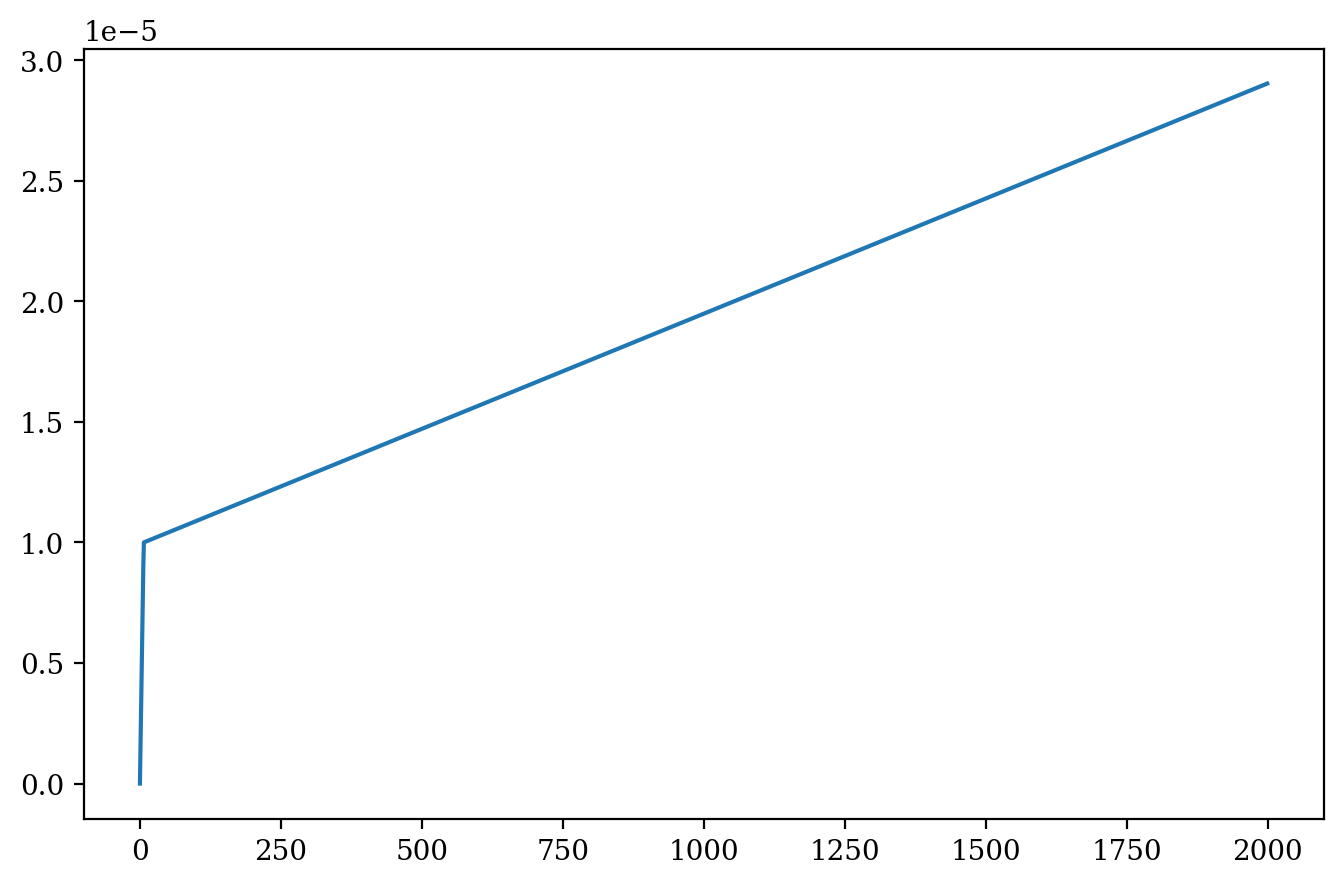

In [331]:
plt.plot(fucking_scaling_fuck(np.linspace(0,0.003,2000),1e-5,1e-6,1e4))

In [162]:
# # t=0.03
# # for t in [0.03, 0.06, 0.09, 0.012, 0.15]:
# for t in [0.5657, 0.5857, 0.6057, 0.6257, 0.6347]:
# # for t in [t=1.2052]
#     print(f"exporting figures for t={round(t,5)}")
#     data_folder = "20240711-234819-TFF" #"20240528-224811-TFF"
#     del psi, phi, swnf
#     with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl', 'rb', thread=8) as file:
#         psi = pickle.load(file)
#     phi, swnf = phiAndSWNF(psi, nthreads=7)
#     gc.collect()

#     psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True)

#     whatever_bla_testing1 = plot_g34(phi, cutPlot=1.5, saveFig=True, 
#             title2=f"Mirror Pulse",
#             title2filestr="MP", skipPlot=True
#             )

In [180]:
# t=1.2052
# data_folder = "20240711-234819-TFF" #"20240528-224811-TFF"
# for settingStr in comboSettSetS:
#     del psi, phi, swnf
#     with pgzip.open(f'/Volumes/tonyNVME Gold/twoParticleSim/{data_folder}/psi at t={round(t,5)}.pgz.pkl', 'rb', thread=8) as file:
#         psi = pickle.load(file)
#     phi, swnf = phiAndSWNF(psi, nthreads=7)
#     gc.collect()

#     psi_phi_plot1(t,-1,psi,phi, plt_show=False, plt_save=True)

#     whatever_bla_testing1 = plot_g34(phi, cutPlot=1.5, saveFig=True, 
#             title2=f"Initial scattering",
#             title2filestr="NA", skipPlot=True
#             )

0-3
4-5
6-5
5-6
3-0
3-4
4-3
5-4
6-1
3-6
1-6
1-0
6-3
0-1


In [129]:
pxmax/(hb*k)

4.0

In [695]:
psi, phi = None, None
gc.collect()

24670

In [76]:
np.show_config()

Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /opt/miniconda3/include
    lib directory: /opt/miniconda3/lib
    name: blas
    openblas configuration: unknown
    pc file directory: /opt/miniconda3/lib/pkgconfig
    version: 3.9.0
  lapack:
    detection method: pkgconfig
    found: true
    include directory: /opt/miniconda3/include
    lib directory: /opt/miniconda3/lib
    name: lapack
    openblas configuration: unknown
    pc file directory: /opt/miniconda3/lib/pkgconfig
    version: 3.9.0
Compilers:
  c:
    args: -ftree-vectorize, -fPIC, -fstack-protector-strong, -O2, -pipe, -isystem,
      /opt/miniconda3/include, -fdebug-prefix-map=/Users/runner/miniforge3/conda-bld/numpy_1724748652597/work=/usr/local/src/conda/numpy-2.0.2,
      -fdebug-prefix-map=/opt/miniconda3=/usr/local/src/conda-prefix, -D_FORTIFY_SOURCE=2,
      -isystem, /opt/miniconda3/include, -mmacosx-version-min=11.0, -mmacosx-version-min=11.0
    commands: arm6

In [82]:
np.test()

NumPy version 2.0.2
NumPy CPU features:  NEON NEON_FP16 NEON_VFPV4 ASIMD ASIMDHP* ASIMDFHM?
........................................................................ [  0%]
..............s....s.ss................................................. [  0%]
.................ss.....sss............................................. [  0%]
.................x...................................................... [  0%]
......................................................s................. [  0%]
........s............................................................... [  1%]
...ss............ss..................................................... [  1%]
..............................................s......ssss............... [  1%]
............................ssssssssssssssssssss........................ [  1%]
........................................................................ [  1%]
........................................................................ [  1%]
............................

np.float64(1.4142135623730951)

F..s............................................................. [ 44%]
........................................................................ [ 45%]
........................................................................ [ 45%]
........................................................................ [ 45%]
........................................................................ [ 45%]
........................................................................ [ 45%]
........................................................................ [ 45%]
........................................................................ [ 46%]
........................................................................ [ 46%]
........................................................................ [ 46%]
........................................................................ [ 46%]
........................................................................ [ 46%]
...............................................

False

# Benchmarking

In [185]:
psi,phi = None,None
gc.collect()

26

In [182]:
import timeit

In [85]:
psi = psi0gaussian(sx3=5, sz3=5, sx4=5, sz4=5, px3=0, pz3=0, px4=0, pz4=0)
phi, swnf = phiAndSWNF(psi, nthreads=7)

In [79]:
bench_scattering_evolve_bragg_loop_helper2 = datetime.now()
_ = scattering_evolve_bragg_loop_helper2(t,psi,swnf,steps=1,progress_proxy=None,s34=1e6,
                                        t3mid=-3,t3wid=1,v3pot=0,t4mid=0.5*t4sc,t4wid=t4sc,v4pot=V4sc)
l.info(f"scattering_evolve_bragg_loop_helper2 one run {(datetime.now()-bench_scattering_evolve_bragg_loop_helper2)}")

finding looplift candidates


/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_32477/2064340682.py:49: NumbaWarning: Cannot cache compiled function "scattering_evolve_bragg_loop_helper2" as it uses lifted code
  @jit(forceobj=True, cache=True)

/var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_32477/2064340682.py:49: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "scattering_evolve_bragg_loop_helper2" failed type inference due to: Invalid use of type(CPUDispatcher(<function toPhi at 0x17f74dc60>)) with parameters (array(complex128, 4d, C), complex128, nthreads=int64)

During: resolving callee type: type(CPUDispatcher(<function toPhi at 0x17f74dc60>))
During: typing of call at /var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_32477/2064340682.py (73)


File "../../../../../../../../var/folders/7h/f203l67s61gdw7tky19jks8h0000gn/T/ipykernel_32477/2064340682.py", line 73:
<source missing, REPL/exec in use?>

  @jit(forceobj=True, cache=

In [86]:
with ProgressBar(total=10) as progressbar: 
    bench_scattering_evolve_bragg_loop_helper2 = datetime.now()
    _ = scattering_evolve_bragg_loop_helper2(t,psi,swnf,steps=10,progress_proxy=progressbar,s34=evolve_s34,
                                            t3mid=-3,t3wid=1,v3pot=0,t4mid=0.5*t4sc,t4wid=t4sc,v4pot=V4sc)
    l.info(f"scattering_evolve_bragg_loop_helper2 one run {(datetime.now()-bench_scattering_evolve_bragg_loop_helper2)}")

  0%|          | 0/10 [00:00<?, ?it/s]

scattering_evolve_bragg_loop_helper2 one run 0:01:27.581470


In [87]:
with ProgressBar(total=10) as progressbar: 
    _ = scattering_evolve_bragg_loop_helper2(t,psi,swnf,
                                    steps=10,progress_proxy=progressbar,s34=0,
                                    t3mid=T_BS, t3wid=t3pi4, v3pot=V3pi4, 
                                    t4mid=T_BS, t4wid=t4pi4, v4pot=V4pi4,  
                                    numba_threads = 8,fftw_threads  = 8)

  0%|          | 0/10 [00:00<?, ?it/s]